# Battery Data Preparation — PSD Feature Extraction (FFT, 5-shift)

This notebook computes Power Spectral Density (PSD) features from the raw battery charging current (CC) and voltage (CV) waveforms for each battery. These frequency-domain features are the most predictive of battery lifetime in this dataset, as confirmed by SHAP analysis.

The key insight is that the shape of the charging protocol — encoded in the harmonic structure of the waveform — strongly predicts how long a battery will last. Batteries charged with simpler, single-step waveforms (fewer harmonics) tend to have longer lifetimes.

For each battery, this notebook:
1. Computes the FFT of the charging current and voltage waveforms
2. Identifies the fundamental frequency and its harmonics
3. Extracts the integrated peak area around each harmonic
4. Saves the results as DataFrames for use in the modeling notebooks

The "5-shift" in the filename refers to the number of frequency bins skipped at the low end (DC and near-DC components) when identifying the fundamental frequency.

Note: PSD output files are not saved in this repo.

**Pipeline overview:**
1. Load raw battery data file paths
2. Compute PSD and extract harmonic peak areas for each battery
3. Plot PSD for visual inspection (CC and CV)
4. Save PSD feature DataFrames to disk

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import keras
import numpy as np
import os
import seaborn as sns
import pickle
import gzip
from scipy.fft import fft, fftfreq

os.chdir('../')
from functions.model_wrapper import Tree_Model, rfm_params, xgboost_params

peakhalfwidth = 10

# These are batteries that show anomalies in the measnurements, and are therefore excluded.
excl_filenames = ['2018-04-12_batch8_CH46', '2017-06-30_3_6C-30per_6C_CH15', '2017-06-30_2C-7per_5_5C_CH12',
                  '2018-04-12_batch8_CH46', '2017-06-30_6C-60per_3C_CH48']

power = 16
nfft = np.power(2,power)
harmonics = 10

os.chdir('notebooks/')

In [2]:
from functions.dataprep import create_Peak_Areas_df, create_Peak_Heights_df

## 1. Load raw data file paths

Collects all battery data file paths from the raw data directory, excluding metadata files and any batteries already processed.

In [3]:
data_dir = '../data/raw_data/'
data_files = [file for file in os.listdir(data_dir) if 'Meta' not in file 
              and 'sdu' not in file 
              and 'jena' not in file
              and 'png' not in file
              and 'pckl' not in file
              and '.DS_Store' not in file
              and 'CH' in file]


## 2. Compute PSD and extract harmonic features

For each battery file, loads the raw charge/discharge data, computes the FFT of the current (CC) and voltage (CV) waveforms, and extracts the fundamental frequency and peak areas for each harmonic using `create_Peak_Areas_df()`. Results are collected into lists for later concatenation.

In [4]:
data_dir

'../data/raw_data/'

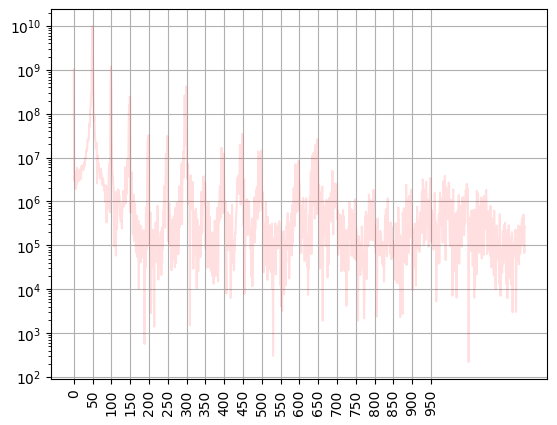

50
harmonic_areas: [np.float64(21466855065.6122), np.float64(1986780545.6812758), np.float64(788959453.580596), np.float64(105602566.69354616), np.float64(74555249.45899504), np.float64(1161858307.2526307), np.float64(20383210.918871284), np.float64(62528288.60036734), np.float64(127993746.22519927), np.float64(67978177.92428216)]
50
harmonic_areas: [np.float64(410266600.9846225), np.float64(135900647.42047113), np.float64(22684902.781173848), np.float64(8061824.73362352), np.float64(660443.4557507935), np.float64(4966731.526461802), np.float64(474305.2397583798), np.float64(631114.4986902134), np.float64(488249.90709023684), np.float64(474595.44455608766)]



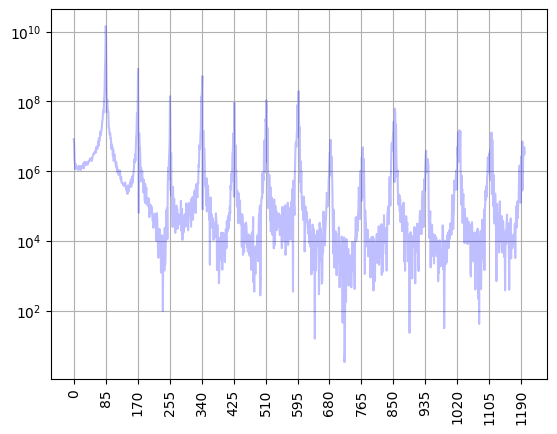

85
harmonic_areas: [np.float64(25164616865.004227), np.float64(1057476237.1271833), np.float64(171927140.50967842), np.float64(1074681254.6813357), np.float64(128629912.4219394), np.float64(281430757.33008814), np.float64(410835579.51168376), np.float64(24722460.378523886), np.float64(18676054.609265078), np.float64(211604867.9527642)]
85
harmonic_areas: [np.float64(432727887.24154824), np.float64(82092735.97138117), np.float64(42608801.71685928), np.float64(5840628.353179927), np.float64(805085.7271172296), np.float64(1247845.4390568237), np.float64(266040.2357493146), np.float64(492259.3118369067), np.float64(220330.07732172645), np.float64(499393.268455151)]



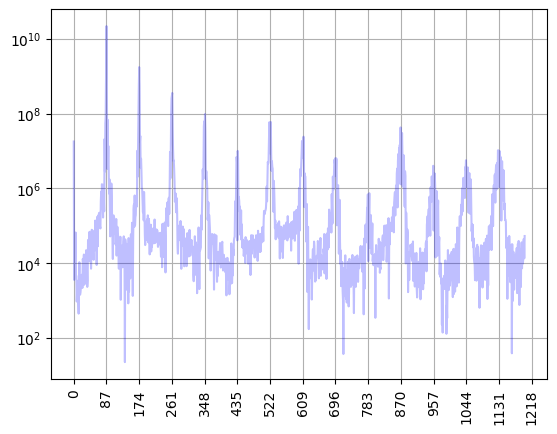

87
harmonic_areas: [np.float64(24752278685.714836), np.float64(2968219120.7735057), np.float64(1099281009.6792493), np.float64(280895047.2573361), np.float64(33917769.29009952), np.float64(257526087.1787972), np.float64(105883703.36041273), np.float64(47533727.15938782), np.float64(3717519.737791), np.float64(188080299.73285207)]
87
harmonic_areas: [np.float64(381336070.876509), np.float64(78627158.18666117), np.float64(54299063.284484), np.float64(6732451.54273088), np.float64(779382.4089037423), np.float64(1274918.361555643), np.float64(10311.037291367802), np.float64(501897.0892494046), np.float64(469435.17335584457), np.float64(383522.40815436817)]



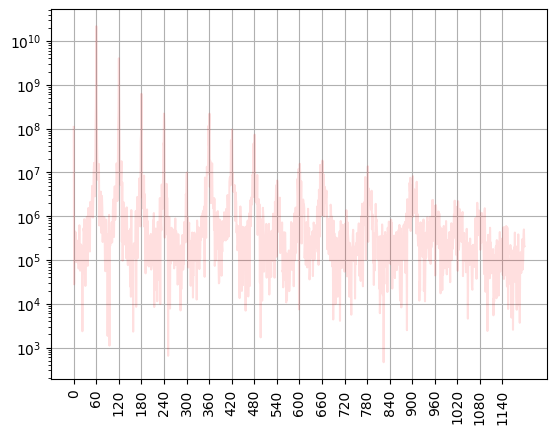

60
harmonic_areas: [np.float64(22689746843.862064), np.float64(4820720889.024015), np.float64(937429272.1184306), np.float64(470124447.22076315), np.float64(30707478.523246616), np.float64(613792583.6035373), np.float64(260930564.70272607), np.float64(208687893.00942826), np.float64(33128156.24820832), np.float64(74978911.19301262)]
60
harmonic_areas: [np.float64(390279003.9985784), np.float64(91452204.90385976), np.float64(59874967.40353368), np.float64(13580202.295356506), np.float64(700770.933947451), np.float64(1707140.9418776785), np.float64(214116.5338028111), np.float64(1066656.9803734946), np.float64(224118.0331885192), np.float64(161669.49888545455)]



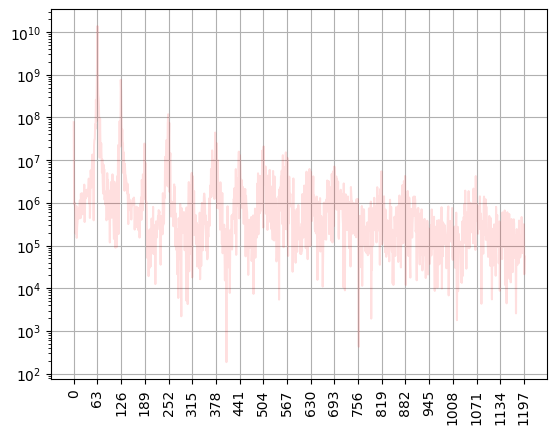

63
harmonic_areas: [np.float64(19352094494.68244), np.float64(1643906780.014914), np.float64(73721482.85161391), np.float64(402778263.8086261), np.float64(29363033.835562475), np.float64(177045225.3595041), np.float64(81866190.1015152), np.float64(99383456.62821756), np.float64(73400337.04552248), np.float64(44900372.77404651)]
63
harmonic_areas: [np.float64(412535974.6103687), np.float64(82941175.64995985), np.float64(46217698.81448226), np.float64(10813170.861875245), np.float64(553645.287542618), np.float64(1279162.8860231189), np.float64(184872.07305529155), np.float64(568345.8662602635), np.float64(323690.3933056004), np.float64(88325.18854913207)]



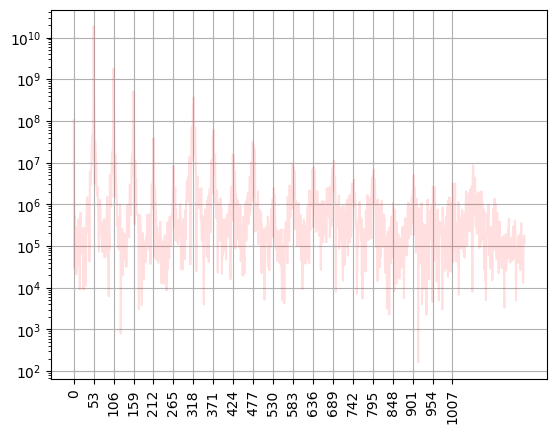

53
harmonic_areas: [np.float64(19511761224.295826), np.float64(2197857826.430392), np.float64(799420174.3749183), np.float64(93430877.05229121), np.float64(28896447.95711086), np.float64(1146195699.0378346), np.float64(205238507.10443577), np.float64(67921142.05486743), np.float64(158041195.43763596), np.float64(10718701.548221987)]
53
harmonic_areas: [np.float64(419910802.51885253), np.float64(117601067.10285696), np.float64(31501646.050580185), np.float64(4955323.767362829), np.float64(1882642.7709007245), np.float64(2348566.57335731), np.float64(988732.7888996298), np.float64(1607911.872702948), np.float64(199444.9717344587), np.float64(195311.22016100065)]



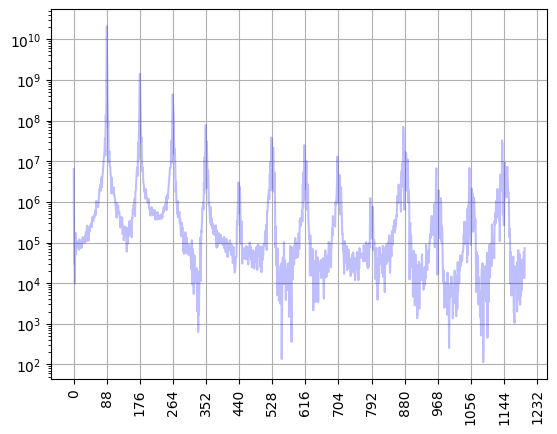

88
harmonic_areas: [np.float64(25394698570.46769), np.float64(3161971286.23428), np.float64(1312743130.6617744), np.float64(260449744.94089866), np.float64(15255175.495530812), np.float64(194398101.63783216), np.float64(89487051.21265262), np.float64(46946704.00412823), np.float64(6552974.182261833), np.float64(245596221.41426066)]
88
harmonic_areas: [np.float64(370531308.6367472), np.float64(76655069.57544287), np.float64(55141637.30011728), np.float64(6829395.64877398), np.float64(928685.6651845052), np.float64(1061016.011297867), np.float64(18946.79016938935), np.float64(637872.5806894986), np.float64(446202.3700026031), np.float64(443175.1948656578)]



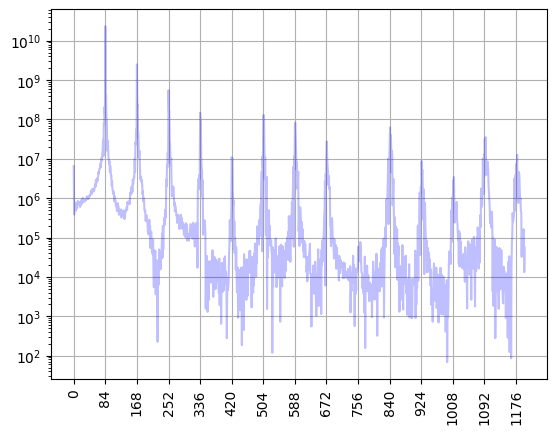

84
harmonic_areas: [np.float64(25142667087.574394), np.float64(3272150189.5422277), np.float64(1010128502.6716663), np.float64(382239286.1486258), np.float64(34924218.31021831), np.float64(397845989.32351756), np.float64(271332295.9780958), np.float64(86938977.02282034), np.float64(698352.9138586571), np.float64(236779774.44501376)]
84
harmonic_areas: [np.float64(400840052.49687487), np.float64(81749719.35475142), np.float64(53901823.00613705), np.float64(7450319.045748073), np.float64(791147.398295077), np.float64(1745365.9525868595), np.float64(86535.75948738144), np.float64(612522.1900358261), np.float64(296504.77852690854), np.float64(507468.01832566474)]



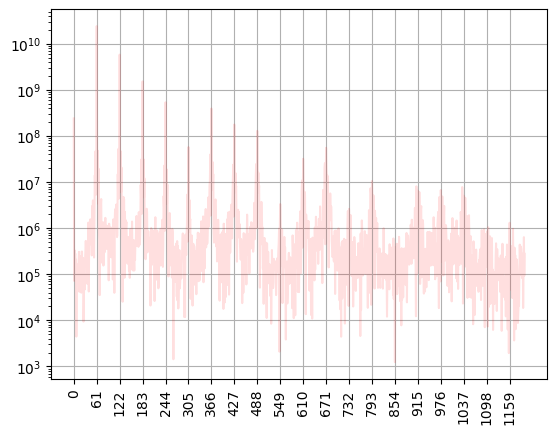

61
harmonic_areas: [np.float64(24485567989.594036), np.float64(6097689609.185609), np.float64(1702794708.0802073), np.float64(650326001.6921415), np.float64(82595553.72105879), np.float64(597129050.4827753), np.float64(305437432.52763283), np.float64(258188382.89844373), np.float64(11782539.242194502), np.float64(96543357.81029426)]
61
harmonic_areas: [np.float64(374825224.5536474), np.float64(90194634.81284992), np.float64(65491537.193909675), np.float64(15037691.64590539), np.float64(909584.2624381047), np.float64(1561033.9884916318), np.float64(174549.49465154577), np.float64(1134961.65217037), np.float64(178405.33981198544), np.float64(169528.2909657406)]



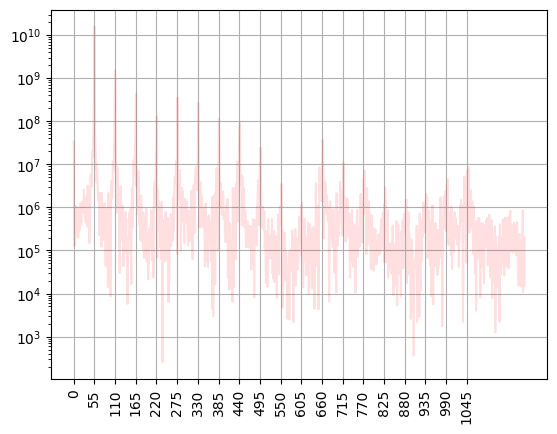

55
harmonic_areas: [np.float64(17901181992.918114), np.float64(2460236831.0441527), np.float64(953589415.1830972), np.float64(191046129.17838863), np.float64(444438509.3514178), np.float64(382945759.97668153), np.float64(215470923.397139), np.float64(303981158.25235176), np.float64(62941307.416434936), np.float64(9525714.897519179)]
55
harmonic_areas: [np.float64(434379234.98040676), np.float64(95445415.26649415), np.float64(39512922.22299964), np.float64(2215422.5114333434), np.float64(3410531.917473862), np.float64(771320.0761301725), np.float64(701842.3610502564), np.float64(1506973.9087333002), np.float64(603168.679249686), np.float64(190083.6198831216)]



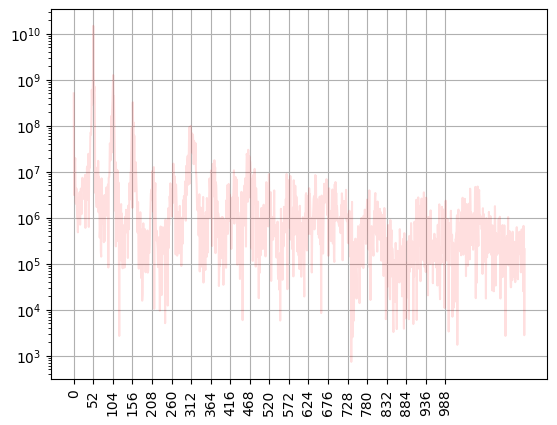

52
harmonic_areas: [np.float64(21128813441.53365), np.float64(3849868769.8582907), np.float64(868067553.8501765), np.float64(61842594.3595794), np.float64(68434870.1781747), np.float64(803409648.526835), np.float64(74951684.26240769), np.float64(42053746.62854505), np.float64(176321279.79079908), np.float64(40225868.29134319)]
52
harmonic_areas: [np.float64(388277881.0610915), np.float64(114780789.16307646), np.float64(33771677.78922343), np.float64(7101544.289255107), np.float64(1110872.864696275), np.float64(1869200.3216190662), np.float64(677088.2498236969), np.float64(732686.8191356421), np.float64(340883.4904006744), np.float64(191772.61353262494)]



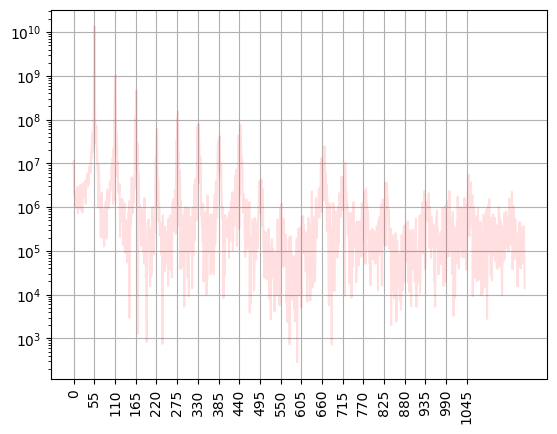

55
harmonic_areas: [np.float64(17777958653.53784), np.float64(2749089714.9664855), np.float64(953192849.9334062), np.float64(183122993.98436373), np.float64(432266365.11787933), np.float64(386799387.9447307), np.float64(179026050.50584298), np.float64(314846273.7934918), np.float64(29444440.754257087), np.float64(6643044.854234754)]
55
harmonic_areas: [np.float64(411346415.4481794), np.float64(97801229.43446243), np.float64(40759964.71445687), np.float64(3207755.7151782825), np.float64(3303696.446052758), np.float64(784482.4220177411), np.float64(564528.9044520212), np.float64(1647824.541206019), np.float64(432890.9487946185), np.float64(285318.39688874193)]



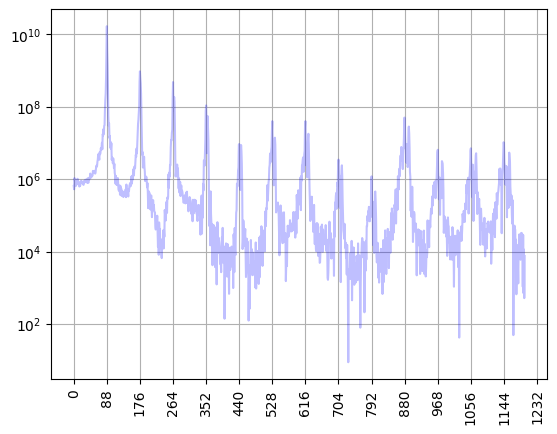

88
harmonic_areas: [np.float64(26250620647.682224), np.float64(3121578269.8711767), np.float64(1302803864.645755), np.float64(386453871.50355726), np.float64(56632458.687343396), np.float64(162721644.1292473), np.float64(176409879.81438395), np.float64(20617084.71522873), np.float64(5692890.885595239), np.float64(311446733.90152955)]
88
harmonic_areas: [np.float64(366084445.130565), np.float64(75127835.34762721), np.float64(54759496.72403546), np.float64(7425002.545735007), np.float64(1288017.4879531646), np.float64(908393.2918908218), np.float64(44353.920786975694), np.float64(553459.7364058887), np.float64(600443.2665656627), np.float64(549110.8846097926)]



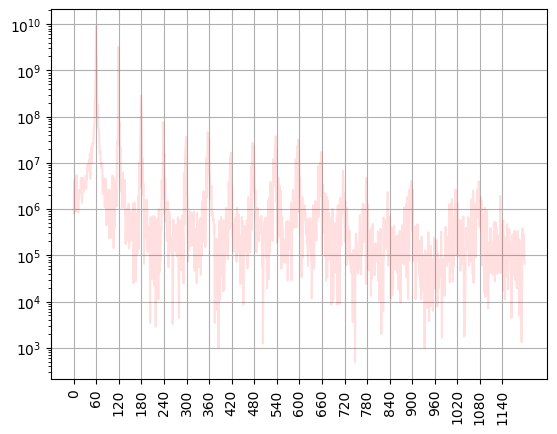

60
harmonic_areas: [np.float64(20208293666.06832), np.float64(3796223972.866707), np.float64(663935496.7638166), np.float64(167846117.20914453), np.float64(121891200.57275894), np.float64(198556922.60541594), np.float64(62898304.54342036), np.float64(105418018.9289138), np.float64(158119573.73499793), np.float64(146897587.5837688)]
60
harmonic_areas: [np.float64(399105143.9013639), np.float64(87222861.26382288), np.float64(59775914.85347228), np.float64(11095542.897847716), np.float64(223664.67321268847), np.float64(1449404.5332098892), np.float64(352772.8416462779), np.float64(877914.069619494), np.float64(407637.6252711454), np.float64(224613.12864723674)]



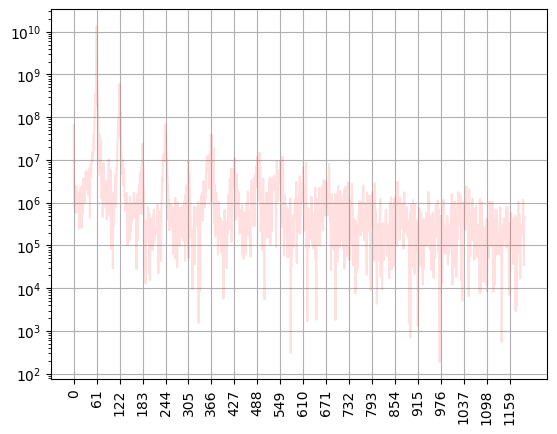

61
harmonic_areas: [np.float64(18750384534.851482), np.float64(1660536605.1768084), np.float64(91203363.89973165), np.float64(297498691.66940916), np.float64(34682266.178101614), np.float64(240802709.94200897), np.float64(73090611.53137371), np.float64(93628585.07822567), np.float64(90649982.4272435), np.float64(42586628.25739631)]
61
harmonic_areas: [np.float64(421091708.55457693), np.float64(87324034.39290544), np.float64(46861591.560856275), np.float64(9787600.670109779), np.float64(210566.16001086903), np.float64(1352900.0064470412), np.float64(156566.6831468126), np.float64(648150.3486421518), np.float64(388166.42368677666), np.float64(124547.98560929517)]



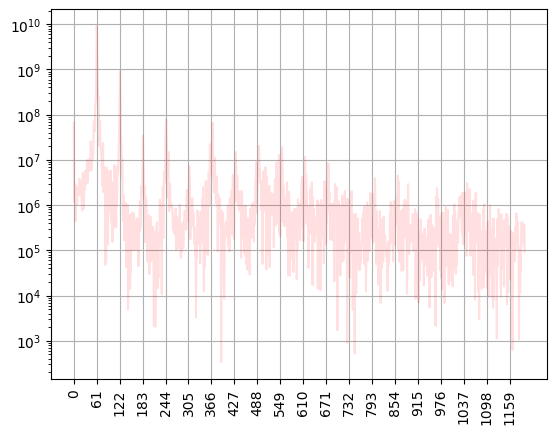

61
harmonic_areas: [np.float64(18823297587.015915), np.float64(1551343580.8115938), np.float64(83115147.8930019), np.float64(279325151.36856234), np.float64(31653242.275354423), np.float64(236677042.79203916), np.float64(78384043.50355957), np.float64(103455077.84385997), np.float64(93309804.98117824), np.float64(45669136.41440262)]
61
harmonic_areas: [np.float64(429873485.9006861), np.float64(87255094.99488348), np.float64(46164181.868346274), np.float64(8519700.418651469), np.float64(175348.08580074614), np.float64(1595484.3832213078), np.float64(250574.24569681837), np.float64(717076.6673505862), np.float64(345104.1826192051), np.float64(189406.93977360945)]



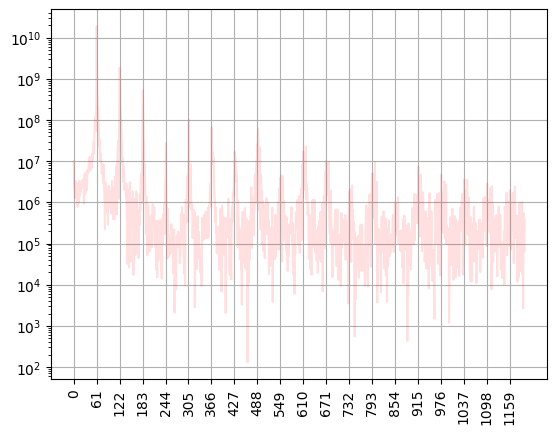

61
harmonic_areas: [np.float64(22268765838.748096), np.float64(3630260983.2509985), np.float64(924454603.1364285), np.float64(42368092.153912276), np.float64(144622341.70945555), np.float64(163271816.70562828), np.float64(78997413.76246014), np.float64(229071487.87763518), np.float64(26745812.912595496), np.float64(117960269.85228315)]
61
harmonic_areas: [np.float64(397286983.9277687), np.float64(88518071.40047033), np.float64(63847426.162750795), np.float64(8475746.117730966), np.float64(143773.80981560363), np.float64(748784.776570503), np.float64(200814.5095831204), np.float64(1147945.663627598), np.float64(115473.05483930926), np.float64(217827.80430039664)]



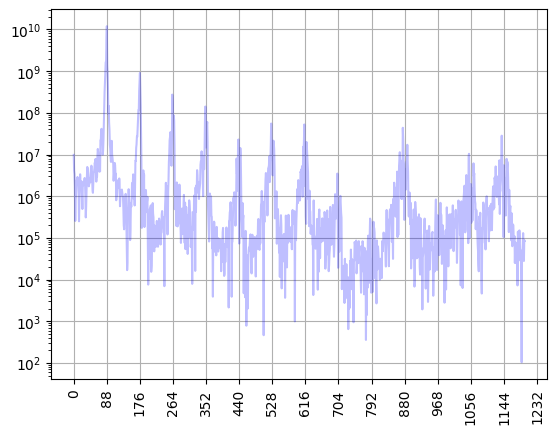

88
harmonic_areas: [np.float64(26316593305.00241), np.float64(2830060931.221155), np.float64(969901873.9042785), np.float64(553398141.2843748), np.float64(125231759.59488793), np.float64(244491243.16834632), np.float64(207981326.88184306), np.float64(14312050.8780753), np.float64(2171059.0704309037), np.float64(190678922.32760358)]
88
harmonic_areas: [np.float64(358773781.30159867), np.float64(75145038.8705467), np.float64(52635623.160754904), np.float64(8133590.05810539), np.float64(1544873.107583798), np.float64(1043865.1136747868), np.float64(30211.660847859668), np.float64(462683.32423991495), np.float64(464409.87691867165), np.float64(365223.0633234651)]



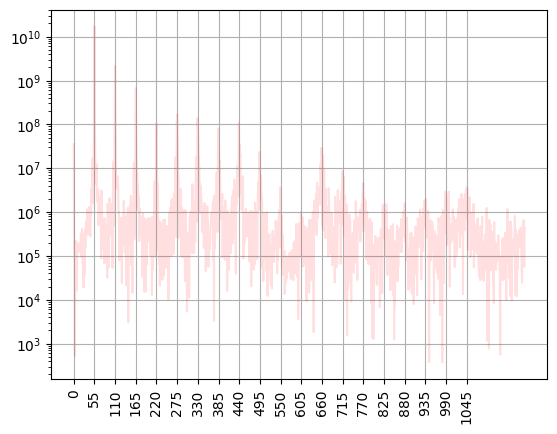

55
harmonic_areas: [np.float64(17797292437.74714), np.float64(2479081827.265732), np.float64(959373105.4662437), np.float64(194731575.8083563), np.float64(435925847.63677406), np.float64(392173110.3086865), np.float64(211842422.21287927), np.float64(280571869.32204723), np.float64(64056150.72071031), np.float64(10750791.785273625)]
55
harmonic_areas: [np.float64(442510677.9111134), np.float64(96029331.03874475), np.float64(39159780.26421112), np.float64(1889998.0709163104), np.float64(3544680.540958095), np.float64(760956.4939338694), np.float64(617180.814809603), np.float64(1417014.537572408), np.float64(548017.6668232409), np.float64(168236.78029926636)]



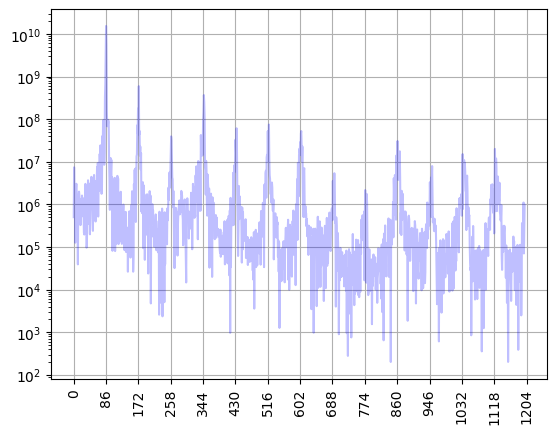

86
harmonic_areas: [np.float64(25893704535.52819), np.float64(1195220013.4687228), np.float64(145396326.33326837), np.float64(1210046358.105394), np.float64(194130992.37659463), np.float64(245469876.26655927), np.float64(297771373.80457455), np.float64(25501881.457906682), np.float64(10225685.842290118), np.float64(141228963.9309678)]
86
harmonic_areas: [np.float64(390441969.14036894), np.float64(78971240.52454107), np.float64(40584811.361318015), np.float64(8606086.594249278), np.float64(1329129.893544836), np.float64(1010245.9563617031), np.float64(136675.98725820746), np.float64(292131.26651251246), np.float64(520580.060022461), np.float64(164558.2912951846)]



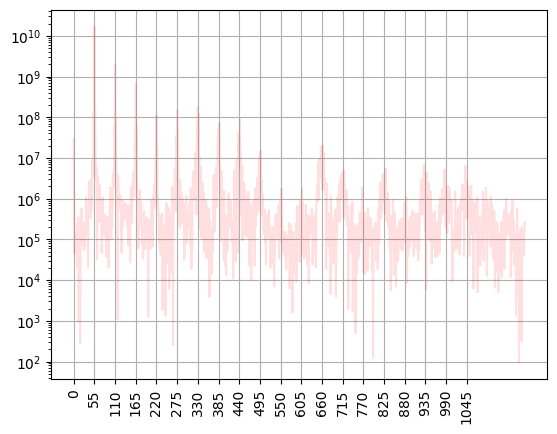

55
harmonic_areas: [np.float64(17562979707.190113), np.float64(2259273686.832167), np.float64(863400253.6927534), np.float64(170182910.14916456), np.float64(295436327.72035694), np.float64(542529030.8789997), np.float64(259663288.93924695), np.float64(300668661.5031742), np.float64(67270552.38861911), np.float64(8223027.292557687)]
55
harmonic_areas: [np.float64(431326368.57120085), np.float64(98754473.50511228), np.float64(37352462.150980905), np.float64(2648163.543251013), np.float64(3307201.4833066124), np.float64(845942.6477860588), np.float64(641662.3647290047), np.float64(1702813.5510267953), np.float64(461469.5836466169), np.float64(198414.54136350247)]



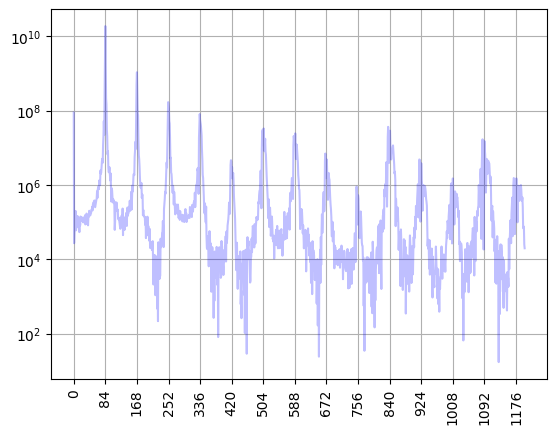

84
harmonic_areas: [np.float64(22664394523.34438), np.float64(2273992594.9769697), np.float64(631906712.7476387), np.float64(365082623.5093606), np.float64(27262923.582882423), np.float64(221107862.16261804), np.float64(164079549.96231398), np.float64(38975468.21962924), np.float64(4680846.474461294), np.float64(245101497.98925376)]
84
harmonic_areas: [np.float64(398380177.9622248), np.float64(78809807.23455104), np.float64(52425410.80599202), np.float64(6848174.045906047), np.float64(564194.0420019183), np.float64(1203172.2496051525), np.float64(59067.61402210944), np.float64(509194.18826800276), np.float64(390645.93996211636), np.float64(458666.6181952142)]



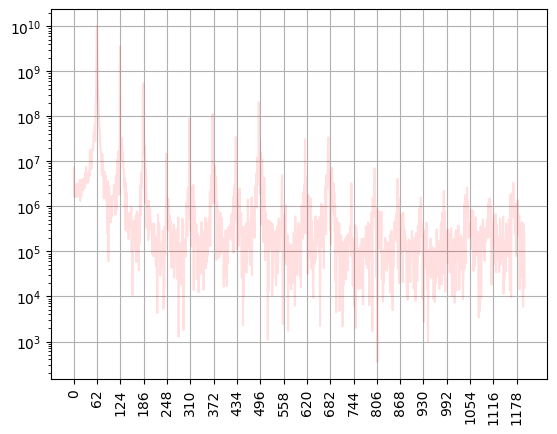

62
harmonic_areas: [np.float64(22138266868.653152), np.float64(3791901119.779095), np.float64(1047079424.5030956), np.float64(24305395.7927398), np.float64(190671818.57114708), np.float64(177813015.6823861), np.float64(80012997.98514129), np.float64(358677469.1847163), np.float64(14079929.889413996), np.float64(57229573.54220717)]
62
harmonic_areas: [np.float64(393758447.9935987), np.float64(87731356.6486672), np.float64(64657524.25642706), np.float64(8573169.124122659), np.float64(92304.24131195665), np.float64(739794.0594090811), np.float64(84783.55244946953), np.float64(1509837.5104948592), np.float64(41848.60969439949), np.float64(114633.41155887558)]



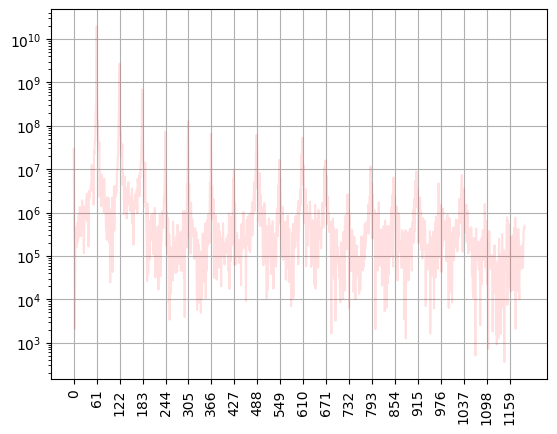

61
harmonic_areas: [np.float64(22569552360.69095), np.float64(4579264441.166418), np.float64(1348560100.0624557), np.float64(103475035.31855136), np.float64(167382640.5918097), np.float64(102259503.3018471), np.float64(28908440.431481183), np.float64(254656735.06499627), np.float64(53447381.297797665), np.float64(170211562.01108834)]
61
harmonic_areas: [np.float64(376968402.7854962), np.float64(89502413.91410719), np.float64(65352475.58908817), np.float64(11014772.759016525), np.float64(260832.3877955365), np.float64(517711.37058950594), np.float64(63125.50426954679), np.float64(1109002.8923590533), np.float64(182509.0834513711), np.float64(294839.6268049062)]



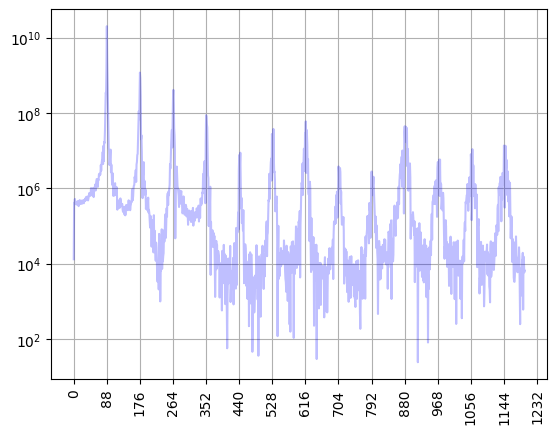

88
harmonic_areas: [np.float64(26100943910.662743), np.float64(3014211485.4672327), np.float64(1161808468.5063558), np.float64(318616970.06592494), np.float64(31310552.504353877), np.float64(154912736.4174074), np.float64(244546431.42992586), np.float64(21448698.938421432), np.float64(15046045.620667804), np.float64(337340407.14443976)]
88
harmonic_areas: [np.float64(397742629.03381467), np.float64(78071492.22051953), np.float64(53282562.96075559), np.float64(6338303.661162227), np.float64(1029448.0424068307), np.float64(1117407.3049285691), np.float64(79669.55068003932), np.float64(655632.4143857285), np.float64(342631.1729277346), np.float64(687981.1224300745)]



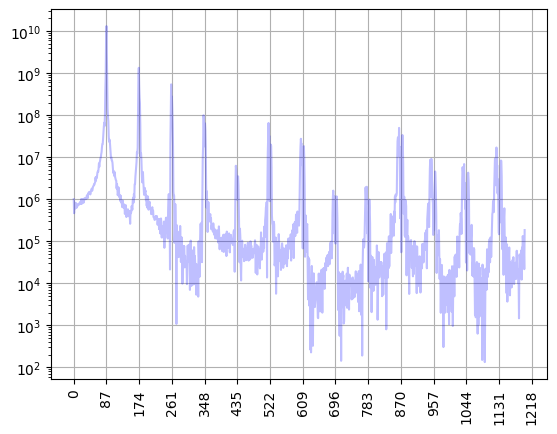

87
harmonic_areas: [np.float64(25267650807.519695), np.float64(3383805432.7714934), np.float64(1273735522.046259), np.float64(393342044.41181004), np.float64(30398314.287867285), np.float64(223379698.9443032), np.float64(167863451.19774333), np.float64(11035650.822868977), np.float64(10516035.507632049), np.float64(291467292.4585581)]
87
harmonic_areas: [np.float64(362727743.76404124), np.float64(75861930.1251227), np.float64(54517856.34698847), np.float64(8183160.686267419), np.float64(1038819.7647028839), np.float64(1074453.0857923122), np.float64(51454.07241506065), np.float64(379761.8886181932), np.float64(764580.0631121203), np.float64(431910.69310132513)]



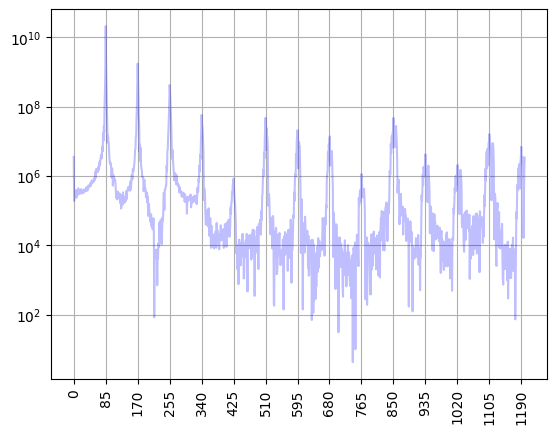

85
harmonic_areas: [np.float64(24704521600.863968), np.float64(3200225291.5727386), np.float64(1234656282.9463758), np.float64(188946898.54679906), np.float64(4932714.079352788), np.float64(181741343.34423482), np.float64(109081546.17407537), np.float64(75868694.46019831), np.float64(6545984.365993943), np.float64(275163456.95733136)]
85
harmonic_areas: [np.float64(396924787.66213846), np.float64(81457890.16348201), np.float64(55473299.941311084), np.float64(6372697.951814191), np.float64(538694.8291573521), np.float64(1085280.4960492023), np.float64(25673.425744129294), np.float64(688425.9865117716), np.float64(308646.33644644485), np.float64(560387.8822222474)]



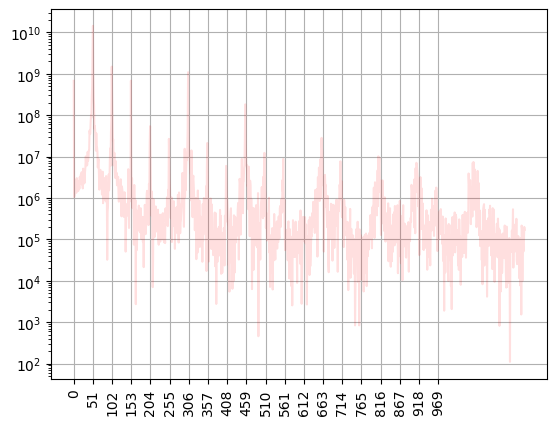

51
harmonic_areas: [np.float64(21101743166.611732), np.float64(2217603557.9265213), np.float64(717830215.8600645), np.float64(95462956.32258078), np.float64(47237501.081959225), np.float64(1318790131.6621284), np.float64(39222708.51060555), np.float64(14847554.441820605), np.float64(292979371.71064913), np.float64(35526786.36679563)]
51
harmonic_areas: [np.float64(393395630.4999231), np.float64(130049216.26817833), np.float64(26575839.546605185), np.float64(8256081.522621713), np.float64(925548.4840231312), np.float64(3546006.252050445), np.float64(1105832.7645516947), np.float64(763978.437500401), np.float64(530977.6021477462), np.float64(407711.6044247417)]



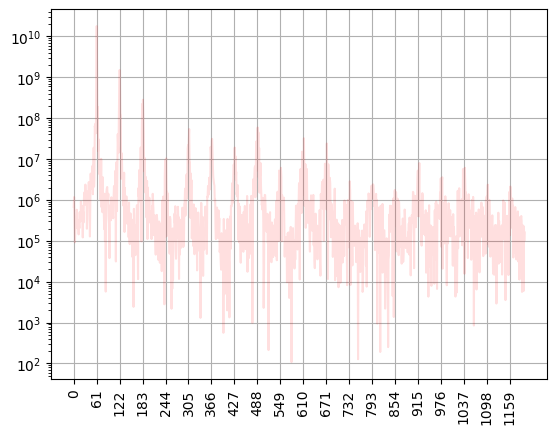

61
harmonic_areas: [np.float64(22019557229.83546), np.float64(3705327062.375266), np.float64(878204226.2301568), np.float64(43091664.36895347), np.float64(175560083.8576671), np.float64(155002851.21437234), np.float64(80423863.78964943), np.float64(252439192.99839526), np.float64(32308676.332237702), np.float64(104155983.29978071)]
61
harmonic_areas: [np.float64(408440551.3928891), np.float64(87554391.59019977), np.float64(62843205.685840875), np.float64(8671095.612856554), np.float64(89850.00782534186), np.float64(834138.6782247338), np.float64(202369.97127694718), np.float64(1281499.0779056342), np.float64(81035.28574742308), np.float64(165708.94955313473)]



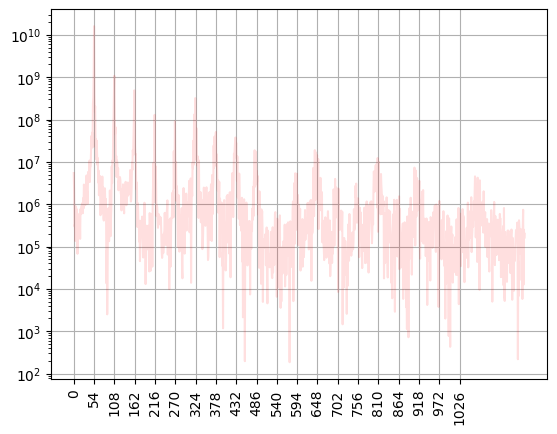

54
harmonic_areas: [np.float64(18625972457.00277), np.float64(2055373640.0345943), np.float64(894855665.4173537), np.float64(196673086.03782165), np.float64(157615552.93009126), np.float64(838006284.162361), np.float64(276515156.08858615), np.float64(208732291.77983323), np.float64(92620956.3709137), np.float64(4591129.969059885)]
54
harmonic_areas: [np.float64(411093920.5329528), np.float64(106737236.07585265), np.float64(35065907.9337462), np.float64(3818063.5555653274), np.float64(2232509.2292592647), np.float64(1252663.8505860788), np.float64(949048.8148834007), np.float64(2178974.14806122), np.float64(198291.35466252576), np.float64(174689.6984046499)]



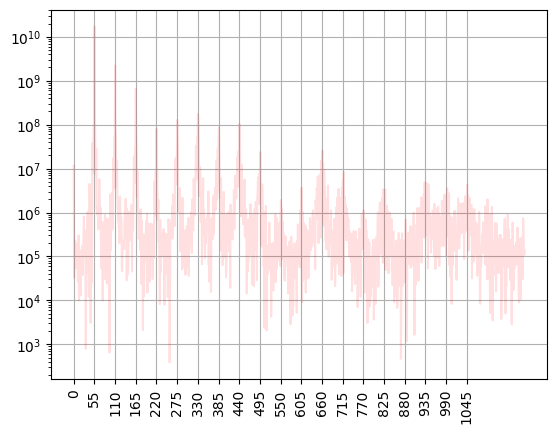

55
harmonic_areas: [np.float64(17820014811.62833), np.float64(2528343350.845164), np.float64(870440516.4512695), np.float64(139438669.11170167), np.float64(293349667.4703211), np.float64(568040606.674625), np.float64(257539090.2278704), np.float64(280235160.16520166), np.float64(73016974.16357283), np.float64(9323819.518926285)]
55
harmonic_areas: [np.float64(436139764.6883712), np.float64(100248501.41598976), np.float64(38319528.836334206), np.float64(2457333.160447891), np.float64(3052746.248826511), np.float64(1089363.9434429386), np.float64(661009.1797724054), np.float64(1625767.4132789448), np.float64(473127.62259010953), np.float64(173340.7300879646)]



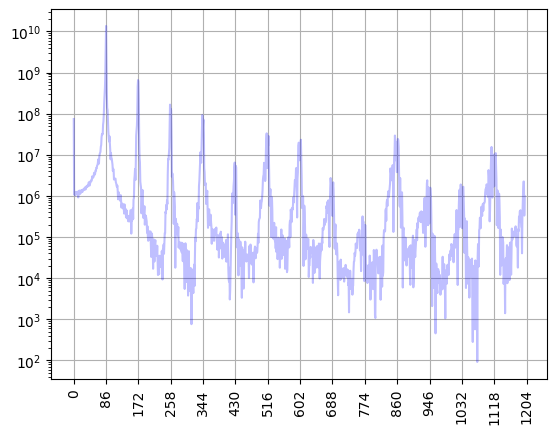

86
harmonic_areas: [np.float64(22813253198.45728), np.float64(2225630122.3911777), np.float64(655860060.7022363), np.float64(420347136.74589884), np.float64(36964369.897154), np.float64(204765607.60230643), np.float64(165028791.8758895), np.float64(21975360.267282743), np.float64(2465006.4357877104), np.float64(233133239.48310798)]
86
harmonic_areas: [np.float64(381570584.51677614), np.float64(76433334.48949099), np.float64(51606352.53695033), np.float64(7244037.644833278), np.float64(803384.4384532748), np.float64(1104643.501015938), np.float64(46683.63638583303), np.float64(417946.26558822306), np.float64(529296.5037374407), np.float64(392742.5597931861)]



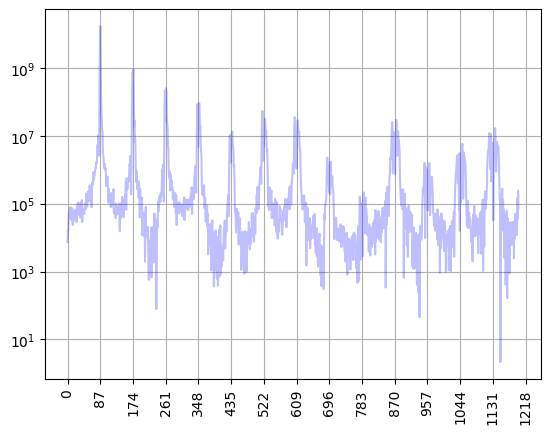

87
harmonic_areas: [np.float64(25955035395.687107), np.float64(2932884251.4059567), np.float64(1023083484.5803462), np.float64(479774801.04420435), np.float64(83004173.5116916), np.float64(278725441.88740736), np.float64(248555163.33529025), np.float64(15828546.880652348), np.float64(1678543.5158604484), np.float64(227016955.8230874)]
87
harmonic_areas: [np.float64(374864034.04941773), np.float64(76957660.82973525), np.float64(52700795.120811775), np.float64(7523047.778190596), np.float64(1247566.9151316804), np.float64(1118166.3604551763), np.float64(23820.08541370873), np.float64(418488.2621591346), np.float64(524744.5787610717), np.float64(435026.9528964113)]



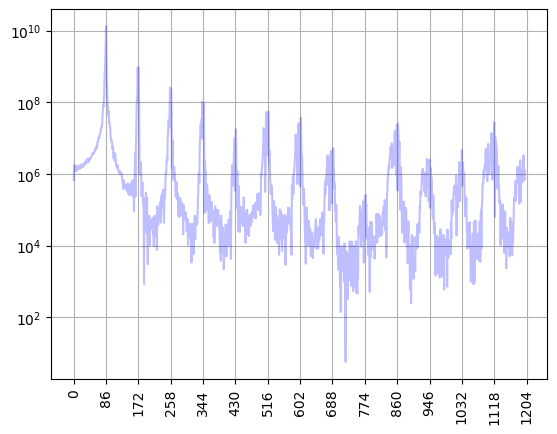

86
harmonic_areas: [np.float64(24868653675.085842), np.float64(3149045077.155182), np.float64(1009631424.0927298), np.float64(424653919.2150926), np.float64(55405971.86491238), np.float64(342470657.122464), np.float64(222654680.7585907), np.float64(39667311.0848119), np.float64(1832236.4053563224), np.float64(205195260.88606867)]
86
harmonic_areas: [np.float64(372374243.512444), np.float64(77789490.8418814), np.float64(54474506.700853445), np.float64(8061969.68466166), np.float64(1155474.9619418152), np.float64(1398438.0728113577), np.float64(37551.72127060604), np.float64(438780.1943268905), np.float64(495229.76278512453), np.float64(415705.4462027873)]



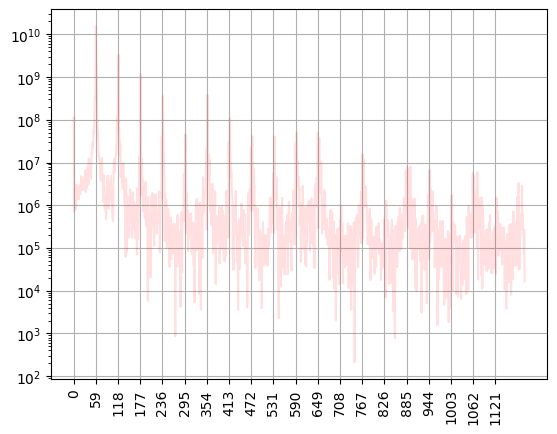

59
harmonic_areas: [np.float64(22087908963.330948), np.float64(5130379741.600012), np.float64(1223247444.3259454), np.float64(546614159.3923641), np.float64(80833790.16967401), np.float64(493792145.2222268), np.float64(206087912.6075908), np.float64(123205602.34168294), np.float64(78490509.40094393), np.float64(127998655.87011313)]
59
harmonic_areas: [np.float64(373110947.1006184), np.float64(89966497.26634862), np.float64(62627270.5461369), np.float64(14770747.077118028), np.float64(748988.5801502533), np.float64(1439702.7583109436), np.float64(258533.2348149125), np.float64(935552.4445423308), np.float64(335203.4616011691), np.float64(199653.61084835057)]



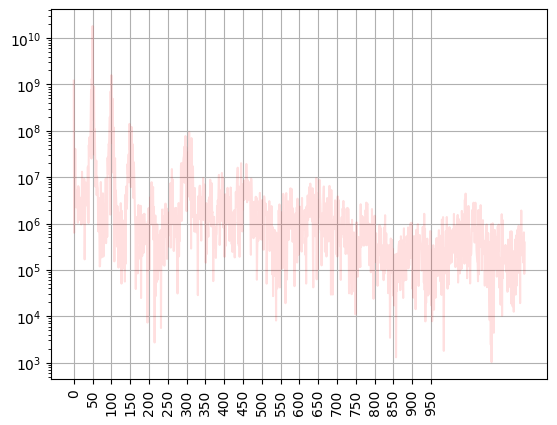

50
harmonic_areas: [np.float64(22903017906.08185), np.float64(4014444287.1054273), np.float64(736293637.4951718), np.float64(33711396.11356551), np.float64(29364518.048652805), np.float64(588659238.8111374), np.float64(44791107.38651074), np.float64(67806264.52034569), np.float64(127944524.5244085), np.float64(34357960.170009345)]
50
harmonic_areas: [np.float64(379121155.1326578), np.float64(122725400.61583337), np.float64(28513722.26362407), np.float64(8283438.579007765), np.float64(853054.6647757703), np.float64(1915382.5622808184), np.float64(327408.81982732273), np.float64(346403.5478328721), np.float64(464126.9903228588), np.float64(190859.93858444065)]



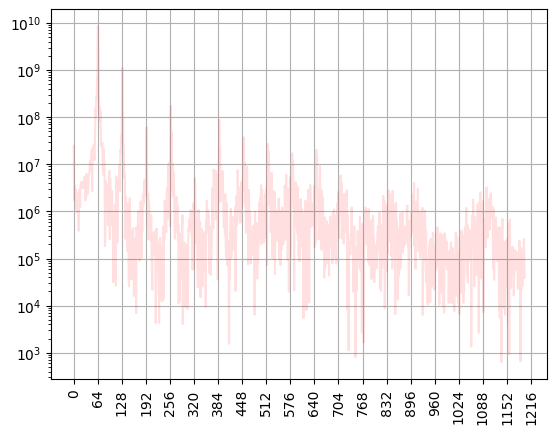

64
harmonic_areas: [np.float64(20976563264.914364), np.float64(1649057654.7174652), np.float64(146020944.55289608), np.float64(351344279.10817844), np.float64(22309535.269292638), np.float64(202507173.99039653), np.float64(136974151.24672934), np.float64(89858340.54348163), np.float64(69911779.38357641), np.float64(76581142.4519824)]
64
harmonic_areas: [np.float64(443228290.30955637), np.float64(84888361.51504306), np.float64(46485357.65469432), np.float64(7457134.250356077), np.float64(251091.84890174), np.float64(1653969.4027388555), np.float64(470561.78520805517), np.float64(541789.4083956325), np.float64(266905.6072584141), np.float64(239334.14689513168)]



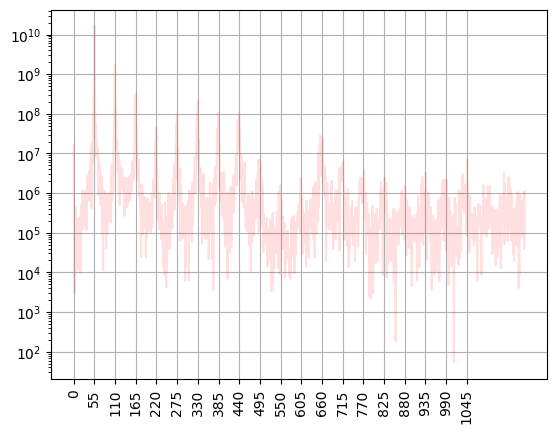

55
harmonic_areas: [np.float64(18007519612.91934), np.float64(2581640194.4426155), np.float64(890311024.9166558), np.float64(141235785.60235515), np.float64(320018050.1595399), np.float64(542352604.888033), np.float64(284473720.58185714), np.float64(347444051.3891277), np.float64(44778715.639231496), np.float64(6917317.887739113)]
55
harmonic_areas: [np.float64(421575275.2522224), np.float64(95464366.51452564), np.float64(38854246.3302339), np.float64(2837712.941043261), np.float64(3053480.7903561867), np.float64(827695.8574342212), np.float64(691950.5583519101), np.float64(1774304.506666099), np.float64(493768.85793071974), np.float64(222298.98577902833)]



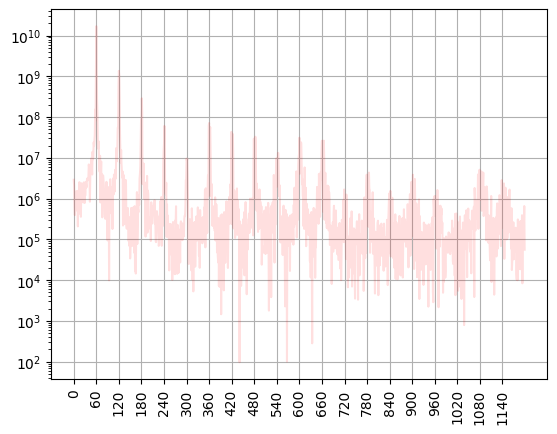

60
harmonic_areas: [np.float64(21175280321.224136), np.float64(3551554013.2240868), np.float64(645680006.0173001), np.float64(174145489.51813808), np.float64(41259530.974962205), np.float64(282631070.0908325), np.float64(131173643.47450927), np.float64(109016569.88200223), np.float64(77071226.88551183), np.float64(158983344.40381286)]
60
harmonic_areas: [np.float64(385687217.3802556), np.float64(88351904.2074846), np.float64(59999871.60160789), np.float64(12081164.645354377), np.float64(480105.6317833833), np.float64(1071394.778864862), np.float64(223516.6026511232), np.float64(915844.2524596738), np.float64(320799.8144630618), np.float64(301379.90517595015)]



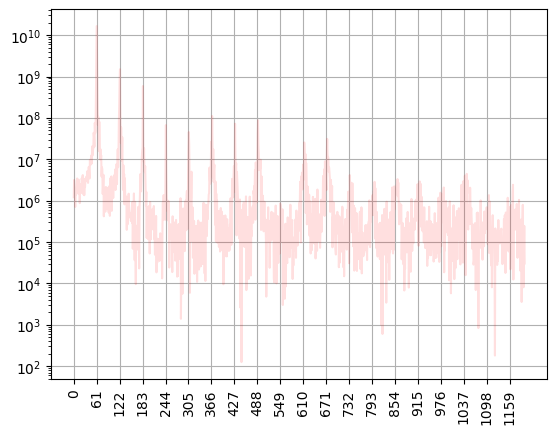

61
harmonic_areas: [np.float64(21792109834.23878), np.float64(2984570883.3930435), np.float64(719933788.7650491), np.float64(89297366.91159311), np.float64(115241688.37575908), np.float64(254863557.5058989), np.float64(140816082.27944076), np.float64(237245894.88313413), np.float64(6045085.132086585), np.float64(109169324.60254699)]
61
harmonic_areas: [np.float64(388388970.89750725), np.float64(86435147.42897676), np.float64(62707659.85023073), np.float64(8523231.750028696), np.float64(291179.510801899), np.float64(879507.823082242), np.float64(191369.71290892697), np.float64(1219435.54353197), np.float64(120062.66632379779), np.float64(232067.62255628622)]



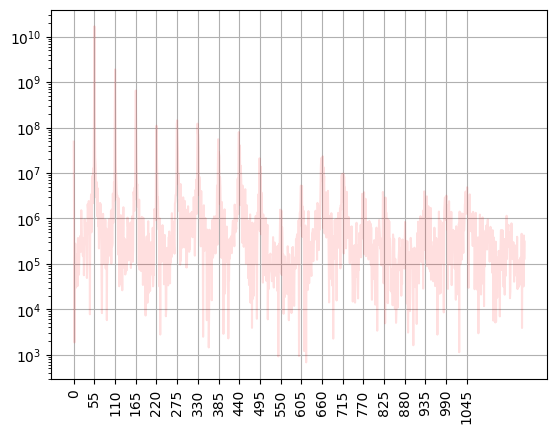

55
harmonic_areas: [np.float64(17530451399.407177), np.float64(2222346041.567559), np.float64(921741402.131053), np.float64(218171020.320457), np.float64(415172933.2428592), np.float64(358666260.0025703), np.float64(155780778.65634552), np.float64(234945889.5312671), np.float64(67358699.9426696), np.float64(6520095.588267331)]
55
harmonic_areas: [np.float64(421891808.0151418), np.float64(95821973.43754461), np.float64(37913375.030348204), np.float64(3062485.1311660064), np.float64(3244670.7921445807), np.float64(557758.859583179), np.float64(515566.02652387245), np.float64(1606626.4412875564), np.float64(323936.2835352737), np.float64(147743.6966643624)]



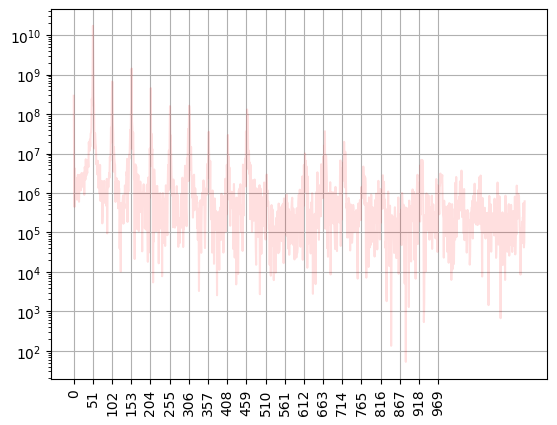

51
harmonic_areas: [np.float64(21187145241.302956), np.float64(1674845286.1443393), np.float64(1959307188.7536924), np.float64(555017581.2768898), np.float64(274980216.0909137), np.float64(490413124.2165319), np.float64(90801404.11330758), np.float64(60317153.174054615), np.float64(363485212.68419755), np.float64(16523412.496521423)]
51
harmonic_areas: [np.float64(415214692.53217596), np.float64(124115802.78476325), np.float64(26741117.894593682), np.float64(4354174.565481025), np.float64(3009297.067070847), np.float64(2223062.1288064956), np.float64(527991.8195428645), np.float64(653717.8834857674), np.float64(491287.17467867397), np.float64(186281.92211880174)]



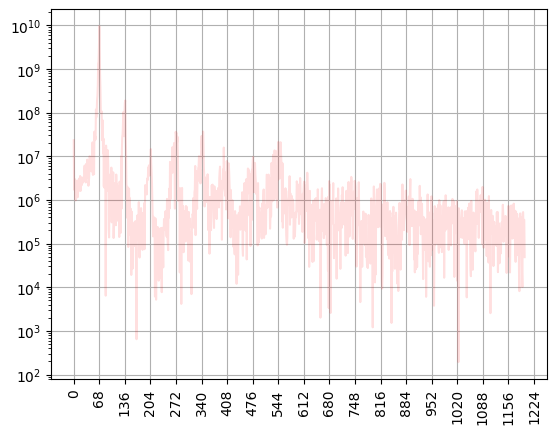

68
harmonic_areas: [np.float64(22245934209.849937), np.float64(867477831.3232485), np.float64(88015046.55432217), np.float64(302280916.2591802), np.float64(225855042.17297283), np.float64(82297112.72027978), np.float64(97355453.04712242), np.float64(189776746.6906566), np.float64(35897331.22646089), np.float64(18537138.049103815)]
68
harmonic_areas: [np.float64(520825675.21998435), np.float64(80697226.08326866), np.float64(37043136.29314416), np.float64(3235181.8377722916), np.float64(1284491.4454293759), np.float64(1041659.9265001018), np.float64(473182.05081191694), np.float64(1024481.483109375), np.float64(189059.5680973396), np.float64(150685.6127228868)]



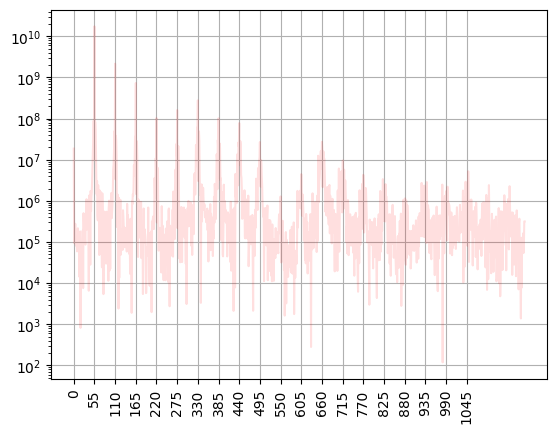

55
harmonic_areas: [np.float64(17839853850.936256), np.float64(2354253753.1591444), np.float64(887343910.8134874), np.float64(144460615.7137028), np.float64(268792940.8400051), np.float64(560216535.4591044), np.float64(254714005.67084152), np.float64(247515767.81293544), np.float64(104269010.61961262), np.float64(5105198.22062792)]
55
harmonic_areas: [np.float64(429845064.654138), np.float64(99351384.88160467), np.float64(37910049.79562979), np.float64(2681409.4913691725), np.float64(3117374.968454214), np.float64(924100.131284606), np.float64(813583.5404431064), np.float64(1713798.3720089893), np.float64(529902.4968258425), np.float64(143190.4667124855)]



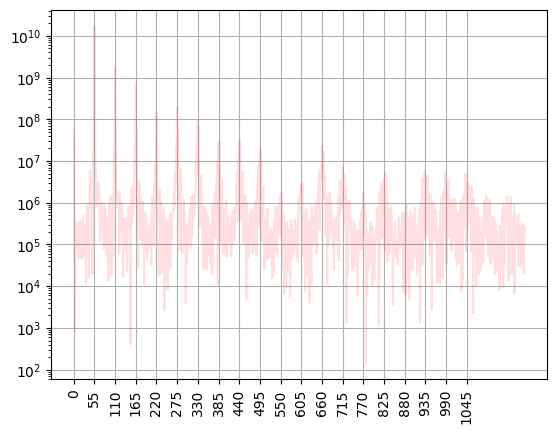

55
harmonic_areas: [np.float64(17531544863.55082), np.float64(2067009853.6666758), np.float64(970245063.4693834), np.float64(260496690.33244365), np.float64(454122976.22412926), np.float64(357831572.9758521), np.float64(138676617.15944636), np.float64(158407639.77046213), np.float64(113668725.82659115), np.float64(11460898.19574458)]
55
harmonic_areas: [np.float64(437601602.08937496), np.float64(96181577.11509298), np.float64(37092191.12503813), np.float64(2458405.180738974), np.float64(3434389.606962126), np.float64(637392.6335975742), np.float64(465985.939436997), np.float64(1214299.7557226338), np.float64(466402.5791890194), np.float64(84061.49676232025)]



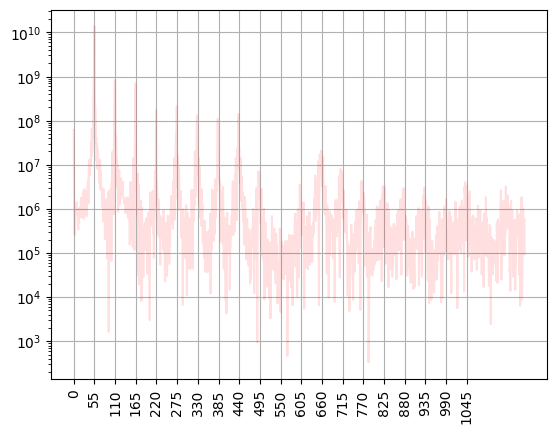

55
harmonic_areas: [np.float64(17213794436.4159), np.float64(2066010569.852197), np.float64(912568308.1469886), np.float64(207561239.4621617), np.float64(403864889.78682095), np.float64(409150989.93517524), np.float64(212357955.11746615), np.float64(318062070.15250117), np.float64(36909231.707392685), np.float64(1766409.0492737344)]
55
harmonic_areas: [np.float64(420151628.08037895), np.float64(93533393.74791764), np.float64(39060285.517130114), np.float64(2497557.2929768288), np.float64(3165100.1106763543), np.float64(621215.7546633977), np.float64(629982.4657490588), np.float64(1814469.9553588026), np.float64(369920.67457781226), np.float64(168747.39030889337)]



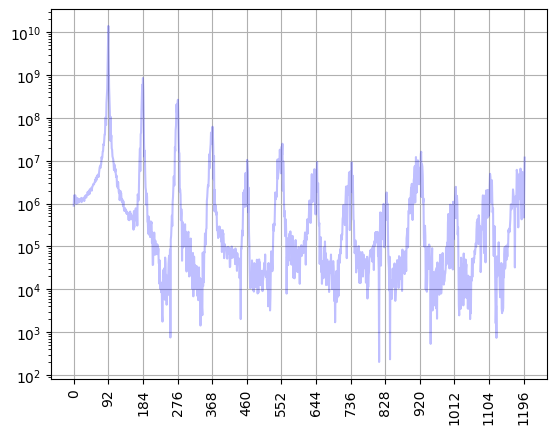

92
harmonic_areas: [np.float64(26310056652.506657), np.float64(3026064756.457969), np.float64(1300457259.8372974), np.float64(371581293.58732057), np.float64(51685659.791606866), np.float64(193063287.0989174), np.float64(72733981.3170702), np.float64(60420730.31282928), np.float64(13184551.555729724), np.float64(158277251.80268446)]
92
harmonic_areas: [np.float64(359888083.8919639), np.float64(71297021.55633746), np.float64(52759672.39862502), np.float64(6743304.239271134), np.float64(1365393.6948835677), np.float64(1139122.0102931885), np.float64(92385.7690500329), np.float64(794575.4309936176), np.float64(488689.2092441205), np.float64(280098.64902754046)]



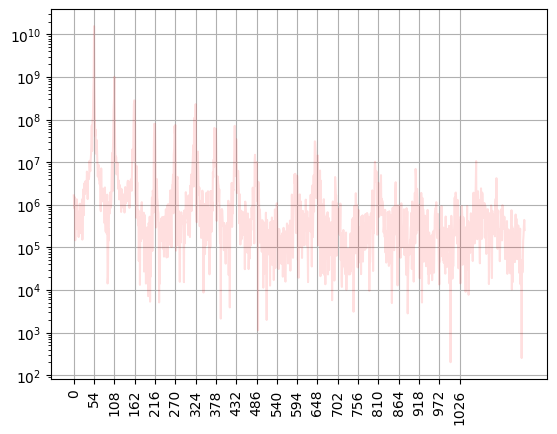

54
harmonic_areas: [np.float64(18212467278.493126), np.float64(1823624681.30376), np.float64(1020960093.8092271), np.float64(296094200.13820696), np.float64(267934030.6396951), np.float64(663824421.6488107), np.float64(234604802.26133102), np.float64(219135759.51262528), np.float64(74864441.05500454), np.float64(6279671.007368609)]
54
harmonic_areas: [np.float64(410583240.9280295), np.float64(103155940.85255642), np.float64(35503914.6737589), np.float64(3751854.4434079486), np.float64(2830724.0750477863), np.float64(808862.3154439682), np.float64(727355.74976392), np.float64(1884927.1388106747), np.float64(311399.02517877024), np.float64(185265.09575129554)]



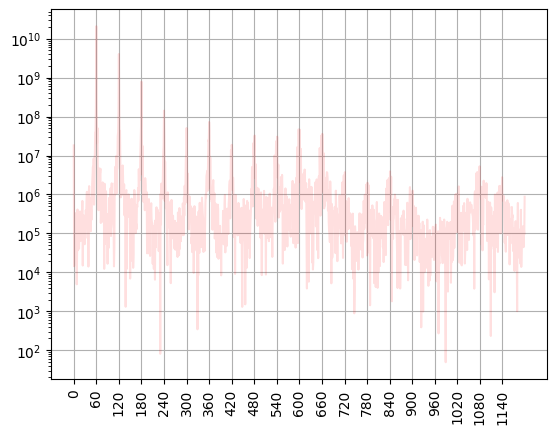

60
harmonic_areas: [np.float64(21572387835.675365), np.float64(4529797743.85946), np.float64(1015479264.5102313), np.float64(224840880.23493192), np.float64(101180092.63818732), np.float64(204547393.34392363), np.float64(75602499.20663784), np.float64(114688629.24081236), np.float64(112610092.9832477), np.float64(178946326.94878381)]
60
harmonic_areas: [np.float64(384036418.77932465), np.float64(91399325.6356466), np.float64(63088105.154670425), np.float64(13015912.749966808), np.float64(325171.79184433224), np.float64(870498.8623297866), np.float64(129670.44101126253), np.float64(860438.2464464565), np.float64(343533.06210189057), np.float64(267659.7418243976)]



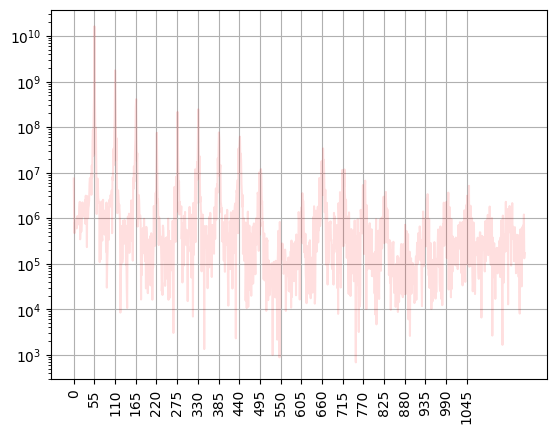

55
harmonic_areas: [np.float64(18265420116.624577), np.float64(2828746868.913246), np.float64(929607322.8292813), np.float64(122465403.65208471), np.float64(343038437.61695313), np.float64(481309903.1242077), np.float64(254820763.36959934), np.float64(291620983.855544), np.float64(70741687.10232711), np.float64(3994534.67757616)]
55
harmonic_areas: [np.float64(416584243.60300577), np.float64(97299162.67431411), np.float64(40947591.69676541), np.float64(3167656.6467959005), np.float64(2787522.0962847644), np.float64(1013204.3243619326), np.float64(945817.7220390309), np.float64(1890909.7419315549), np.float64(453500.51761851984), np.float64(150334.33568386192)]



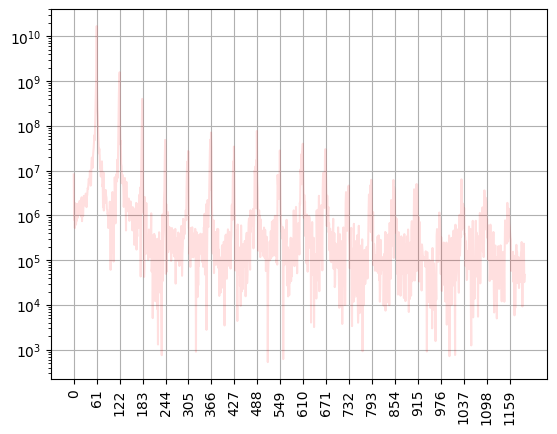

61
harmonic_areas: [np.float64(21310429879.023727), np.float64(3720781945.313391), np.float64(807816396.4454001), np.float64(110242200.82158206), np.float64(96881928.52239324), np.float64(207145601.89682117), np.float64(74680983.70897272), np.float64(151038682.47051352), np.float64(76207189.26584171), np.float64(167643848.72611508)]
61
harmonic_areas: [np.float64(388248807.79215676), np.float64(88666892.85582785), np.float64(61787605.23361687), np.float64(10972404.343888626), np.float64(237271.21916119757), np.float64(889774.7891780967), np.float64(135949.07952340544), np.float64(1004126.3955143121), np.float64(253620.10978771647), np.float64(280363.9640192104)]



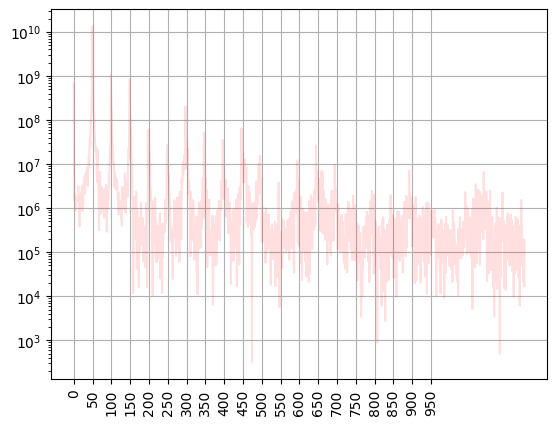

50
harmonic_areas: [np.float64(21184997796.633198), np.float64(1671102068.9624019), np.float64(1585534682.1296093), np.float64(212855839.05901048), np.float64(73323029.13196848), np.float64(495708808.42476183), np.float64(118213475.43966523), np.float64(111758009.18901196), np.float64(213413339.33742294), np.float64(72254307.84404768)]
50
harmonic_areas: [np.float64(406922677.8688287), np.float64(132635553.90864538), np.float64(21301421.8899347), np.float64(6954005.937482302), np.float64(1356865.1509068722), np.float64(3841170.9889706834), np.float64(153922.11762476814), np.float64(238695.58364973578), np.float64(705072.6989846737), np.float64(157675.83227334954)]



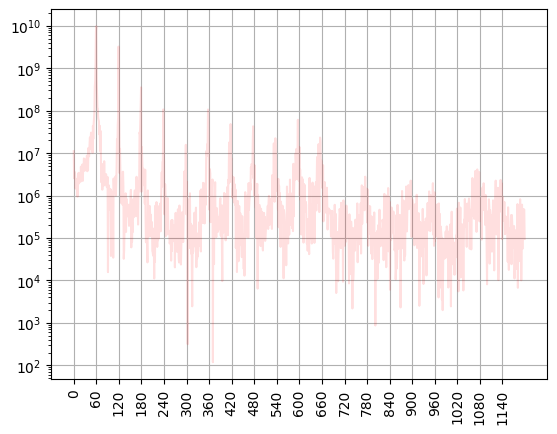

60
harmonic_areas: [np.float64(20883890410.342335), np.float64(3631620606.3450427), np.float64(652335905.436605), np.float64(170557419.64698678), np.float64(34408571.31969106), np.float64(273054971.05750906), np.float64(116980795.53814735), np.float64(108518861.836307), np.float64(78152231.28606126), np.float64(156581083.0658764)]
60
harmonic_areas: [np.float64(378114671.9476226), np.float64(90008866.17802094), np.float64(59019265.70796935), np.float64(12243057.452008802), np.float64(474830.83951950964), np.float64(970564.1787010491), np.float64(181927.89918321627), np.float64(898155.9896157781), np.float64(371146.534468974), np.float64(281030.70479666744)]



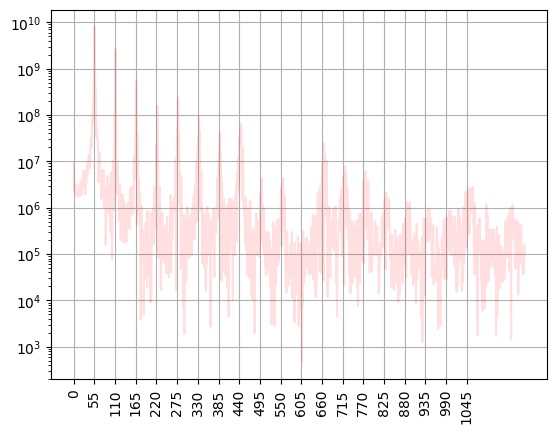

55
harmonic_areas: [np.float64(17746107632.4205), np.float64(3010952885.157398), np.float64(1125222029.1743252), np.float64(255161330.22144696), np.float64(583989799.0130084), np.float64(284158311.70336366), np.float64(158373778.9534813), np.float64(346773973.6178976), np.float64(16995619.46995122), np.float64(22205134.102132466)]
55
harmonic_areas: [np.float64(422083213.62934023), np.float64(96808307.69072057), np.float64(40646677.33724079), np.float64(2236180.2053319854), np.float64(3726864.617138128), np.float64(717732.7053532264), np.float64(486048.86589355464), np.float64(1346145.9315777873), np.float64(412649.8636081283), np.float64(274657.1376477798)]



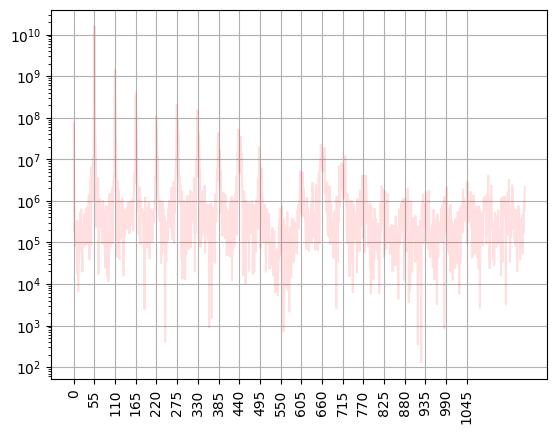

55
harmonic_areas: [np.float64(17234382327.598495), np.float64(2043409888.918096), np.float64(899726766.2358862), np.float64(256941761.49955487), np.float64(470848275.9441978), np.float64(361800863.8479267), np.float64(147126119.5719627), np.float64(240522361.3155698), np.float64(55670437.404748484), np.float64(4148714.1026828876)]
55
harmonic_areas: [np.float64(430383550.06749326), np.float64(97094208.70455898), np.float64(38752314.61997754), np.float64(2618969.239040118), np.float64(3367810.893793848), np.float64(672208.0986373133), np.float64(507640.4748992867), np.float64(1680149.1926986752), np.float64(296442.1462376017), np.float64(149203.7145215084)]



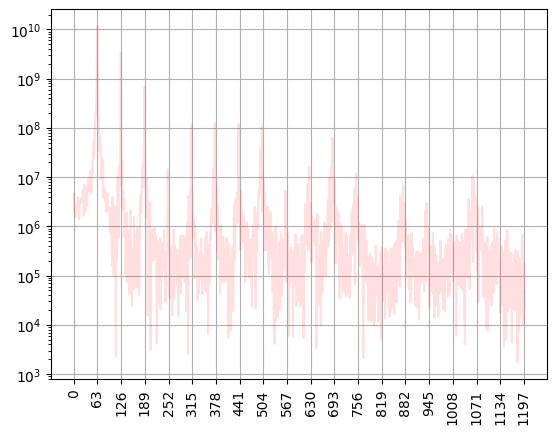

63
harmonic_areas: [np.float64(23061593997.256336), np.float64(3572084857.2294974), np.float64(1027347970.8821083), np.float64(24087918.19315074), np.float64(168493421.14796343), np.float64(235607658.27616268), np.float64(180258270.92381215), np.float64(338809354.4003223), np.float64(11680524.457942089), np.float64(57027171.19692456)]
63
harmonic_areas: [np.float64(402493485.28744227), np.float64(85536414.75019038), np.float64(65217629.57742807), np.float64(6682851.597820069), np.float64(130328.6216847355), np.float64(746966.4293726771), np.float64(306684.01426274667), np.float64(1399243.6508540553), np.float64(41731.40155493073), np.float64(129738.31231785084)]



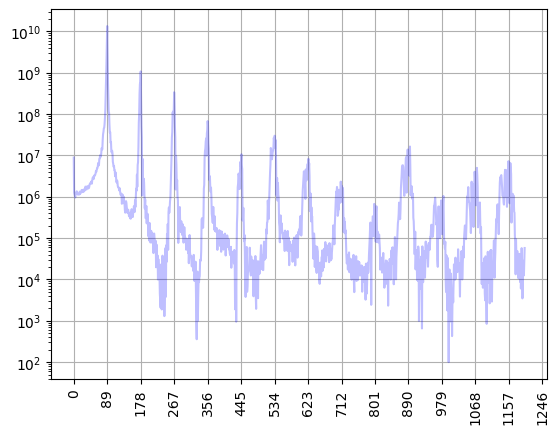

89
harmonic_areas: [np.float64(24975132951.967907), np.float64(2969284054.1758265), np.float64(1154361018.4527726), np.float64(346992974.2526113), np.float64(62877423.76616544), np.float64(280698875.90420115), np.float64(80189725.15401538), np.float64(26618524.56209705), np.float64(6221933.254015551), np.float64(157396560.8834468)]
89
harmonic_areas: [np.float64(356952476.41929865), np.float64(74219064.29128319), np.float64(53941234.6871348), np.float64(7271047.0010453), np.float64(1047684.9942523289), np.float64(1327481.3046030158), np.float64(40636.48889077182), np.float64(452594.4161633485), np.float64(680825.3180535501), np.float64(301101.6248839314)]



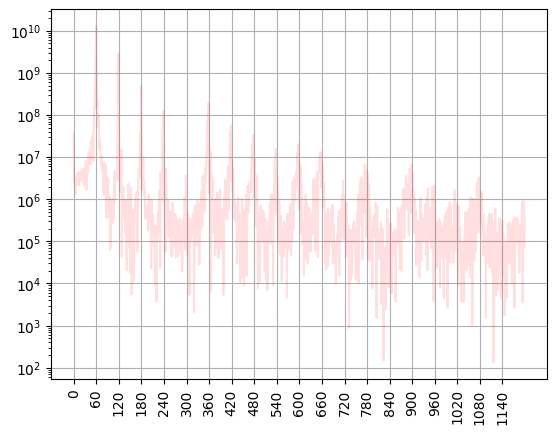

60
harmonic_areas: [np.float64(21009806069.30916), np.float64(3964886143.5127172), np.float64(627973940.7481713), np.float64(315113613.2238069), np.float64(8861583.759926522), np.float64(462656348.6534428), np.float64(179791434.05104023), np.float64(151341822.05399245), np.float64(53566741.52640368), np.float64(80645640.95822924)]
60
harmonic_areas: [np.float64(380397095.86706764), np.float64(88515931.6789807), np.float64(58704363.180744015), np.float64(12972206.53049047), np.float64(680784.8079731422), np.float64(1337778.244493931), np.float64(212026.1611805338), np.float64(975993.2904237397), np.float64(281943.4399702506), np.float64(180505.02794443094)]



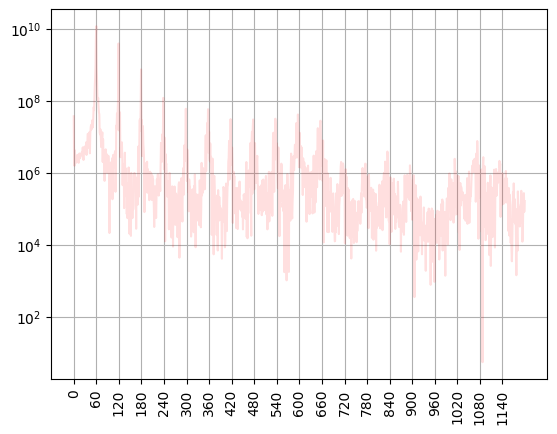

60
harmonic_areas: [np.float64(21298283440.33127), np.float64(4516842205.450444), np.float64(1002624971.1096065), np.float64(224306314.32577914), np.float64(99835023.88072479), np.float64(206532790.86417073), np.float64(77248165.70460057), np.float64(114832086.87755293), np.float64(124762342.69321324), np.float64(191455438.72342044)]
60
harmonic_areas: [np.float64(377641161.43159056), np.float64(89688219.07053441), np.float64(63257430.01939109), np.float64(12952912.200205151), np.float64(447825.62410699634), np.float64(950033.2586607002), np.float64(191816.03774946538), np.float64(920539.6495921414), np.float64(332268.0261623153), np.float64(338051.5214881764)]



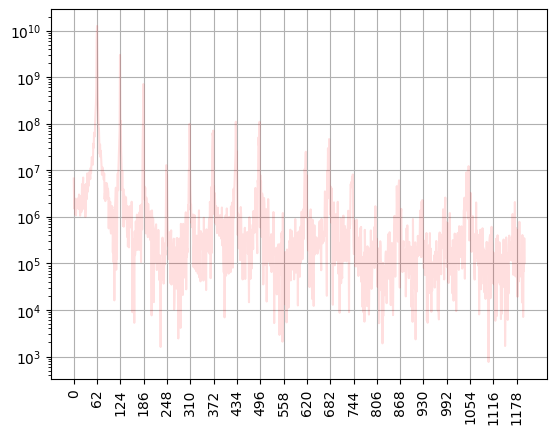

62
harmonic_areas: [np.float64(23216368311.243217), np.float64(3441487617.4234686), np.float64(981928847.0088322), np.float64(30848528.740268044), np.float64(155543031.08204648), np.float64(249247933.37196523), np.float64(225783790.15698695), np.float64(314927069.136127), np.float64(3828013.167725551), np.float64(79347599.3015425)]
62
harmonic_areas: [np.float64(414387648.81044257), np.float64(86287675.8654015), np.float64(65034195.441870674), np.float64(6343254.2938624825), np.float64(71708.17943722842), np.float64(1014432.5825113041), np.float64(454785.86057113385), np.float64(1364506.8396002906), np.float64(12656.204979479831), np.float64(151483.54123129367)]



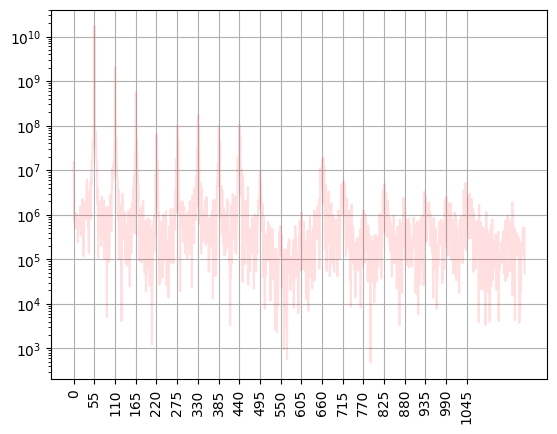

55
harmonic_areas: [np.float64(17764257207.654293), np.float64(2450461115.66575), np.float64(849928316.3313153), np.float64(146770833.14335665), np.float64(294544079.1523816), np.float64(500434317.59890544), np.float64(254543348.83496305), np.float64(336810625.0206324), np.float64(43898753.15534608), np.float64(3014127.673638594)]
55
harmonic_areas: [np.float64(422474897.0688057), np.float64(99497369.70114303), np.float64(38309017.12109928), np.float64(3117138.945186471), np.float64(2855716.97691721), np.float64(778604.9442759583), np.float64(680282.0642682017), np.float64(1828471.0034574503), np.float64(373289.4896763714), np.float64(201566.79828666002)]



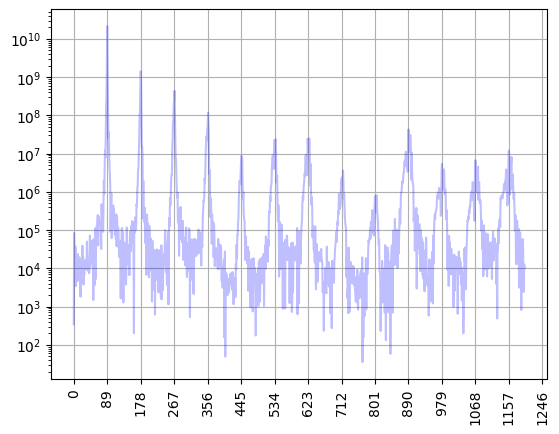

89
harmonic_areas: [np.float64(26305528257.537037), np.float64(3179666764.56853), np.float64(1235673445.8496754), np.float64(409072225.34696877), np.float64(47093927.41058774), np.float64(169507446.5391936), np.float64(192867902.24084294), np.float64(22333341.021762304), np.float64(6611371.572657076), np.float64(297867061.9514827)]
89
harmonic_areas: [np.float64(370649395.507975), np.float64(75210378.85550812), np.float64(53849769.489223585), np.float64(7459248.261124422), np.float64(1299443.475102819), np.float64(1007077.2391450572), np.float64(48120.99269142278), np.float64(563353.8235579367), np.float64(612668.3749750452), np.float64(487758.90738540166)]



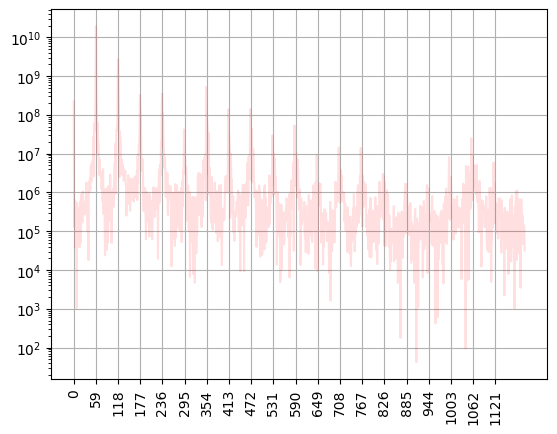

59
harmonic_areas: [np.float64(22548378602.343212), np.float64(5005341147.088675), np.float64(783486442.4193726), np.float64(839728708.2854785), np.float64(122088744.0535812), np.float64(983499290.8329488), np.float64(251453870.97614777), np.float64(393436032.140538), np.float64(100605500.48524478), np.float64(132114593.90740746)]
59
harmonic_areas: [np.float64(366059765.7711092), np.float64(90316356.61506468), np.float64(55774276.64234743), np.float64(16990994.25179798), np.float64(1627749.8622623147), np.float64(1923964.48833919), np.float64(128914.54064326856), np.float64(1310945.964599811), np.float64(369493.0391918941), np.float64(183347.48269678847)]



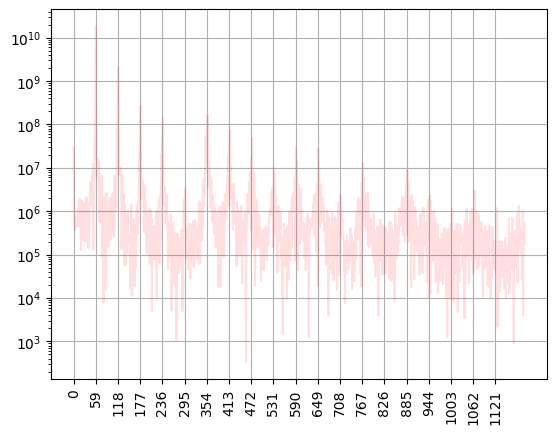

59
harmonic_areas: [np.float64(21545535334.19319), np.float64(3866202029.974716), np.float64(610885911.9468591), np.float64(301432625.3261285), np.float64(12795079.748220807), np.float64(460385565.18339777), np.float64(190426933.20801812), np.float64(145272803.98103794), np.float64(53046683.971532375), np.float64(85323231.79790926)]
59
harmonic_areas: [np.float64(388489360.3101634), np.float64(89596959.81797244), np.float64(57486652.550552435), np.float64(12562569.10782485), np.float64(564504.0439599284), np.float64(1251804.8167046122), np.float64(259383.54346170626), np.float64(998057.0899017208), np.float64(272030.88385675347), np.float64(161955.08961399138)]



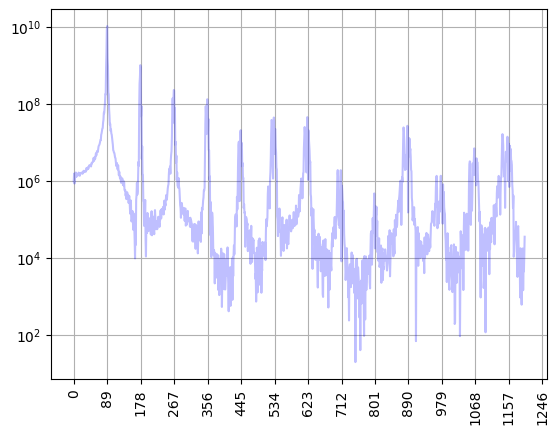

89
harmonic_areas: [np.float64(25909227503.08368), np.float64(2934029209.471495), np.float64(1013200340.4552189), np.float64(530461461.87482095), np.float64(106840938.69164571), np.float64(286342053.67585117), np.float64(231978110.09146085), np.float64(11521026.97730346), np.float64(2257413.223448666), np.float64(207679465.3026925)]
89
harmonic_areas: [np.float64(363642241.6125012), np.float64(74838445.03463653), np.float64(52496528.87932664), np.float64(7943499.215944122), np.float64(1629034.3667907538), np.float64(1288343.8826741427), np.float64(33632.87320418919), np.float64(470548.8582929481), np.float64(572046.3641648017), np.float64(417536.38501665357)]



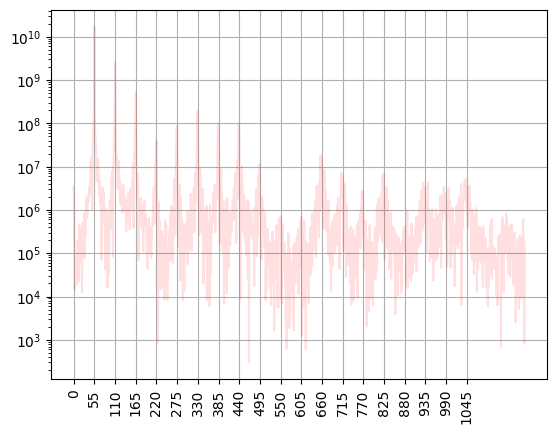

55
harmonic_areas: [np.float64(18274653138.518093), np.float64(3022838154.6499023), np.float64(930375801.2846378), np.float64(112991914.46496584), np.float64(284990808.8155714), np.float64(586088489.7463864), np.float64(322597023.9248202), np.float64(383806972.07013696), np.float64(58422022.85048618), np.float64(6030120.188928883)]
55
harmonic_areas: [np.float64(408621721.97015846), np.float64(98243829.07055897), np.float64(42871973.566245876), np.float64(3810783.451941955), np.float64(2609574.227511053), np.float64(878625.8453619181), np.float64(924337.6144665026), np.float64(2097470.9593980196), np.float64(427310.10292047856), np.float64(218585.0760210812)]



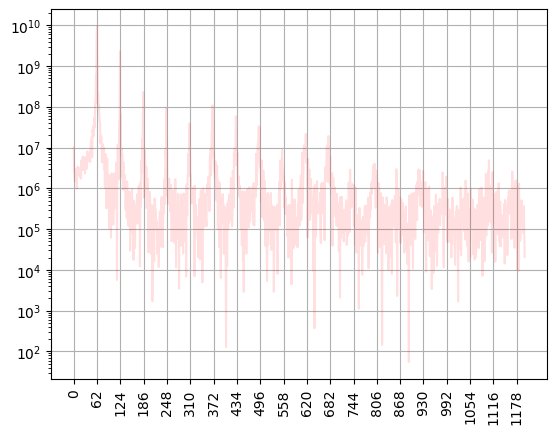

62
harmonic_areas: [np.float64(20491289511.61051), np.float64(2579917464.3407826), np.float64(410512563.1650446), np.float64(140077719.66327387), np.float64(88532208.15342668), np.float64(276562112.99316275), np.float64(142075796.42133492), np.float64(146158590.52457714), np.float64(39748496.25182888), np.float64(118054606.59159143)]
62
harmonic_areas: [np.float64(405175025.64621055), np.float64(86055019.84840609), np.float64(56945754.419538334), np.float64(8130633.870139821), np.float64(251962.23104579098), np.float64(1131597.1223069548), np.float64(272924.3416505299), np.float64(1005185.3797979816), np.float64(180950.8735396096), np.float64(275004.93908994296)]



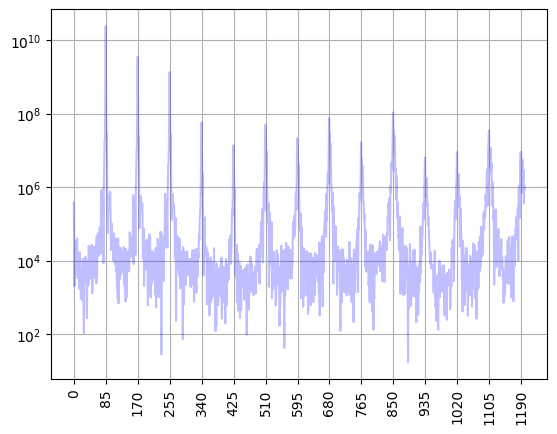

85
harmonic_areas: [np.float64(25297095519.761925), np.float64(4012488107.834186), np.float64(1793190148.663174), np.float64(89016627.88838787), np.float64(27418757.671486784), np.float64(145226805.81575027), np.float64(59583966.21052664), np.float64(174238555.65990376), np.float64(38607558.81971011), np.float64(252422265.3953416)]
85
harmonic_areas: [np.float64(398766260.1441697), np.float64(84413364.27783704), np.float64(60023444.95988523), np.float64(6332508.071796699), np.float64(367372.5489819283), np.float64(890078.6260933402), np.float64(4750.913092930948), np.float64(1049355.3618200512), np.float64(176270.24903377096), np.float64(565639.5973157759)]



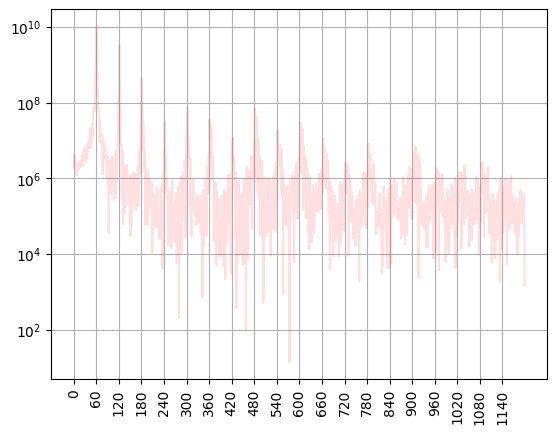

60
harmonic_areas: [np.float64(21157000381.778732), np.float64(3838321320.873778), np.float64(802980457.7823648), np.float64(60536314.21338349), np.float64(187800498.0267924), np.float64(143818069.9324689), np.float64(51601531.32290085), np.float64(219075415.37348413), np.float64(68414281.6404668), np.float64(97406206.54525997)]
60
harmonic_areas: [np.float64(400744225.7262148), np.float64(88597711.65595338), np.float64(61827080.278687954), np.float64(9684250.177788964), np.float64(110210.09067510045), np.float64(928938.1703695976), np.float64(224492.21292175693), np.float64(1129705.5116025256), np.float64(153952.17832487024), np.float64(172943.5713253226)]



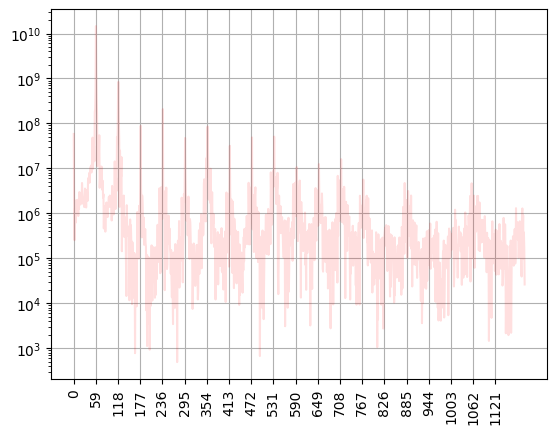

59
harmonic_areas: [np.float64(18053314984.12734), np.float64(2083169707.9239638), np.float64(113595260.18959019), np.float64(235308771.27861696), np.float64(77375216.29026197), np.float64(266106413.23837903), np.float64(55838728.76875855), np.float64(84497188.85678752), np.float64(128552144.96488371), np.float64(64218094.41418542)]
59
harmonic_areas: [np.float64(393234392.1697975), np.float64(89141921.05258265), np.float64(50424251.284420975), np.float64(11748878.180292267), np.float64(552486.7803564221), np.float64(1087675.2797941237), np.float64(115245.00833439767), np.float64(789335.0384222479), np.float64(539398.653683075), np.float64(165306.1736198455)]



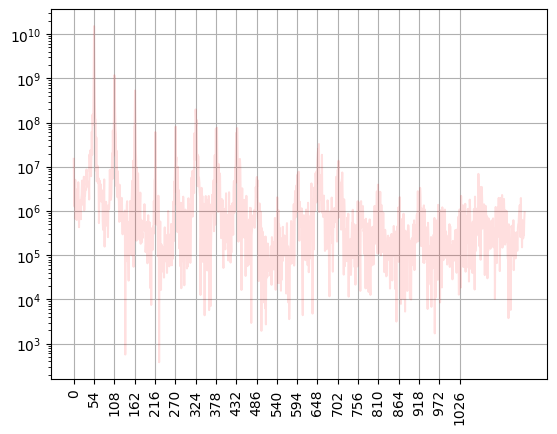

54
harmonic_areas: [np.float64(18531790255.540966), np.float64(2909353222.954768), np.float64(865750815.2346138), np.float64(97609341.0688065), np.float64(180520725.38741946), np.float64(717430484.0251087), np.float64(301398327.66649103), np.float64(349346034.3518827), np.float64(35642303.33775678), np.float64(7049788.401737028)]
54
harmonic_areas: [np.float64(413699395.8550101), np.float64(100761106.54136159), np.float64(36737203.793827005), np.float64(4046804.6337444787), np.float64(2568780.788749193), np.float64(764667.3696357302), np.float64(574082.6023671741), np.float64(1871655.4170669825), np.float64(202713.95559592944), np.float64(198186.41696012495)]



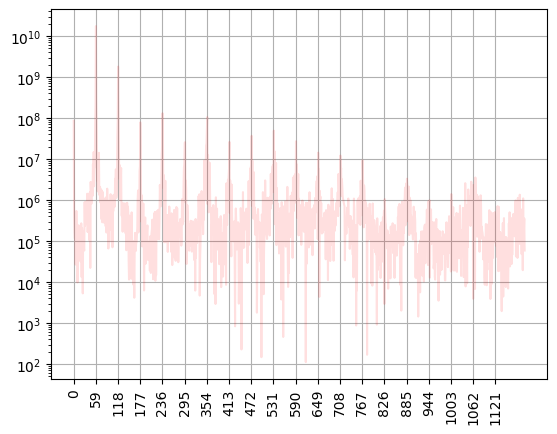

59
harmonic_areas: [np.float64(18235307473.393085), np.float64(2121459415.1580453), np.float64(120207856.76372097), np.float64(251246903.42436236), np.float64(76966316.77896567), np.float64(252220460.6487271), np.float64(55731905.677682556), np.float64(80854843.9589842), np.float64(117856128.79338029), np.float64(70356286.5289284)]
59
harmonic_areas: [np.float64(390639001.58048284), np.float64(89585300.32203037), np.float64(50714094.73047535), np.float64(12535665.848267589), np.float64(617587.3567579777), np.float64(945287.6551686858), np.float64(55783.151476038845), np.float64(728807.824603128), np.float64(512374.6540037008), np.float64(136351.54223625635)]



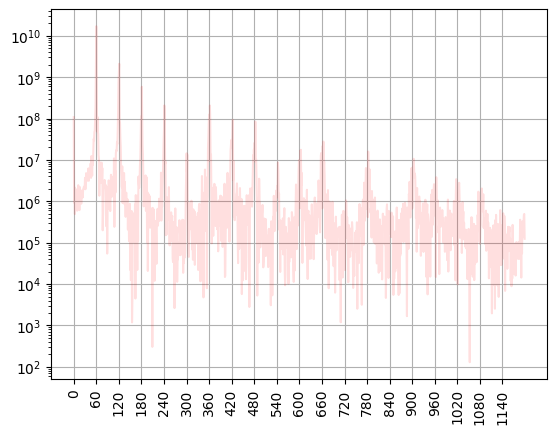

60
harmonic_areas: [np.float64(22666238138.628624), np.float64(4695396299.672314), np.float64(930436619.1877048), np.float64(455587539.02325016), np.float64(43646000.67474471), np.float64(616755845.7225262), np.float64(282711430.9797589), np.float64(211909497.94013283), np.float64(31394616.588093113), np.float64(77615722.3460502)]
60
harmonic_areas: [np.float64(386642144.6276126), np.float64(88732623.69728327), np.float64(61119510.78953623), np.float64(13548019.040739827), np.float64(726499.4830874831), np.float64(1758022.5035536126), np.float64(296484.3212110062), np.float64(1100064.7617177183), np.float64(208832.3579421822), np.float64(175826.14867232338)]



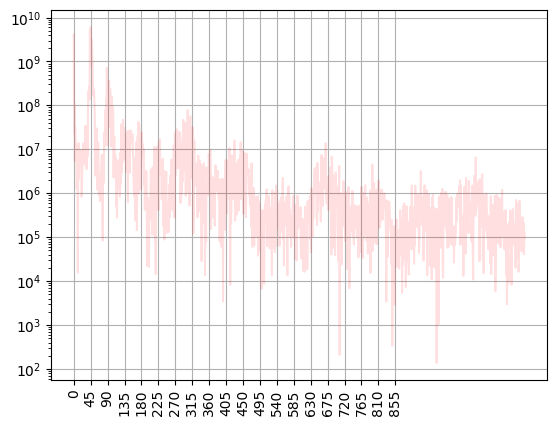

45
harmonic_areas: [np.float64(25234590291.02899), np.float64(2535766873.333583), np.float64(293473242.6181373), np.float64(225457494.40318674), np.float64(103218227.15948176), np.float64(140644172.5370201), np.float64(275528528.1022662), np.float64(58477550.00379655), np.float64(36949756.61449773), np.float64(70467838.5751844)]
45
harmonic_areas: [np.float64(327574853.25968045), np.float64(117007655.5341249), np.float64(11418058.050711216), np.float64(11984392.926102541), np.float64(890581.2833702917), np.float64(929098.0088494619), np.float64(597333.0043614763), np.float64(306132.93406992755), np.float64(415145.2209945044), np.float64(285015.69520241074)]



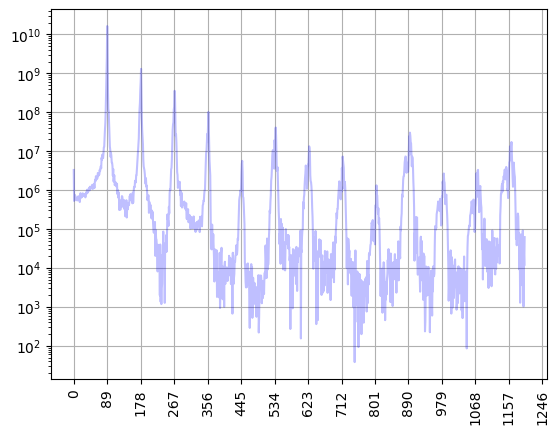

89
harmonic_areas: [np.float64(25775270594.27798), np.float64(3134459169.809583), np.float64(1298333742.3422737), np.float64(308530914.852144), np.float64(23863464.714190852), np.float64(198985960.06931406), np.float64(84503375.52125765), np.float64(44557557.32627367), np.float64(6646837.711898277), np.float64(228404956.94801337)]
89
harmonic_areas: [np.float64(361823737.8006112), np.float64(74093564.89096405), np.float64(54617727.879487455), np.float64(7250229.381658175), np.float64(1135514.3861138076), np.float64(1086922.3974993308), np.float64(68950.03425696223), np.float64(652250.0413787253), np.float64(556430.1187855911), np.float64(371755.51503993734)]



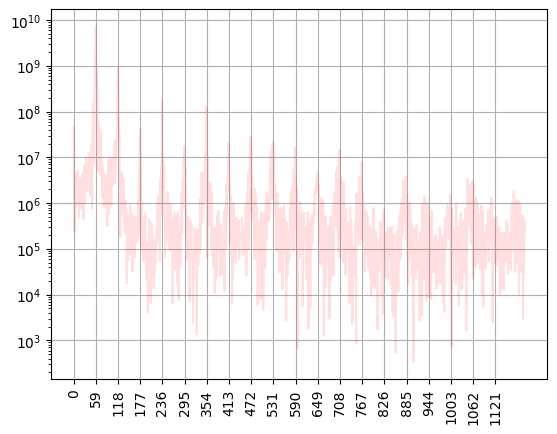

59
harmonic_areas: [np.float64(17527834950.04986), np.float64(1978011367.087728), np.float64(103290411.08773863), np.float64(229376987.3353204), np.float64(66127515.43231605), np.float64(274225276.7299398), np.float64(54457754.951579556), np.float64(76839243.9941946), np.float64(137449565.39597583), np.float64(57013879.34486573)]
59
harmonic_areas: [np.float64(381496610.65854955), np.float64(86451521.26969913), np.float64(48856923.11881355), np.float64(11370544.184881337), np.float64(679295.4260115013), np.float64(1153305.5755913951), np.float64(107323.80151362917), np.float64(730097.5750137577), np.float64(492530.83121573937), np.float64(123186.32358040051)]



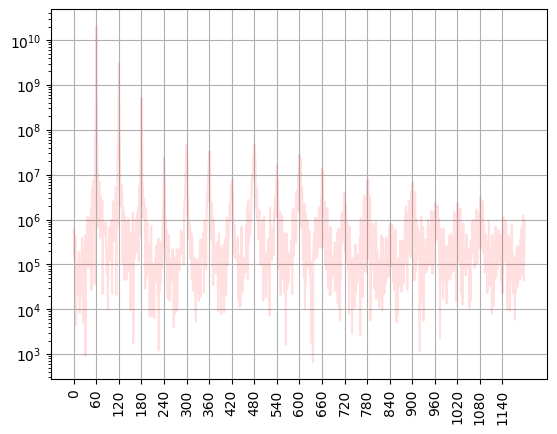

60
harmonic_areas: [np.float64(21594084713.313023), np.float64(3821327756.416765), np.float64(848202760.2982345), np.float64(55812562.0584659), np.float64(182432956.26709446), np.float64(134340640.9735178), np.float64(47320355.59336824), np.float64(224929909.31321692), np.float64(60865787.46563814), np.float64(107066420.2773624)]
60
harmonic_areas: [np.float64(404775215.0843956), np.float64(89565699.28889519), np.float64(62683805.24512925), np.float64(9481847.11705503), np.float64(71738.95394184944), np.float64(691825.8931879806), np.float64(156091.86818722362), np.float64(1066049.5448091729), np.float64(135413.6353710151), np.float64(172489.64295864583)]



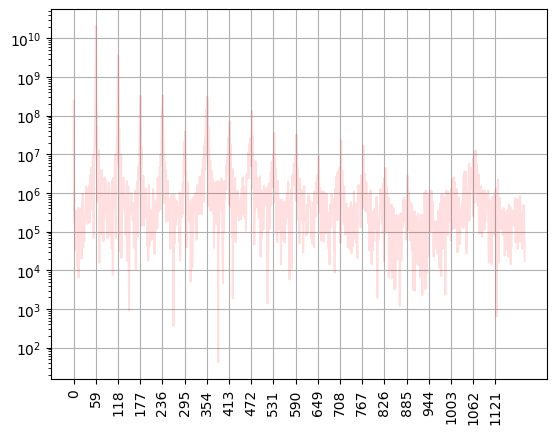

59
harmonic_areas: [np.float64(22575262377.1389), np.float64(5072538771.3422), np.float64(749348597.5766711), np.float64(848236801.8801773), np.float64(110080381.37655482), np.float64(965370576.5537297), np.float64(227260044.5299939), np.float64(366789790.1830951), np.float64(103769361.06788708), np.float64(112099655.17877048)]
59
harmonic_areas: [np.float64(372825344.16864544), np.float64(92119843.57968806), np.float64(55326185.353467375), np.float64(17000083.68887289), np.float64(1557121.4506795774), np.float64(1862959.2431911258), np.float64(103337.88466665422), np.float64(1205659.39337979), np.float64(386448.56024061004), np.float64(141394.85671782514)]



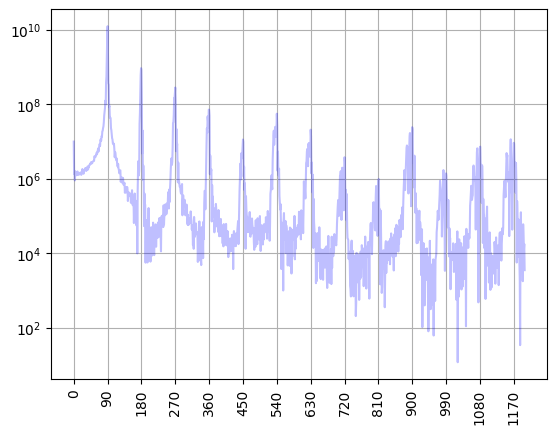

90
harmonic_areas: [np.float64(25422383313.311863), np.float64(2813956133.1886897), np.float64(1101567527.2994802), np.float64(364903670.0034428), np.float64(56763557.33415906), np.float64(254105185.93682045), np.float64(105915775.27621113), np.float64(21679798.169076867), np.float64(5729216.346772148), np.float64(158708329.9114757)]
90
harmonic_areas: [np.float64(361272630.6866136), np.float64(73243765.95259887), np.float64(53180378.370899096), np.float64(6440033.627235814), np.float64(1199940.2782348252), np.float64(1179804.1216872574), np.float64(39448.80348696606), np.float64(520469.331644237), np.float64(545654.7364740213), np.float64(341645.2746847383)]



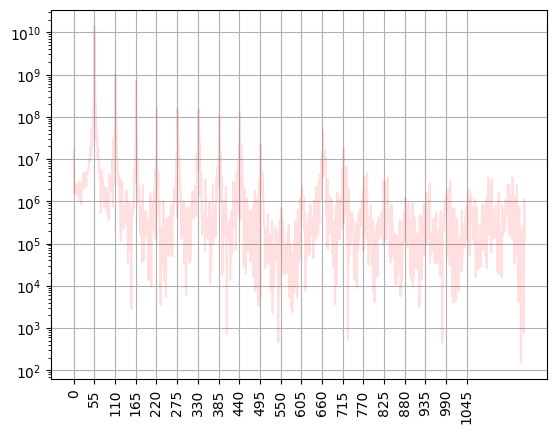

55
harmonic_areas: [np.float64(17724187951.72713), np.float64(2253137539.8845544), np.float64(930688235.8479908), np.float64(190747522.3421375), np.float64(310471505.41640127), np.float64(457425402.1558562), np.float64(222896581.79345754), np.float64(288249078.1505993), np.float64(54434693.113653585), np.float64(2970362.6368219284)]
55
harmonic_areas: [np.float64(415040097.00868225), np.float64(97160150.89458527), np.float64(37972345.4884241), np.float64(3082583.453303166), np.float64(3071615.9542834302), np.float64(668009.8775124564), np.float64(715262.2089754937), np.float64(1677744.2509091597), np.float64(370900.0775184642), np.float64(197930.81612350213)]



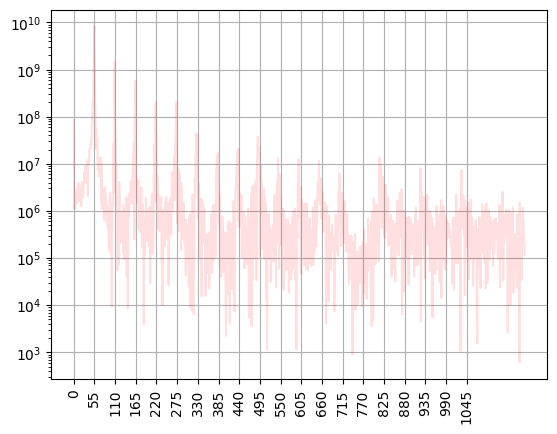

55
harmonic_areas: [np.float64(16914928937.255054), np.float64(1754901605.3798833), np.float64(1117555888.1340969), np.float64(448406248.0518838), np.float64(651359502.5657642), np.float64(192014229.6214544), np.float64(72867694.78337497), np.float64(98619677.88629812), np.float64(190006048.51546136), np.float64(45467011.15698488)]
55
harmonic_areas: [np.float64(427741531.0571403), np.float64(93132082.0907668), np.float64(36708991.16315524), np.float64(2186647.8657606845), np.float64(4091788.211869472), np.float64(604846.5522687181), np.float64(541825.0448940867), np.float64(1158900.4997357517), np.float64(537812.0511894397), np.float64(91484.26823820727)]



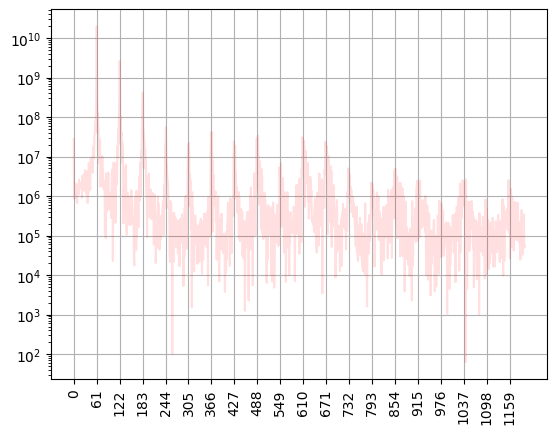

61
harmonic_areas: [np.float64(22859692499.171974), np.float64(4348373605.468509), np.float64(1232005429.5634708), np.float64(139239025.5760535), np.float64(84596273.26023614), np.float64(149925918.43843186), np.float64(83514229.80439359), np.float64(152852092.41167483), np.float64(29971673.31594578), np.float64(191060846.19972742)]
61
harmonic_areas: [np.float64(371083096.70673376), np.float64(86189426.38075075), np.float64(65128880.76431048), np.float64(11895946.991560608), np.float64(484796.9817417638), np.float64(624828.4789583005), np.float64(144283.33728864894), np.float64(891610.4700541114), np.float64(233457.54508447932), np.float64(319600.28550135234)]



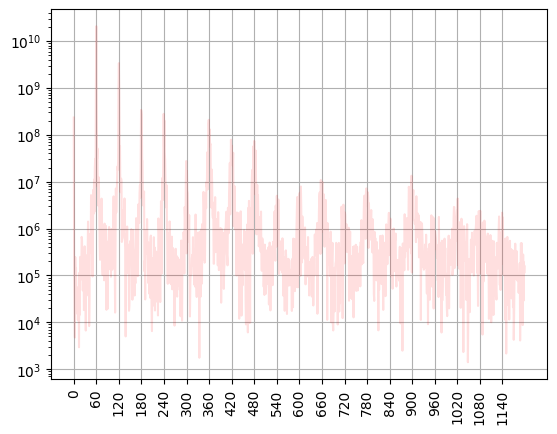

60
harmonic_areas: [np.float64(23369322193.93432), np.float64(5501965721.4796295), np.float64(1061129218.7420104), np.float64(714725170.2316208), np.float64(79535593.43311813), np.float64(907516493.6884005), np.float64(369318160.8938508), np.float64(326473569.32404506), np.float64(26257723.55979252), np.float64(47039685.75300699)]
60
harmonic_areas: [np.float64(392472221.905665), np.float64(91656125.71092951), np.float64(60361905.21218203), np.float64(14567103.055008087), np.float64(775552.8784771457), np.float64(2221531.614483902), np.float64(277991.71468360594), np.float64(1280659.5595707507), np.float64(178589.88899270975), np.float64(94345.33671632086)]



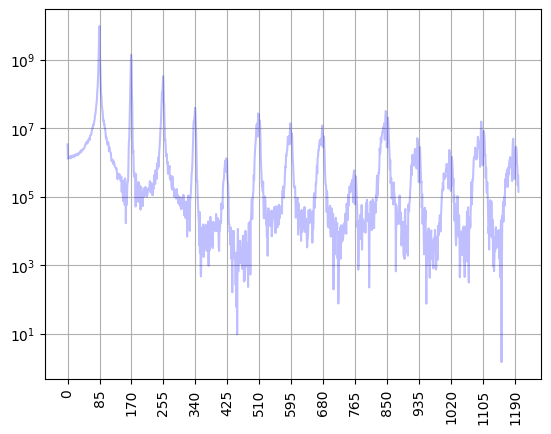

85
harmonic_areas: [np.float64(23964240439.033176), np.float64(3360430386.494671), np.float64(1220590890.2222812), np.float64(174293195.13168514), np.float64(10003896.646279454), np.float64(198286977.8765732), np.float64(100268637.69142392), np.float64(83911969.11776336), np.float64(5423009.573880296), np.float64(260259541.5301225)]
85
harmonic_areas: [np.float64(393053003.9244008), np.float64(82405125.52927333), np.float64(56820236.91855174), np.float64(6728452.752460775), np.float64(462566.9040596528), np.float64(1284768.1178604898), np.float64(27483.160474886274), np.float64(766579.9540208563), np.float64(301366.6891826235), np.float64(535054.8632467566)]



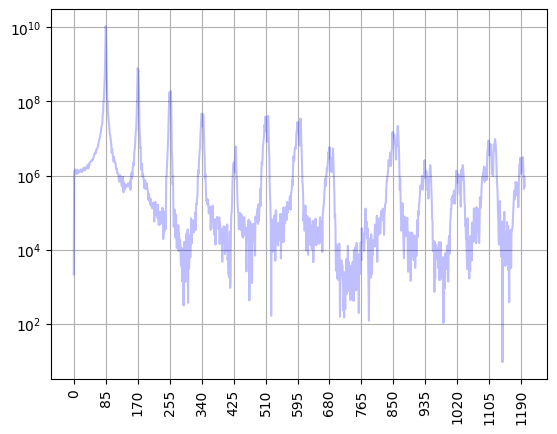

85
harmonic_areas: [np.float64(24819774813.23631), np.float64(2974262652.1773887), np.float64(981133994.4653443), np.float64(346850226.4817162), np.float64(29315066.254877657), np.float64(342868545.59724134), np.float64(293685233.9622105), np.float64(61178958.97796113), np.float64(753623.1722499488), np.float64(241498759.1643253)]
85
harmonic_areas: [np.float64(400532750.2278777), np.float64(81170157.80408873), np.float64(55201116.14565216), np.float64(7013137.140470387), np.float64(920735.9823313076), np.float64(1801386.2481410215), np.float64(128209.2720386323), np.float64(638737.265254239), np.float64(238145.39889703496), np.float64(581802.6348241386)]



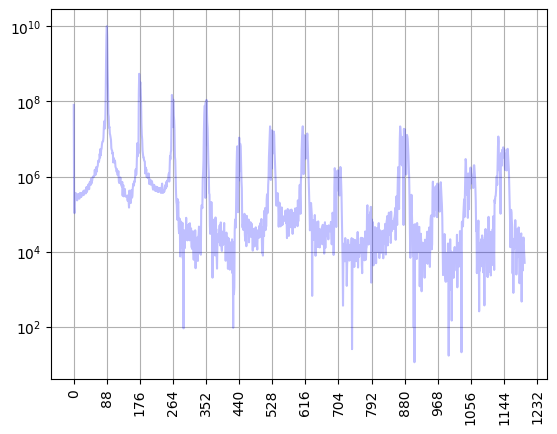

88
harmonic_areas: [np.float64(23777039757.229195), np.float64(2069954184.2683322), np.float64(665352952.3869723), np.float64(543082967.0731219), np.float64(60270611.42766567), np.float64(172676443.98386672), np.float64(167752743.233102), np.float64(18910749.00194926), np.float64(1504036.8859887149), np.float64(212783493.45532143)]
88
harmonic_areas: [np.float64(370924738.06685835), np.float64(72294320.63645609), np.float64(48858265.38243716), np.float64(7008078.922212548), np.float64(1021296.0652299715), np.float64(863093.4169682724), np.float64(92504.31790415931), np.float64(403344.1879783864), np.float64(589275.3338038152), np.float64(284533.0152905981)]



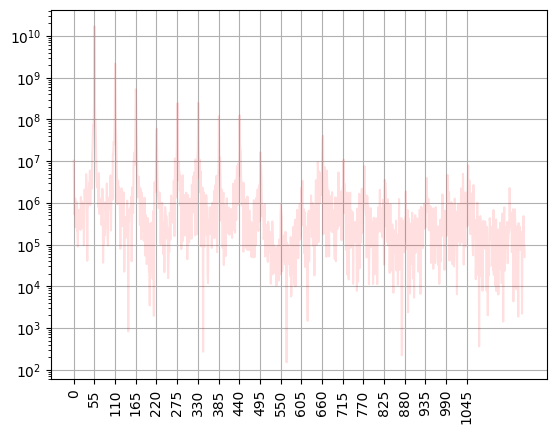

55
harmonic_areas: [np.float64(18328287890.802147), np.float64(2882537105.0452294), np.float64(994880217.6786242), np.float64(149219835.48067722), np.float64(401631091.37114507), np.float64(380194766.21317315), np.float64(190653321.3286306), np.float64(250892811.51787564), np.float64(46836742.66321549), np.float64(3751871.4313648636)]
55
harmonic_areas: [np.float64(417772827.8972175), np.float64(95894850.51315606), np.float64(40836243.47052779), np.float64(2939093.0443672263), np.float64(2962864.4963060822), np.float64(883003.9825618095), np.float64(897227.1516036999), np.float64(1636301.4887486591), np.float64(399055.7625386852), np.float64(131902.82938203437)]



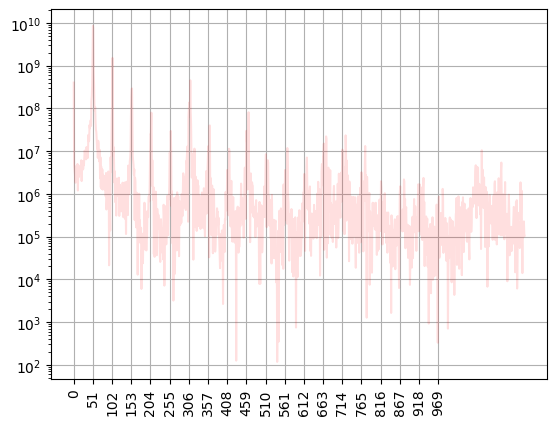

51
harmonic_areas: [np.float64(20406927960.612087), np.float64(2016532583.4294887), np.float64(942386616.4461364), np.float64(231897991.51747367), np.float64(70746862.32242501), np.float64(1120277160.7365263), np.float64(123680272.63921043), np.float64(37476626.28160502), np.float64(189928481.5688407), np.float64(33700289.389576666)]
51
harmonic_areas: [np.float64(383729632.1674496), np.float64(123158604.31396405), np.float64(27450502.973770607), np.float64(7712127.939544253), np.float64(1863965.9599128468), np.float64(2119329.8897065143), np.float64(1160960.892406037), np.float64(1325698.7537845627), np.float64(283133.27985727246), np.float64(412834.5461425852)]



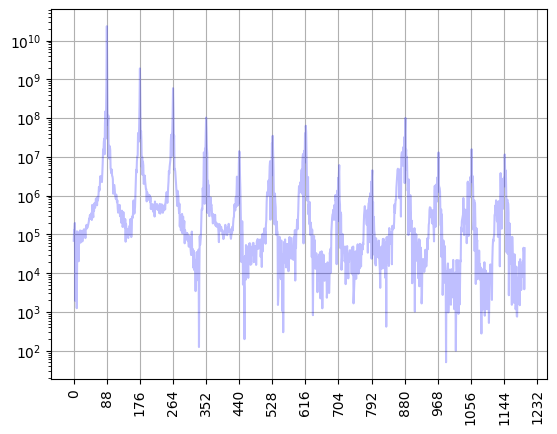

88
harmonic_areas: [np.float64(26055959549.594673), np.float64(2851394142.472605), np.float64(1175782642.2647283), np.float64(288089270.6590539), np.float64(52801445.12112099), np.float64(139013033.40135613), np.float64(264971965.27106556), np.float64(23706793.717158493), np.float64(20079927.69074985), np.float64(344949157.87744236)]
88
harmonic_areas: [np.float64(399149046.13413584), np.float64(80516569.1345106), np.float64(55534654.742047496), np.float64(6201160.38985471), np.float64(1214846.9547793912), np.float64(1053672.372136242), np.float64(92841.09245103647), np.float64(687863.1341061479), np.float64(296036.45501411107), np.float64(890788.2385789935)]



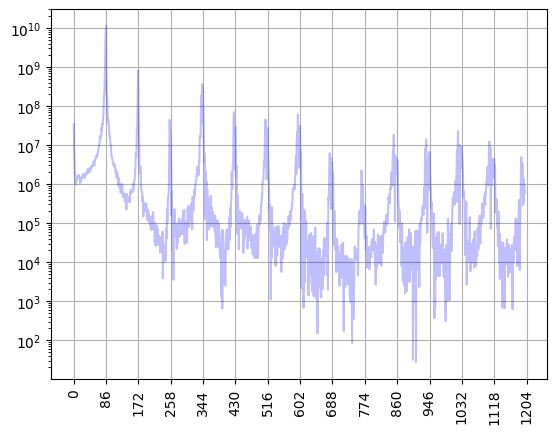

86
harmonic_areas: [np.float64(26561599560.97297), np.float64(1242835482.1050167), np.float64(111481285.15808618), np.float64(1455211788.180695), np.float64(225802324.18445852), np.float64(196885895.3653846), np.float64(236068827.72103515), np.float64(32936435.224164598), np.float64(8409259.01847282), np.float64(83987576.23533359)]
86
harmonic_areas: [np.float64(371545285.8730645), np.float64(81986552.5832661), np.float64(39259644.44609093), np.float64(11480053.256518943), np.float64(1527468.7553148996), np.float64(841437.3799054347), np.float64(233887.72891457507), np.float64(172971.2451504062), np.float64(662248.9732353038), np.float64(53935.81637688305)]



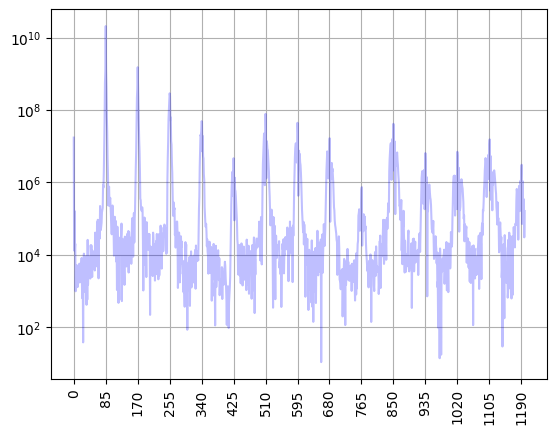

85
harmonic_areas: [np.float64(24353757586.047653), np.float64(2861225109.2331266), np.float64(1028850984.0137017), np.float64(209322026.45108038), np.float64(15144444.675240481), np.float64(229221309.10611537), np.float64(153502948.39776647), np.float64(85507492.42248562), np.float64(3237238.524749949), np.float64(210309400.8846352)]
85
harmonic_areas: [np.float64(410303413.76585424), np.float64(82865512.43750587), np.float64(54317110.834252246), np.float64(5418550.058474881), np.float64(352429.8347536555), np.float64(1213624.7143750389), np.float64(32312.684356009875), np.float64(651510.7497540722), np.float64(230860.49828911244), np.float64(506179.9125883531)]



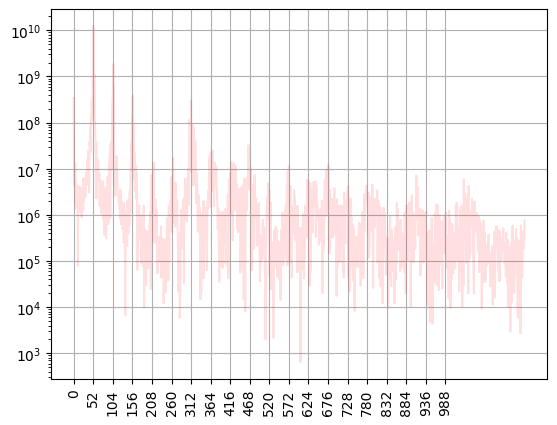

52
harmonic_areas: [np.float64(20386890847.61404), np.float64(3646567819.4810195), np.float64(860696465.5710205), np.float64(40291568.77693441), np.float64(60801510.77037956), np.float64(954046213.8506243), np.float64(151030322.7229802), np.float64(74912329.52898733), np.float64(137508321.6983083), np.float64(22378042.731475417)]
52
harmonic_areas: [np.float64(385196457.8483715), np.float64(109542296.4676243), np.float64(33582198.22814032), np.float64(7161814.776075762), np.float64(1131938.1273043484), np.float64(1866662.00870191), np.float64(960816.0816743752), np.float64(1208764.8231179565), np.float64(218071.22295068903), np.float64(202533.00141560164)]



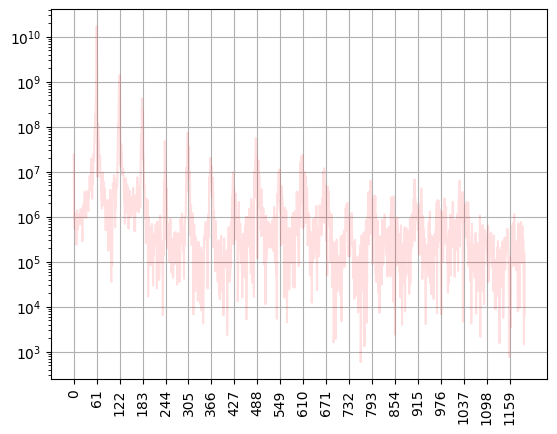

61
harmonic_areas: [np.float64(22416326930.37203), np.float64(4424870242.5929365), np.float64(1281389517.5181627), np.float64(102476971.38374493), np.float64(209496658.28863642), np.float64(103884150.09088647), np.float64(42250429.33164911), np.float64(249474948.84642464), np.float64(58134781.28999535), np.float64(145357917.4779845)]
61
harmonic_areas: [np.float64(389836864.60456145), np.float64(88252563.60546486), np.float64(65251621.140131086), np.float64(10015653.538319707), np.float64(137821.4079220827), np.float64(609684.7684938028), np.float64(145696.31198011874), np.float64(1189902.1521161352), np.float64(134764.16306450588), np.float64(237987.77326934395)]



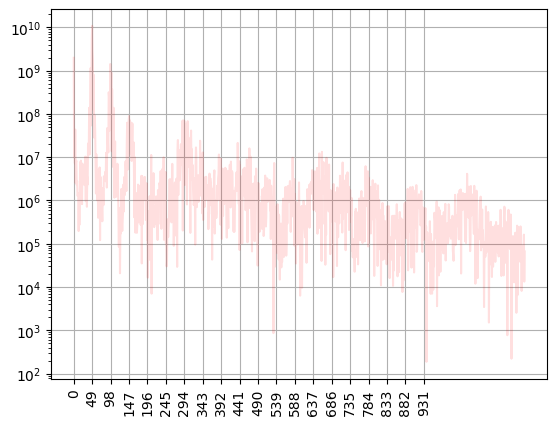

49
harmonic_areas: [np.float64(24383127343.298187), np.float64(4103217675.83455), np.float64(662207132.3371447), np.float64(21602519.10966431), np.float64(34194812.99995487), np.float64(519779273.2913036), np.float64(95844831.61124627), np.float64(63552398.42302138), np.float64(75945598.41986875), np.float64(24620649.67104414)]
49
harmonic_areas: [np.float64(360419557.4172421), np.float64(131330973.75193904), np.float64(23582861.9795376), np.float64(9584062.485119915), np.float64(756584.0601783016), np.float64(1542398.7598725257), np.float64(390873.79634511867), np.float64(322317.58252780826), np.float64(513161.68022268644), np.float64(101931.20829833577)]



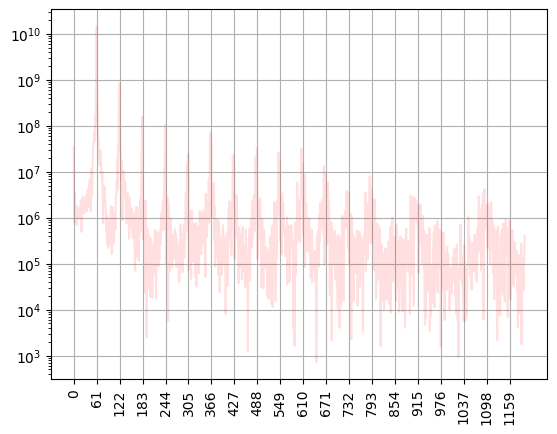

61
harmonic_areas: [np.float64(19270368866.92663), np.float64(2285342652.456509), np.float64(263761281.5971238), np.float64(192652387.5504765), np.float64(86925718.00189804), np.float64(284728368.4297881), np.float64(92478723.06353295), np.float64(112115592.92019176), np.float64(80056580.37285343), np.float64(97925772.18804675)]
61
harmonic_areas: [np.float64(400531574.17123944), np.float64(87439983.47994132), np.float64(53110436.43196748), np.float64(9822521.423562132), np.float64(337374.02604615805), np.float64(1042455.3720330879), np.float64(146141.5333317906), np.float64(898410.897892911), np.float64(362050.78223775694), np.float64(197782.94412973995)]



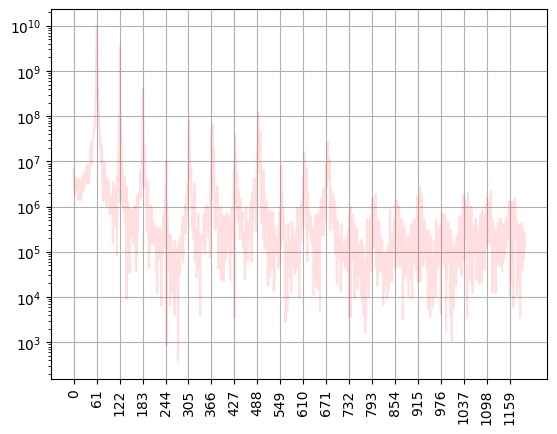

61
harmonic_areas: [np.float64(22046645849.949753), np.float64(3782386327.569411), np.float64(905923022.696723), np.float64(20028683.16367146), np.float64(213171986.05364332), np.float64(178712798.2152718), np.float64(106143780.16014795), np.float64(326182562.07378054), np.float64(17774028.23962017), np.float64(45871488.71067448)]
61
harmonic_areas: [np.float64(415391099.139205), np.float64(89164740.40453105), np.float64(61628028.98401306), np.float64(7643056.196534419), np.float64(88381.20531614989), np.float64(981278.1263682349), np.float64(215939.48881627666), np.float64(1363911.2221018057), np.float64(62082.36346184707), np.float64(80863.85950924188)]



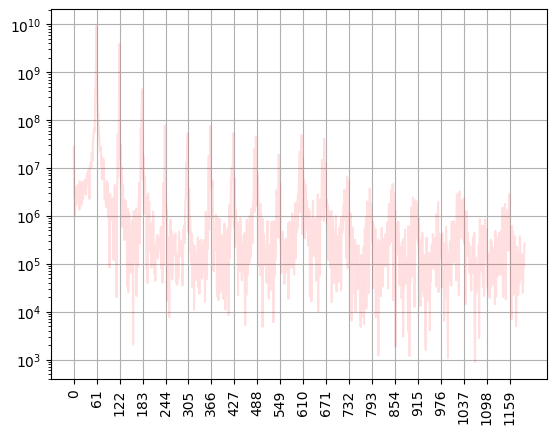

60
harmonic_areas: [np.float64(22437030126.34671), np.float64(4228980808.1845884), np.float64(1112420042.3877332), np.float64(108769961.64697145), np.float64(130967404.52537863), np.float64(171637894.92997134), np.float64(118785460.02047777), np.float64(159202055.6692014), np.float64(44269237.90325726), np.float64(179692895.37825194)]
61
harmonic_areas: [np.float64(387080040.54891664), np.float64(87901525.88252625), np.float64(64772621.46173978), np.float64(9990262.5004735), np.float64(218369.16353290004), np.float64(801494.268482137), np.float64(296453.63055132166), np.float64(1077031.2224528284), np.float64(136843.47015348374), np.float64(325198.0410591313)]



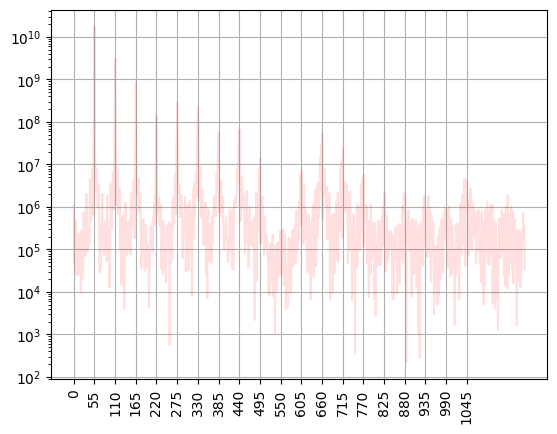

55
harmonic_areas: [np.float64(18147273152.452087), np.float64(3315451962.8132024), np.float64(1023837799.3286282), np.float64(203092130.99956048), np.float64(440343954.6596068), np.float64(461992908.6054209), np.float64(177989385.26815492), np.float64(226735907.70899674), np.float64(52773048.720886685), np.float64(1890753.0798825703)]
55
harmonic_areas: [np.float64(425376951.61435956), np.float64(102459909.42308109), np.float64(42348048.35951771), np.float64(3005602.8853414916), np.float64(2783461.9722747942), np.float64(1245809.8790159617), np.float64(661817.2582967316), np.float64(1565073.2215743982), np.float64(362885.09482193494), np.float64(142256.04013254686)]



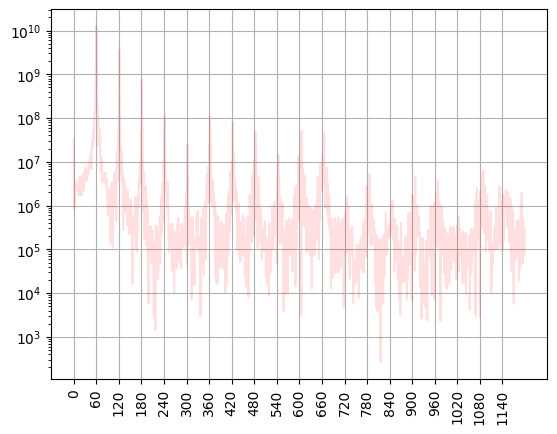

60
harmonic_areas: [np.float64(21882607092.84784), np.float64(4170349686.6813693), np.float64(954928483.1249723), np.float64(217874167.41219568), np.float64(38261874.294042945), np.float64(293993160.72553414), np.float64(157126999.36642134), np.float64(132068291.20998263), np.float64(52963209.6648774), np.float64(169642548.84115994)]
60
harmonic_areas: [np.float64(375818061.0117203), np.float64(89127581.79641008), np.float64(62010550.69667844), np.float64(12484048.228443457), np.float64(508143.72689570475), np.float64(901323.9751173905), np.float64(217968.99761693514), np.float64(993209.0606158392), np.float64(293272.9092559755), np.float64(287653.85283887375)]



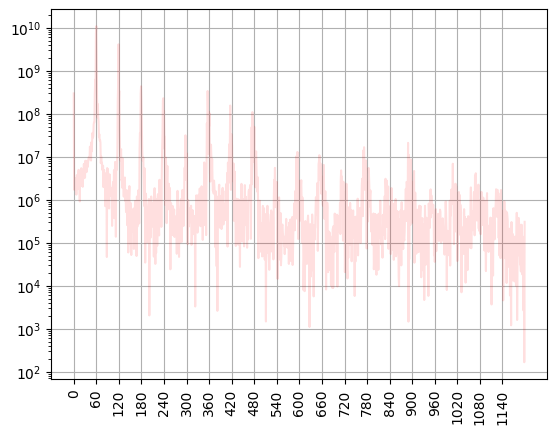

60
harmonic_areas: [np.float64(23010526307.899635), np.float64(5501825001.433685), np.float64(1142967557.4114673), np.float64(717144467.9076395), np.float64(85416816.02015886), np.float64(887281042.1998417), np.float64(336823165.919319), np.float64(348853037.69540316), np.float64(22378123.51137943), np.float64(62222355.1298419)]
60
harmonic_areas: [np.float64(372530211.6820179), np.float64(90836832.15612936), np.float64(60431362.843051985), np.float64(15640532.588197064), np.float64(1049370.6837026502), np.float64(1992676.027843109), np.float64(241566.4671447186), np.float64(1471970.1470393387), np.float64(230013.31600667996), np.float64(132912.03567494682)]



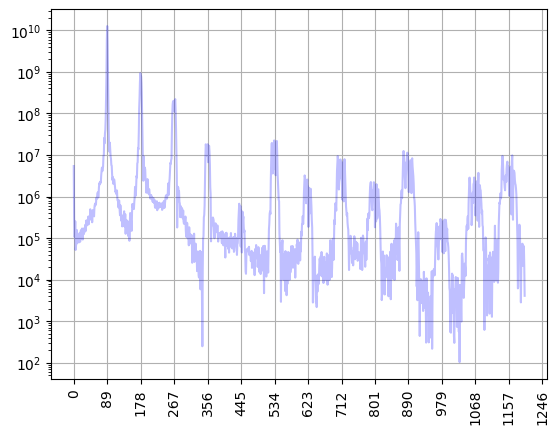

89
harmonic_areas: [np.float64(26678968231.77409), np.float64(4015903412.390094), np.float64(1838400572.8360555), np.float64(168783280.67651993), np.float64(6364562.022452891), np.float64(225640475.73143747), np.float64(32149665.35454819), np.float64(106710572.37280236), np.float64(32958696.10259782), np.float64(170523113.82084474)]
89
harmonic_areas: [np.float64(369198982.797869), np.float64(76049136.19294804), np.float64(56102334.67299118), np.float64(6189868.960912386), np.float64(589355.5932230183), np.float64(928182.3984877443), np.float64(103357.99700775919), np.float64(844517.2235020568), np.float64(341846.35954513), np.float64(272795.0012591609)]



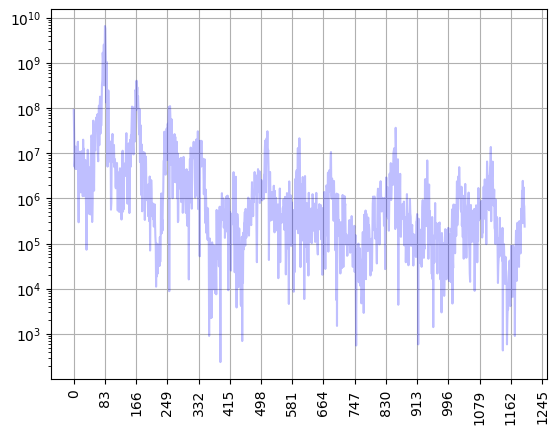

83
harmonic_areas: [np.float64(24859052576.76168), np.float64(2636173085.0976596), np.float64(697418421.3818231), np.float64(290791519.5756664), np.float64(22917155.087997314), np.float64(127749002.1887663), np.float64(38545997.18059094), np.float64(26282992.86628419), np.float64(3615138.468825368), np.float64(46045211.97665989)]
83
harmonic_areas: [np.float64(372263327.3463757), np.float64(77890365.58128789), np.float64(43879764.88153488), np.float64(7225778.913651013), np.float64(453291.76147803135), np.float64(648638.5684440186), np.float64(29951.23644508274), np.float64(198822.15184621117), np.float64(155247.6352834299), np.float64(80389.9200583159)]



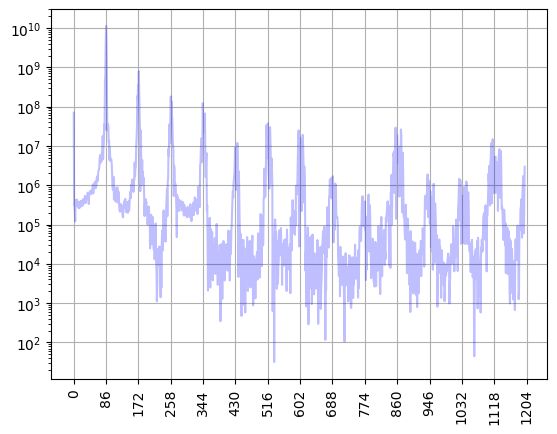

86
harmonic_areas: [np.float64(23232143548.853474), np.float64(2243870206.750645), np.float64(655880675.7732326), np.float64(468452040.3782169), np.float64(50076805.11905971), np.float64(208158737.95917055), np.float64(147755332.57295442), np.float64(16971225.659048527), np.float64(5477836.868015372), np.float64(225140018.08572146)]
86
harmonic_areas: [np.float64(382942426.65292174), np.float64(75382022.38870613), np.float64(49574677.27393652), np.float64(7342618.931925572), np.float64(846476.3981500102), np.float64(1046115.0685438954), np.float64(82603.13146626404), np.float64(361462.61134765664), np.float64(609247.7322634077), np.float64(343136.5125121297)]



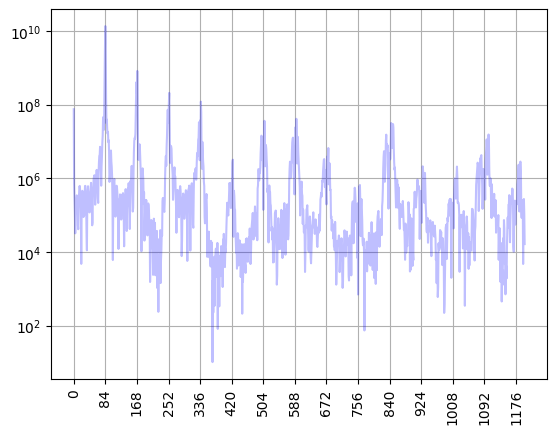

84
harmonic_areas: [np.float64(22895107043.398434), np.float64(2091380098.941486), np.float64(600940211.6031789), np.float64(362581853.9494811), np.float64(13363162.963959903), np.float64(190537025.33318648), np.float64(200244317.33939552), np.float64(43419358.76693936), np.float64(5647816.231123496), np.float64(264482048.62071764)]
84
harmonic_areas: [np.float64(410113676.11282426), np.float64(80656191.39775516), np.float64(51014268.560957365), np.float64(6218747.172470134), np.float64(545009.4100006275), np.float64(1098425.8032311415), np.float64(97470.15991629822), np.float64(546900.34029235), np.float64(301774.0256579221), np.float64(589773.4303856696)]



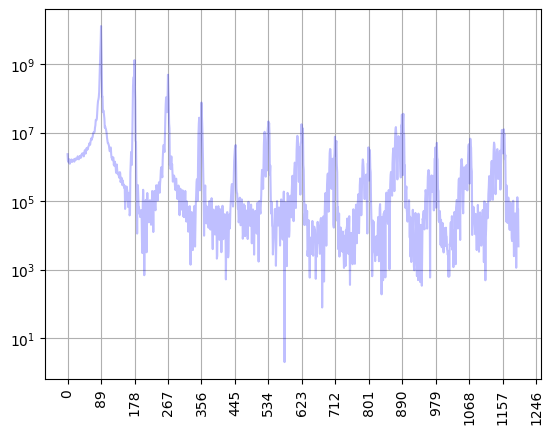

89
harmonic_areas: [np.float64(25783521828.540154), np.float64(2926966621.205419), np.float64(1292038673.3050907), np.float64(264173310.63672403), np.float64(20209450.12222725), np.float64(142828866.0077854), np.float64(109217409.01413363), np.float64(45582716.4886253), np.float64(23539627.07738144), np.float64(224438891.99293232)]
89
harmonic_areas: [np.float64(366875439.3099227), np.float64(76301273.12558217), np.float64(54647806.97654382), np.float64(6077899.103416317), np.float64(1093630.7624584343), np.float64(799502.6978799474), np.float64(31160.4420044098), np.float64(616279.7993947461), np.float64(379171.78240601975), np.float64(437781.4853139416)]



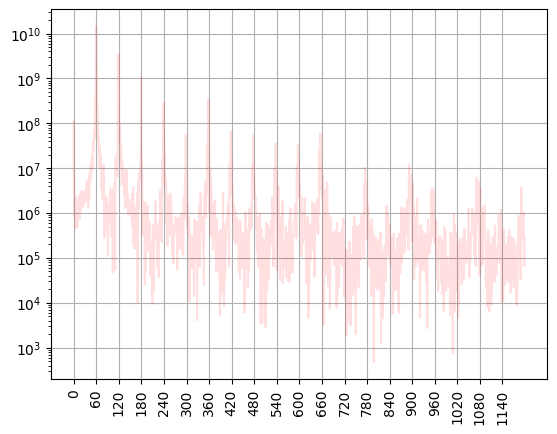

60
harmonic_areas: [np.float64(21837209939.631477), np.float64(5110892981.600953), np.float64(1200591404.3434627), np.float64(545401404.2069339), np.float64(96239333.68608312), np.float64(523919095.71310437), np.float64(203078430.09436125), np.float64(116678420.9166179), np.float64(87855805.29792729), np.float64(123245204.36971757)]
60
harmonic_areas: [np.float64(379029553.33855784), np.float64(89954894.28210984), np.float64(61248045.02404679), np.float64(14444086.083934747), np.float64(567619.6358494698), np.float64(1460764.2300052082), np.float64(249819.9492314049), np.float64(907935.660786304), np.float64(332563.18725006236), np.float64(204006.1855480387)]



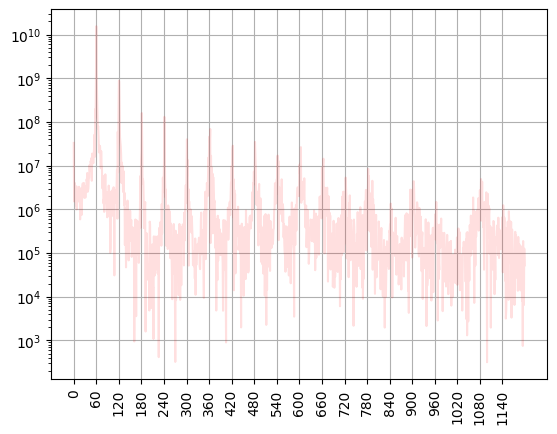

60
harmonic_areas: [np.float64(19325630714.1396), np.float64(2319862477.7606907), np.float64(255660975.0990808), np.float64(192215120.23919904), np.float64(86091760.74142496), np.float64(270371466.7747354), np.float64(94154057.96613307), np.float64(103266794.24157807), np.float64(72502331.27105846), np.float64(96995103.83449888)]
60
harmonic_areas: [np.float64(394136746.5725697), np.float64(86915024.58451279), np.float64(54867891.94551276), np.float64(9960550.891854208), np.float64(424773.8565760748), np.float64(1138579.1849581036), np.float64(173697.06850150862), np.float64(846639.7003410037), np.float64(317579.7395402356), np.float64(195841.65053444222)]



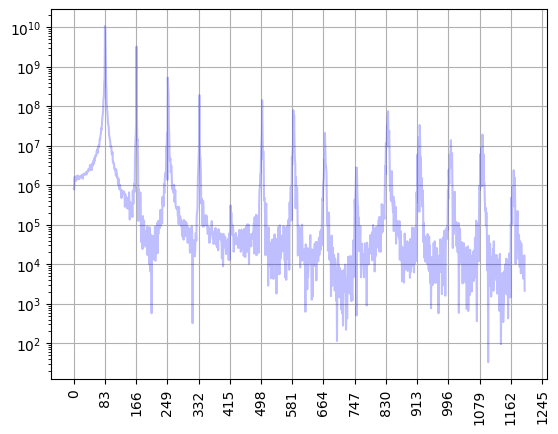

83
harmonic_areas: [np.float64(24181854739.399933), np.float64(3424784955.5668907), np.float64(1148637223.247752), np.float64(236503863.4304532), np.float64(2071222.983525241), np.float64(235676224.04378957), np.float64(206366194.0268975), np.float64(51758332.81703883), np.float64(9724626.43893731), np.float64(307158878.3904141)]
83
harmonic_areas: [np.float64(397364798.5078108), np.float64(83080524.84404606), np.float64(55836215.30078487), np.float64(7038170.342782612), np.float64(568118.1504453358), np.float64(1331088.6872719622), np.float64(78546.66394878762), np.float64(533535.8325365675), np.float64(395948.6287705242), np.float64(593297.3420354091)]



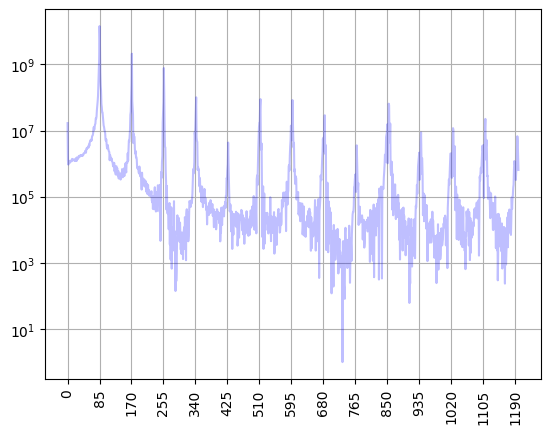

85
harmonic_areas: [np.float64(24310213491.639256), np.float64(2737292333.6025305), np.float64(1076465046.5061662), np.float64(198441698.68879092), np.float64(9183691.110371197), np.float64(215460095.70011866), np.float64(174339151.3400122), np.float64(79733212.37572505), np.float64(7939493.730652583), np.float64(217390754.48604977)]
85
harmonic_areas: [np.float64(406666059.9649921), np.float64(82436209.10516112), np.float64(54935682.30921614), np.float64(5163247.048923597), np.float64(464199.9804431462), np.float64(1184048.7066006265), np.float64(72815.83133670826), np.float64(730683.2867784193), np.float64(167805.57998132368), np.float64(611153.4129993271)]



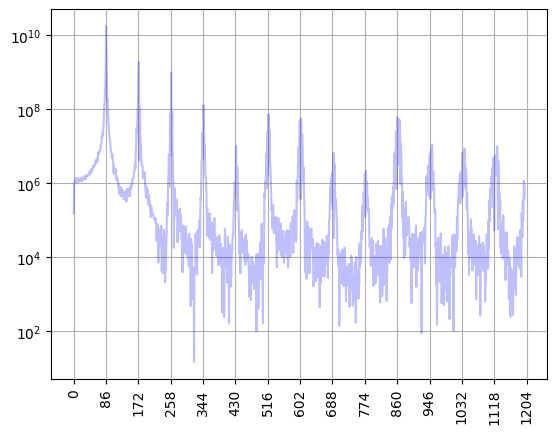

86
harmonic_areas: [np.float64(25501875492.17009), np.float64(3020554328.2440214), np.float64(1225360464.3184118), np.float64(263489348.96673086), np.float64(22517877.342322208), np.float64(168452362.81385735), np.float64(248601268.00452662), np.float64(22285753.09905657), np.float64(9634829.502852095), np.float64(363934515.42508465)]
86
harmonic_areas: [np.float64(397145420.2592026), np.float64(80770631.47675605), np.float64(55041706.03694204), np.float64(6050254.117417653), np.float64(853049.7466982519), np.float64(1046229.4713237281), np.float64(91904.82929697448), np.float64(583286.86775397), np.float64(316397.4904420849), np.float64(816738.1456478684)]



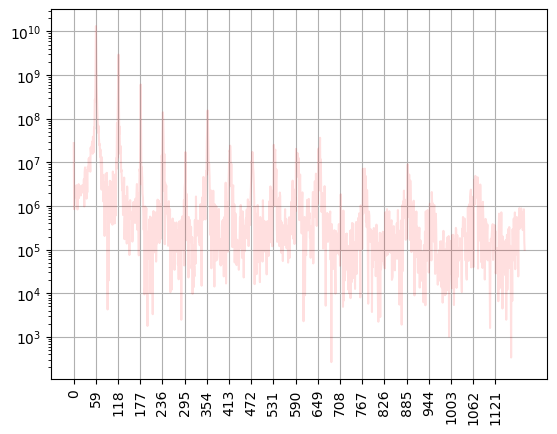

59
harmonic_areas: [np.float64(20513801865.02849), np.float64(4282348911.7572117), np.float64(771704513.6202587), np.float64(362942852.60453266), np.float64(35730467.37058279), np.float64(392002171.1618481), np.float64(125726669.9173675), np.float64(86544965.21451628), np.float64(114609531.16821757), np.float64(116950729.63319823)]
59
harmonic_areas: [np.float64(371333276.3335848), np.float64(90708592.34258947), np.float64(58952587.84163527), np.float64(14767734.492239017), np.float64(798318.9059709271), np.float64(1232742.5250578432), np.float64(142375.02355480392), np.float64(867668.2969984845), np.float64(381205.37796979933), np.float64(195689.35899832903)]



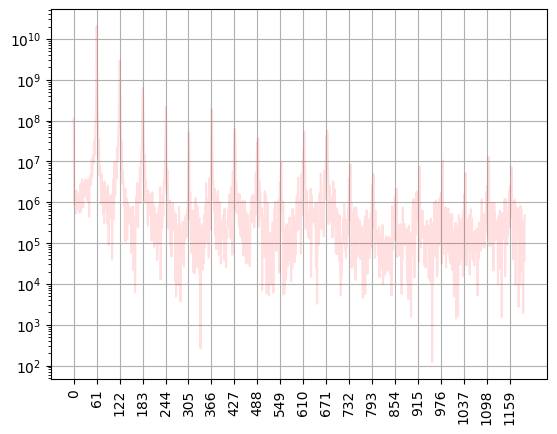

61
harmonic_areas: [np.float64(23579002517.108208), np.float64(5030046650.570647), np.float64(1345754381.6344836), np.float64(338925645.4795599), np.float64(87059684.61853816), np.float64(388071939.317804), np.float64(243771577.33318081), np.float64(164735226.7201569), np.float64(31260138.640779506), np.float64(150412374.7499824)]
61
harmonic_areas: [np.float64(383881608.46468633), np.float64(89315998.81445912), np.float64(64854006.42584668), np.float64(12634908.264843358), np.float64(593785.4530817699), np.float64(1325738.8300191807), np.float64(331677.95236259146), np.float64(1083749.7267574216), np.float64(196641.3551966256), np.float64(272212.0129436584)]



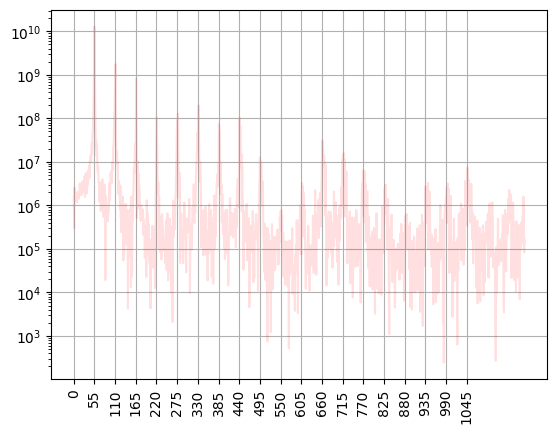

55
harmonic_areas: [np.float64(18044891760.545795), np.float64(3156008945.6588364), np.float64(1002008932.5842429), np.float64(173501067.1070986), np.float64(407785872.9583834), np.float64(491722174.32398874), np.float64(241458642.92306834), np.float64(316855909.0576344), np.float64(63227511.56405012), np.float64(6022278.703015268)]
55
harmonic_areas: [np.float64(410397430.6356214), np.float64(98368700.6562708), np.float64(42181220.16421714), np.float64(3450831.213181814), np.float64(2830664.641923458), np.float64(1009891.5479219994), np.float64(836366.2229995182), np.float64(1895549.6994406676), np.float64(505200.2584819978), np.float64(226253.01044015898)]



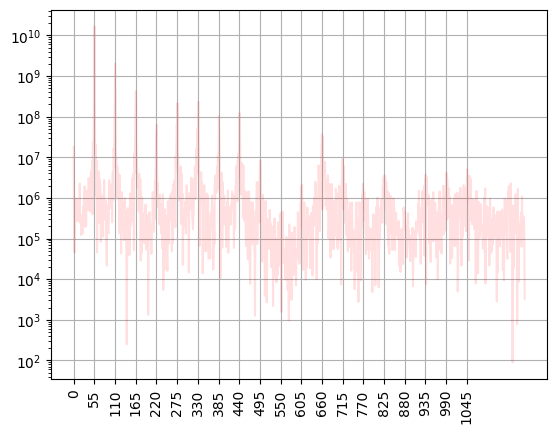

55
harmonic_areas: [np.float64(17945345416.90435), np.float64(2686578545.339009), np.float64(920682758.5825516), np.float64(157588072.18647873), np.float64(397462318.6408052), np.float64(392149607.0586452), np.float64(186499368.04759037), np.float64(277194641.0213396), np.float64(36733887.099293076), np.float64(2889529.796400636)]
55
harmonic_areas: [np.float64(425323552.57901704), np.float64(97884180.8819632), np.float64(40143647.56314536), np.float64(2640703.780229113), np.float64(3043951.633472687), np.float64(852884.9471984274), np.float64(653682.2903389058), np.float64(1636711.6727372557), np.float64(404802.4990287125), np.float64(200294.5342123775)]



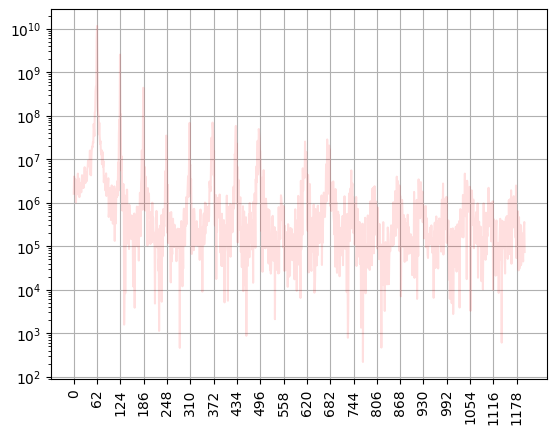

62
harmonic_areas: [np.float64(21452617880.95171), np.float64(2980979021.7817297), np.float64(634797229.0563309), np.float64(79182203.50739516), np.float64(122277220.34276636), np.float64(264418645.55436626), np.float64(169253912.26449126), np.float64(235051061.94164217), np.float64(9251128.92161629), np.float64(100331792.38812491)]
62
harmonic_areas: [np.float64(402651267.34281474), np.float64(85859877.33037826), np.float64(61936488.14815019), np.float64(7958961.315941078), np.float64(194447.2115499252), np.float64(1078207.6628766558), np.float64(323286.181841816), np.float64(1273511.1169632864), np.float64(74398.31639056196), np.float64(221574.17956810794)]



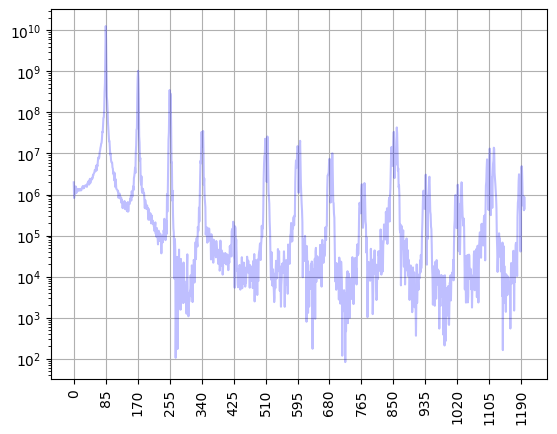

85
harmonic_areas: [np.float64(24747304669.667957), np.float64(3053577095.4951167), np.float64(1251207282.3732703), np.float64(181195482.21752605), np.float64(1989033.6252078493), np.float64(160395588.38865602), np.float64(130098891.7558833), np.float64(73349712.16518335), np.float64(13287104.783268522), np.float64(286525497.8796287)]
85
harmonic_areas: [np.float64(395355461.1429252), np.float64(81893530.08241098), np.float64(55749660.37198311), np.float64(5830977.304002852), np.float64(550534.5038753606), np.float64(925438.543571682), np.float64(31492.574368013407), np.float64(710647.8511736302), np.float64(257305.244878854), np.float64(631862.9738184046)]



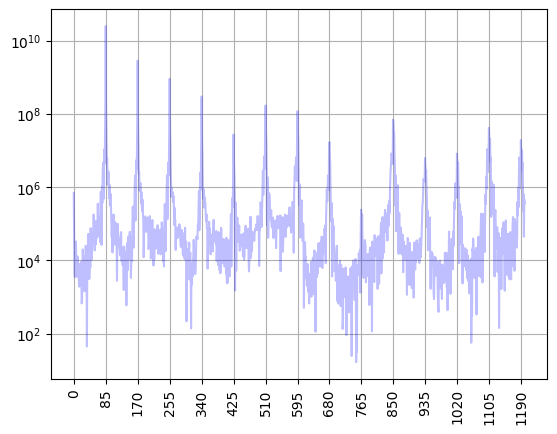

85
harmonic_areas: [np.float64(25136398078.602505), np.float64(3022014636.7730665), np.float64(1048025274.0019394), np.float64(379156361.8988317), np.float64(44083097.294188455), np.float64(319848835.2884277), np.float64(260468493.1105379), np.float64(50238854.06950722), np.float64(1012956.9072751955), np.float64(243874336.39651328)]
85
harmonic_areas: [np.float64(385691029.4863433), np.float64(80967156.85041328), np.float64(55815265.05244242), np.float64(7543718.126664049), np.float64(1029274.0446580106), np.float64(1358456.0500546258), np.float64(49929.53133083123), np.float64(518418.04951565975), np.float64(367055.68690688576), np.float64(582940.960129117)]



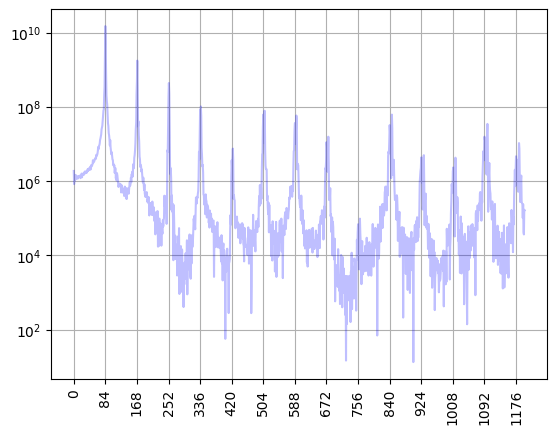

84
harmonic_areas: [np.float64(24787955390.83987), np.float64(3056242647.540006), np.float64(953620877.3337697), np.float64(358604096.639153), np.float64(25497648.43005822), np.float64(346719820.067129), np.float64(269109638.1929252), np.float64(61165669.22107484), np.float64(523515.032841973), np.float64(233717416.15719348)]
84
harmonic_areas: [np.float64(403739946.1449115), np.float64(81670856.29748929), np.float64(53115887.07663732), np.float64(6712891.628374948), np.float64(653196.1820582267), np.float64(1570278.3405108715), np.float64(93315.93109903396), np.float64(538689.7885680251), np.float64(315144.94063522527), np.float64(499505.72602870537)]



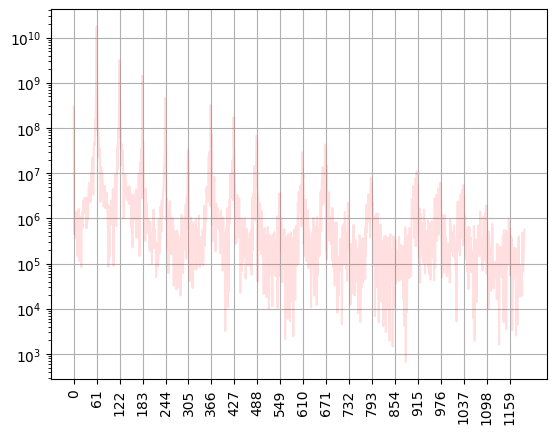

61
harmonic_areas: [np.float64(24363015175.09723), np.float64(5902096386.131456), np.float64(1683798916.4640646), np.float64(627638863.5444715), np.float64(98244974.3298985), np.float64(623848616.7127028), np.float64(335970559.85388184), np.float64(253092472.00520507), np.float64(17916984.05544535), np.float64(107380131.54835166)]
61
harmonic_areas: [np.float64(371835771.87530446), np.float64(90431695.87541941), np.float64(65131281.946363695), np.float64(14592852.492666379), np.float64(868219.998511981), np.float64(1549752.981822275), np.float64(264270.0814397349), np.float64(1261439.8225671176), np.float64(203926.7100882926), np.float64(202467.13544609954)]



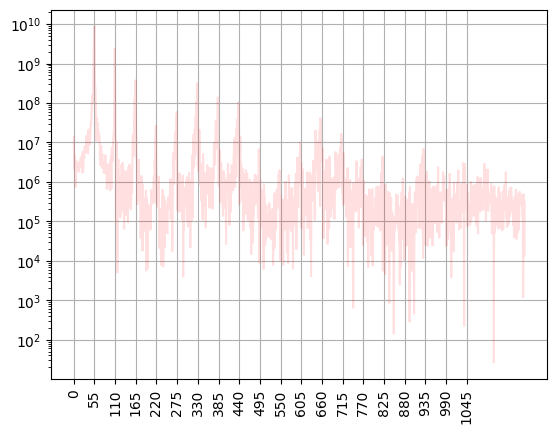

55
harmonic_areas: [np.float64(18363958744.935097), np.float64(3066027154.1160073), np.float64(846599932.0552738), np.float64(82393638.5755221), np.float64(183819700.79987764), np.float64(715181800.204595), np.float64(320134004.3062545), np.float64(348434333.44489765), np.float64(17547727.706814926), np.float64(8532170.32753266)]
55
harmonic_areas: [np.float64(413621397.31309557), np.float64(98458184.13216941), np.float64(37313563.46732397), np.float64(3638463.2936901534), np.float64(2494944.644873014), np.float64(807201.5047674852), np.float64(457571.37925917207), np.float64(1692215.936327238), np.float64(169368.5143888618), np.float64(168734.89278409988)]



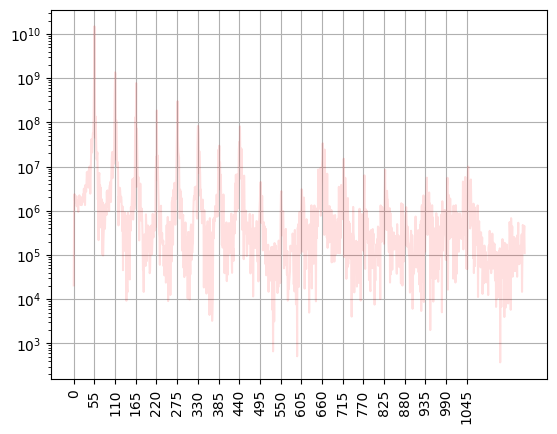

55
harmonic_areas: [np.float64(18237987633.37335), np.float64(3434351991.7989044), np.float64(1156223840.6068635), np.float64(254244819.74658605), np.float64(549689935.5767443), np.float64(322238111.45880944), np.float64(113033536.68131338), np.float64(269662134.9922963), np.float64(19780752.1460503), np.float64(10408734.347778969)]
55
harmonic_areas: [np.float64(412549935.65902114), np.float64(101426139.44202304), np.float64(42804388.61369923), np.float64(3267799.0667698923), np.float64(3091115.0239136866), np.float64(1069206.4757485483), np.float64(583815.0130053358), np.float64(1549610.501685684), np.float64(224676.1453769719), np.float64(257249.91587437107)]



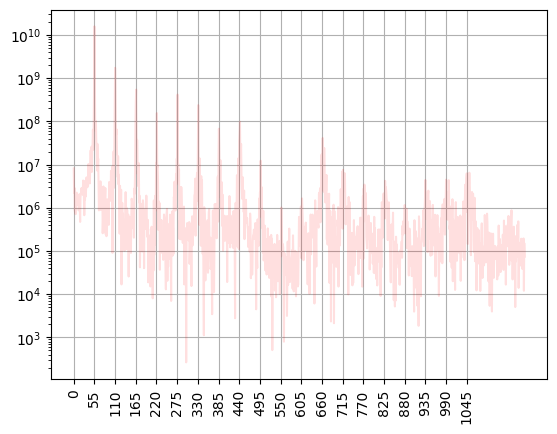

55
harmonic_areas: [np.float64(17920109059.000164), np.float64(2949793593.17498), np.float64(1048198677.3568261), np.float64(208552255.95359832), np.float64(491577616.87794006), np.float64(327199369.6907895), np.float64(148714575.74859962), np.float64(294992265.04669285), np.float64(28984329.918405335), np.float64(3154001.027762731)]
55
harmonic_areas: [np.float64(414880927.8027809), np.float64(99034422.09870018), np.float64(42723078.38526497), np.float64(2962282.531004728), np.float64(3334582.392903902), np.float64(895034.2251678875), np.float64(663327.8791283912), np.float64(1580174.4625500664), np.float64(366014.8895341383), np.float64(220010.09567887642)]



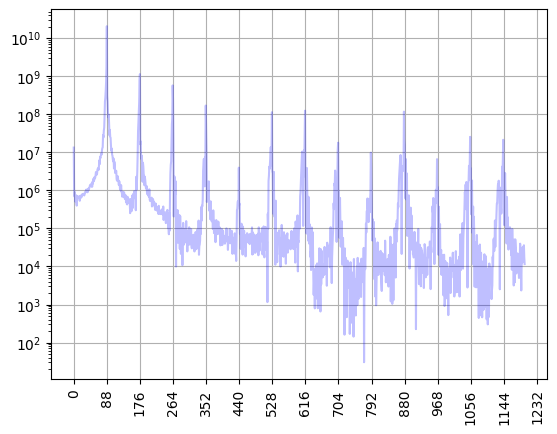

88
harmonic_areas: [np.float64(25220166364.347805), np.float64(2461594593.8045077), np.float64(1018429080.4783145), np.float64(267364518.49989316), np.float64(8367552.545023347), np.float64(180595698.13992983), np.float64(215508839.81545714), np.float64(46761904.70828419), np.float64(21303747.186474424), np.float64(221404114.61402464)]
88
harmonic_areas: [np.float64(414350955.5858881), np.float64(79771516.89636281), np.float64(52624093.634973526), np.float64(4316501.36150995), np.float64(565126.2664513893), np.float64(1031578.3893732922), np.float64(96126.97464121948), np.float64(702795.1876071077), np.float64(115822.2688238602), np.float64(693326.0974093028)]



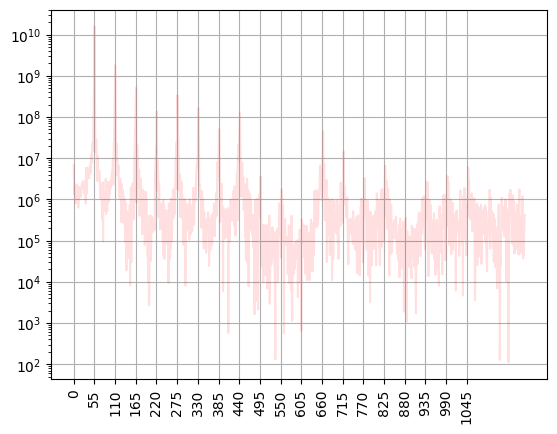

55
harmonic_areas: [np.float64(18150934472.394955), np.float64(3048748501.391411), np.float64(1045523476.7337538), np.float64(210580856.92569143), np.float64(517668929.92022943), np.float64(306926128.2153588), np.float64(148113328.93039566), np.float64(313761162.50197136), np.float64(12683500.833243893), np.float64(9671449.141778165)]
55
harmonic_areas: [np.float64(417964025.4512158), np.float64(96631623.31642307), np.float64(41483742.56049115), np.float64(2548727.677069818), np.float64(3360145.5977320266), np.float64(905398.964568952), np.float64(613997.3013324036), np.float64(1595561.3147724583), np.float64(250674.17140801373), np.float64(238611.7836592027)]



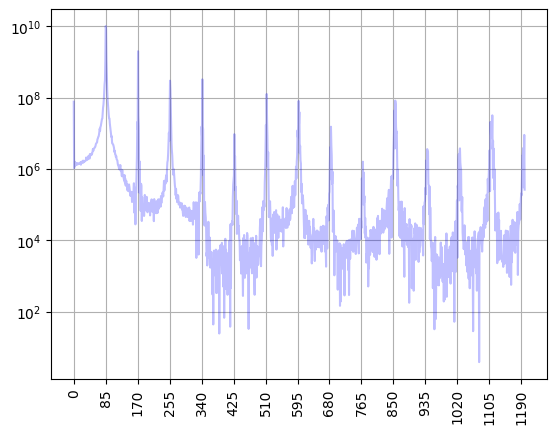

85
harmonic_areas: [np.float64(22855066248.14867), np.float64(2095190372.9732177), np.float64(634794683.5450153), np.float64(387786519.6833489), np.float64(16225971.895081641), np.float64(190597273.2289975), np.float64(200655745.22457528), np.float64(30659253.30542348), np.float64(4448114.900904553), np.float64(267416373.42876762)]
85
harmonic_areas: [np.float64(403688980.0627969), np.float64(79256308.18383346), np.float64(50530588.68772595), np.float64(6122531.9717535535), np.float64(667647.0194362607), np.float64(1158571.384155343), np.float64(90025.89269653661), np.float64(558231.3047356297), np.float64(319928.85250817257), np.float64(607679.9035438675)]



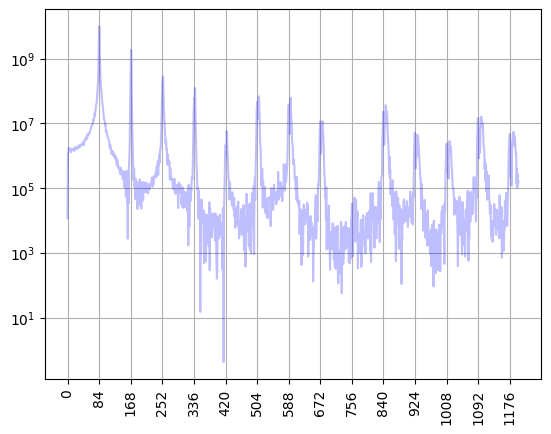

84
harmonic_areas: [np.float64(24465489492.09337), np.float64(3093392864.7803683), np.float64(979359518.7093098), np.float64(329264901.4835805), np.float64(20526912.47239977), np.float64(351299087.4706196), np.float64(277616480.8904771), np.float64(76121792.5077471), np.float64(385863.5804743742), np.float64(238561943.28315625)]
84
harmonic_areas: [np.float64(401230189.3853703), np.float64(82607600.99750741), np.float64(54395884.43947005), np.float64(6920988.083027366), np.float64(781299.1837537676), np.float64(1791210.9292174205), np.float64(122645.86407387031), np.float64(639633.982837538), np.float64(274043.2849586964), np.float64(603841.0643504171)]



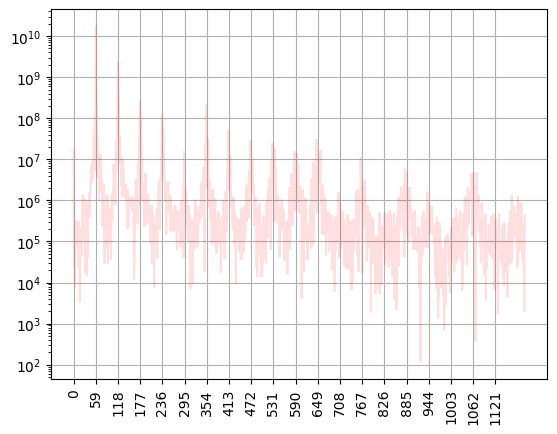

59
harmonic_areas: [np.float64(20553705374.262676), np.float64(4388080381.10932), np.float64(727972328.5327849), np.float64(390885395.30636877), np.float64(34625305.50332735), np.float64(398158328.29994684), np.float64(115684966.17126502), np.float64(86692450.32483622), np.float64(121821467.08622342), np.float64(108320789.43122765)]
59
harmonic_areas: [np.float64(372768467.2440718), np.float64(90475244.18947577), np.float64(58401441.08931312), np.float64(15162930.77105361), np.float64(729036.0529244391), np.float64(1276674.768383374), np.float64(112346.20832118118), np.float64(838847.4473641745), np.float64(409660.256028752), np.float64(167608.96504408846)]



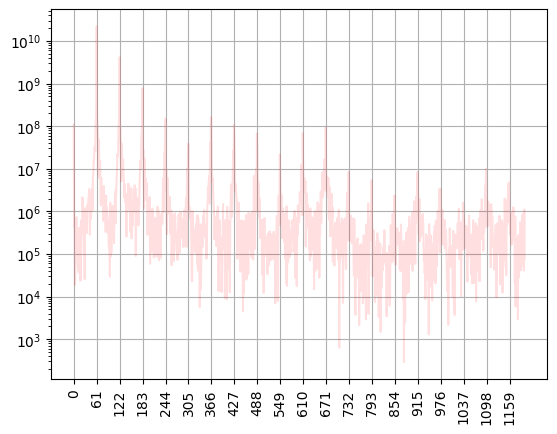

61
harmonic_areas: [np.float64(23459787555.87702), np.float64(5049749400.327227), np.float64(1262417193.1554656), np.float64(327410372.8046163), np.float64(110443030.32415667), np.float64(412981358.4039128), np.float64(249437608.01259097), np.float64(156188283.41765958), np.float64(50087779.42976229), np.float64(152837924.1974985)]
61
harmonic_areas: [np.float64(392698926.17714846), np.float64(89892703.87330376), np.float64(64172620.62441273), np.float64(11562986.422133682), np.float64(310118.9930173653), np.float64(1355449.162227144), np.float64(385802.3037905645), np.float64(1071764.6133705273), np.float64(185814.47599354287), np.float64(276991.7991646781)]



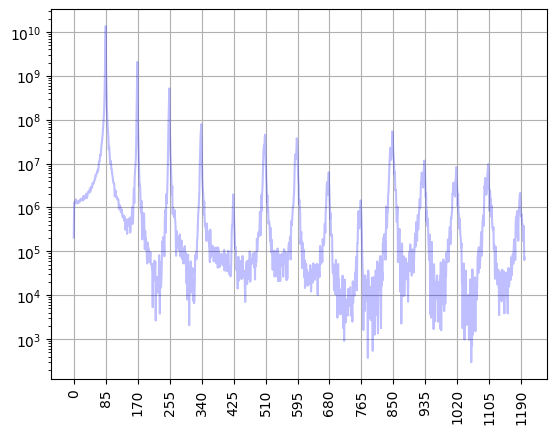

85
harmonic_areas: [np.float64(24402959311.478104), np.float64(3394468539.3123655), np.float64(1227156545.769987), np.float64(268556643.78028), np.float64(7884610.667926252), np.float64(228493354.3622994), np.float64(196559635.34060758), np.float64(37522952.743052706), np.float64(8208915.675459272), np.float64(317673298.23404104)]
85
harmonic_areas: [np.float64(390573856.4374025), np.float64(82692886.59313595), np.float64(56626741.76712052), np.float64(7581538.376892829), np.float64(758505.6085541154), np.float64(1424172.144356059), np.float64(52160.58298114929), np.float64(571731.8420864036), np.float64(456232.40063174715), np.float64(682455.6860452305)]



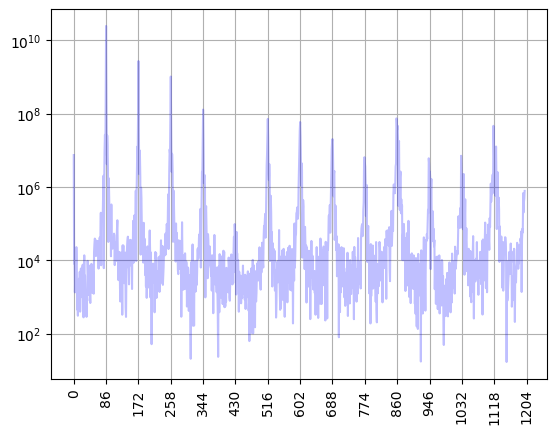

86
harmonic_areas: [np.float64(25172007673.919777), np.float64(2942197016.625202), np.float64(1217596818.317881), np.float64(178975678.749482), np.float64(455380.46261059167), np.float64(144246271.13053012), np.float64(155592705.26970616), np.float64(75000010.41463411), np.float64(24631303.854709312), np.float64(298476510.8241129)]
86
harmonic_areas: [np.float64(404210527.9147171), np.float64(82339724.25720109), np.float64(56221278.83076854), np.float64(5440568.627557675), np.float64(565374.0862814381), np.float64(905120.6858271915), np.float64(30054.198424683433), np.float64(767438.2734246732), np.float64(189524.06352499552), np.float64(723380.2628418362)]



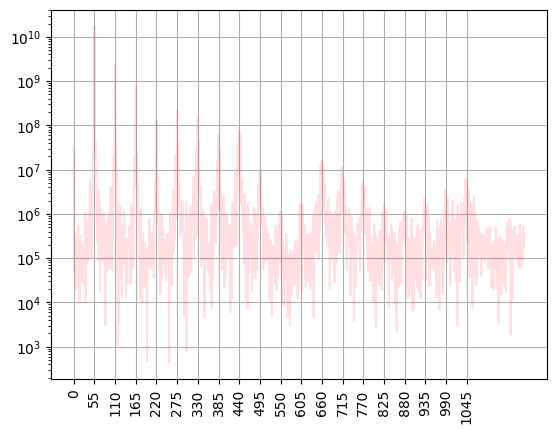

55
harmonic_areas: [np.float64(17744194432.108276), np.float64(2616047923.8616624), np.float64(976634763.8658317), np.float64(191672106.51423326), np.float64(422328638.9730903), np.float64(384104612.318863), np.float64(210711767.31969932), np.float64(343291149.74062824), np.float64(50642068.3935105), np.float64(8042808.275293804)]
55
harmonic_areas: [np.float64(427415816.0553954), np.float64(98510956.07901672), np.float64(40114063.8944364), np.float64(2489604.089583936), np.float64(3337253.6403036257), np.float64(711043.3878321232), np.float64(598305.1040109774), np.float64(1744774.7358153341), np.float64(460847.5202728019), np.float64(219644.6907418736)]



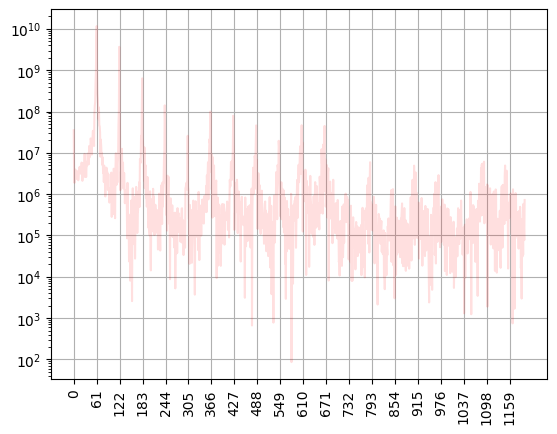

61
harmonic_areas: [np.float64(21785639940.25335), np.float64(4157391531.7185674), np.float64(891015364.111653), np.float64(221188382.4109792), np.float64(41748340.682876065), np.float64(300559920.59865123), np.float64(161097007.5131816), np.float64(116644036.05689573), np.float64(64143956.6433655), np.float64(163271047.43919232)]
61
harmonic_areas: [np.float64(380684434.8698813), np.float64(87796202.41427223), np.float64(62372730.98787988), np.float64(11767706.546924252), np.float64(504287.41005430603), np.float64(1099611.0988333675), np.float64(257644.48223598982), np.float64(940076.8421803982), np.float64(244948.8490207815), np.float64(308714.39517422166)]



In [16]:
PSDs = []
CC_peaks_list = []
CV_peaks_list = []
for data_file in data_files[::]:
    if data_file.split('.')[0] not in excl_filenames:
        df_file = pd.read_csv(f'{data_dir+data_file}')
        df_file = df_file[(df_file["Cycle_Index"] >1) & (df_file["Cycle_Index"] < 103)]
        df_file = df_file.iloc[:nfft,:]
        data_file_prefix = data_file.split('.')[0]
        meta_data_file = data_file_prefix + '_Metadata.csv'
        schedule_version= pd.read_csv(data_dir+meta_data_file)["schedule_version"].values[0][-7:]
    
    
        df_file["CycleTime_hrs"] =  df_file["DateTime"]/3600
        dt = df_file["CycleTime_hrs"].diff().mean()
        
        dt_std = df_file["CycleTime_hrs"].diff().std()
    
        CC = df_file["Current"].values
        CC_FFT = fft(CC)
        CC_PSD = np.real(CC_FFT*np.conjugate(CC_FFT))
        maxfreq_index = CC_PSD[5:].argmax() + 5
        # CC_PSD = CC_PSD/CC_PSD[maxfreq_index]
        
        CV = df_file["Voltage"].values
        CV_FFT = fft(CV)
        CV_PSD = np.real(CV_FFT*np.conjugate(CV_FFT))
        maxfreq_index = CV_PSD[5:].argmax() + 5
        # CV_PSD = CV_PSD/CC_PSD[maxfreq_index]
        
        
        Freqs = fftfreq(n = CC_PSD.shape[0], 
                        d = dt
                       )
        alpha = 0.25
        if schedule_version == '7.00.13':
            color = 'blue'
        else:
            color = 'red'
            alpha /= 2

        pseudo_freq= range(0, maxfreq_index*20,maxfreq_index)
        plt.plot(CC_PSD[:1200], color = color, alpha = alpha)
        plt.xticks(range(0, maxfreq_index*20,maxfreq_index), rotation = 90)
        plt.grid()
        plt.semilogy()
        plt.show()
        
        CC_peaks_list.append(create_Peak_Areas_df(CC_PSD, dt, data_file,
                                                  harmonics = harmonics, 
                                                  peakhalfwidth = peakhalfwidth, 
                                                  feature_name = 'CC'))
        CV_peaks_list.append(create_Peak_Areas_df(CV_PSD, dt, data_file,
                                                  harmonics = harmonics, 
                                                  peakhalfwidth = peakhalfwidth, 
                                                  feature_name = 'CV'))

        PSDs.append([data_file_prefix, schedule_version, dt, dt_std, Freqs, CC_PSD, CV_PSD])
        print()

## 3. Visual inspection of PSD

Plot the PSD of the charging current and voltage waveforms for all batteries. The harmonic peaks are clearly visible. Batteries using protocol version '7.00.13' are highlighted in green for comparison.

### 3a. Charging current (CC) PSD

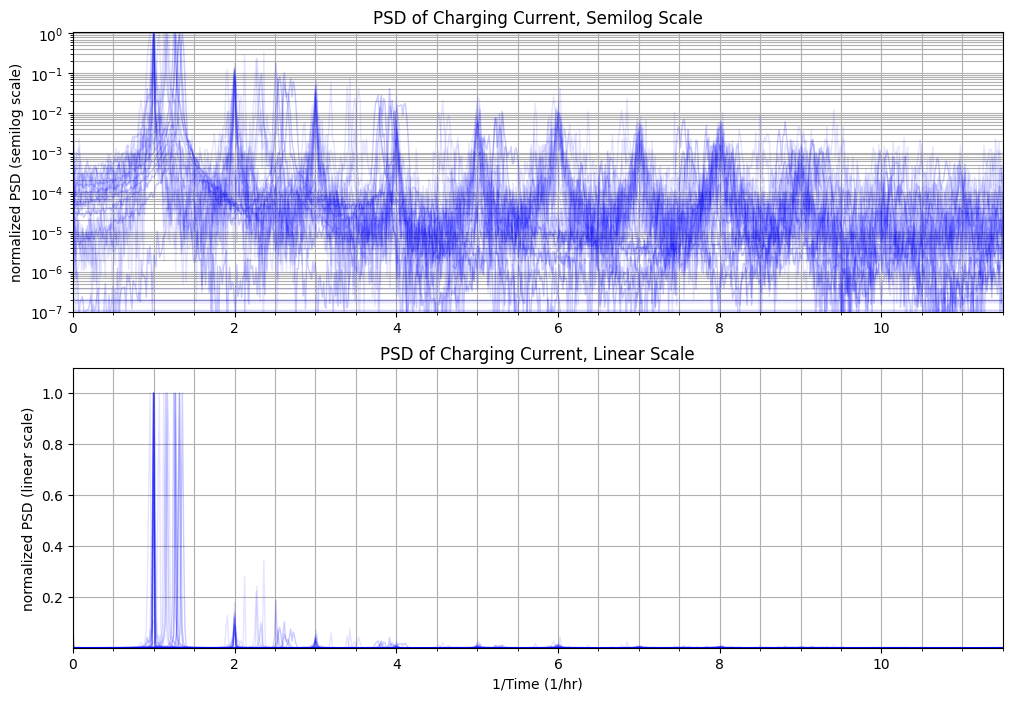

In [27]:
plt.figure(figsize = (12,8))
plt.subplot(2,1,1)
skip_step = 5
plt.title("PSD of Charging Current, Semilog Scale")
for PSD in PSDs[::skip_step]:
    filename_prefix = PSD[0]
    Freqs = PSD[-3]
    CC_PSD =PSD[-2]
    schedule_version = PSD[1]
    alpha = 0.2

    if schedule_version == '7.00.13':
        color = 'blue'
    else:
        color = 'red'
        alpha /= 2

    color = 'blue'
    plt.plot(Freqs, CC_PSD/CC_PSD[5:].max(), 
             label = schedule_version, color = color, 
             alpha = alpha, 
             linewidth = 1)

plt.semilogy()
plt.xlim(0,10)
plt.ylim(1e-7,1.1)
plt.xticks(np.arange(0,12,0.5), minor = True, fontsize = 0)
plt.grid( which = 'both')
plt.ylabel("normalized PSD (semilog scale)")


# plt.figure(figsize = (12,8))
plt.subplot(2,1,2)
plt.title("PSD of Charging Current, Linear Scale")
for PSD in PSDs[::skip_step]:
    filename_prefix = PSD[0]
    Freqs = PSD[-3]
    CC_PSD =PSD[-2]
    schedule_version = PSD[1]
    alpha = 0.2

    if schedule_version == '7.00.13':
        color = 'blue'
    else:
        color = 'red'
        alpha /= 2

    color = 'blue'
    plt.plot(Freqs, CC_PSD/CC_PSD[5:].max(), 
             label = schedule_version, color = color,
             alpha = alpha, 
             linewidth = 1)
# plt.legend()
plt.xlim(0,10)
plt.ylim(1e-7,1.1)
plt.xticks(np.arange(0,12,0.5), minor = True)
plt.grid( which = 'both')
plt.xlabel("1/Time (1/hr)")
plt.ylabel("normalized PSD (linear scale)")
plt.show()
# plt.savefig('figures/PSD_CC.png')

### 3b. Charging voltage (CV) PSD

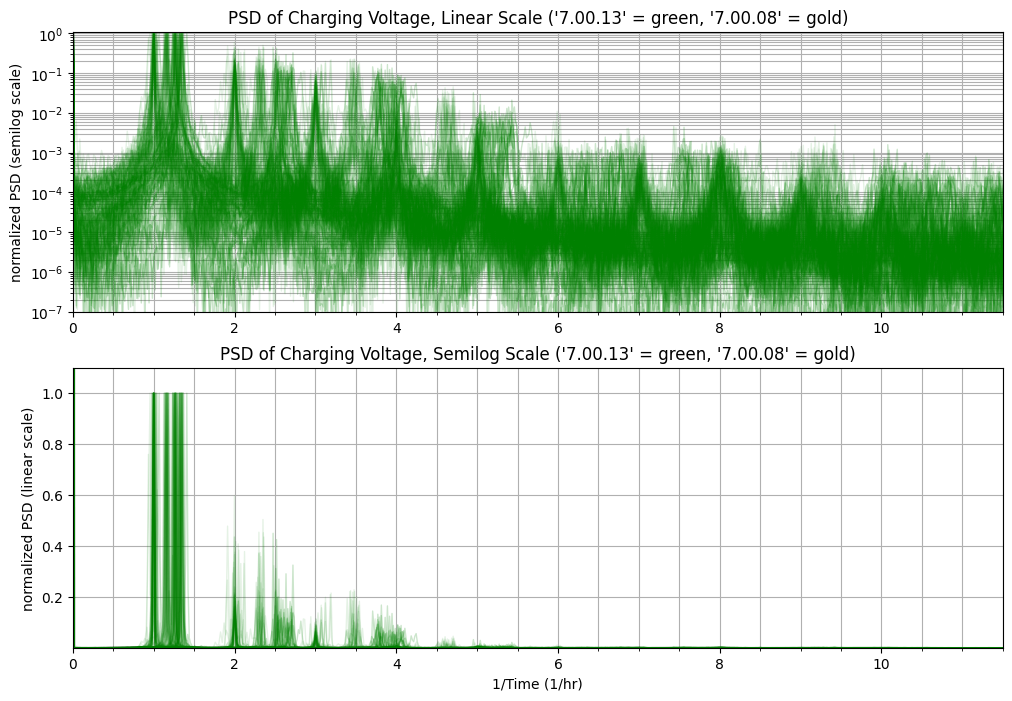

In [29]:
plt.figure(figsize = (12, 8))
plt.subplot(2,1,1)
plt.title("PSD of Charging Voltage, Linear Scale ('7.00.13' = green, '7.00.08' = gold)")
for PSD in PSDs[::]:
    filename_prefix = PSD[0]
    Freqs = PSD[-3]
    CV_PSD =PSD[-1]
    schedule_version = PSD[1]
    alpha = 0.2

    if schedule_version == '7.00.13':
        color = 'green'
    else:
        color = 'orange'
        alpha /= 2

    color = 'green'
    plt.plot(Freqs, CV_PSD/CV_PSD[5:].max(), 
             label = schedule_version, color = color, 
             alpha = alpha, 
             linewidth = 1)

# plt.legend()
plt.semilogy()
plt.xlim(0,10)
plt.ylim(1e-7,1.1)
plt.xticks(np.arange(0,12,0.5), minor = True, fontsize = 0)
plt.grid( which = 'both')
plt.ylabel("normalized PSD (semilog scale)")
# plt.show()


# plt.figure(figsize = (12, 8))
plt.subplot(2,1,2)
plt.title("PSD of Charging Voltage, Semilog Scale ('7.00.13' = green, '7.00.08' = gold)")
for PSD in PSDs[::]:
    filename_prefix = PSD[0]
    Freqs = PSD[-3]
    CV_PSD =PSD[-1]
    schedule_version = PSD[1]
    alpha = 0.2

    if schedule_version == '7.00.13':
        color = 'green'
    else:
        color = 'orange'
        alpha /= 2
    color = 'green'

    plt.plot(Freqs, CV_PSD/CV_PSD[5:].max(), 
             label = schedule_version, color = color,
             alpha = alpha, 
             linewidth = 1)
# plt.legend()
plt.xlim(0,10)
plt.ylim(1e-7,1.1)
plt.xticks(np.arange(0,12,0.5), minor = True)
plt.grid( which = 'both')
plt.xlabel("1/Time (1/hr)")
plt.ylabel("normalized PSD (linear scale)")
plt.show()
# plt.savefig('figures/PSD_CV.png')

## 4. Save PSD feature DataFrames to disk

Save the extracted CC and CV peak area DataFrames as compressed pickle files for use in the modeling notebooks (`battery_degradation_RFM_FFT.ipynb` and `battery_degradation_ML_GBM_FFT.ipynb`).

In [12]:
with gzip.open('../data/CC_data_frames_FFT_area.pckl', 'wb') as f:
    pickle.dump(CC_peaks_list, f)
with gzip.open('../data/CV_data_frames_FFT_area.pckl', 'wb') as f:
    pickle.dump(CV_peaks_list, f)

In [13]:
pd.concat(CC_peaks_list)

,fundfreqCC,01_harmonic_CCArea,02_harmonic_CCArea,03_harmonic_CCArea,04_harmonic_CCArea,05_harmonic_CCArea,06_harmonic_CCArea,07_harmonic_CCArea,08_harmonic_CCArea,09_harmonic_CCArea,10_harmonic_CCArea
2017-06-30_4_4C-55per_6C_CH19,1.007740,2.146686e+10,1.986781e+09,7.889595e+08,1.056026e+08,7.455525e+07,1.161858e+09,2.038321e+07,6.252829e+07,1.279937e+08,6.797818e+07
2018-04-12_batch8_CH38,1.310713,2.516462e+10,1.057476e+09,1.719271e+08,1.074681e+09,1.286299e+08,2.814308e+08,4.108356e+08,2.472246e+07,1.867605e+07,2.116049e+08
2018-04-12_batch8_CH10,1.305103,2.475228e+10,2.968219e+09,1.099281e+09,2.808950e+08,3.391777e+07,2.575261e+08,1.058837e+08,4.753373e+07,3.717520e+06,1.880803e+08
2017-05-12_7C-30per_3_6C_CH39,1.156597,2.268975e+10,4.820721e+09,9.374293e+08,4.701244e+08,3.070748e+07,6.137926e+08,2.609306e+08,2.086879e+08,3.312816e+07,7.497891e+07
2017-06-30_3_6C-80per_3_6C_CH1,1.200259,1.935209e+10,1.643907e+09,7.372148e+07,4.027783e+08,2.936303e+07,1.770452e+08,8.186619e+07,9.938346e+07,7.340034e+07,4.490037e+07
...,...,...,...,...,...,...,...,...,...,...,...
2017-05-12_7C-40per_3_6C_CH41,1.175540,2.345979e+10,5.049749e+09,1.262417e+09,3.274104e+08,1.104430e+08,4.129814e+08,2.494376e+08,1.561883e+08,5.008778e+07,1.528379e+08
2018-04-12_batch8_CH21,1.261684,2.440296e+10,3.394469e+09,1.227157e+09,2.685566e+08,7.884611e+06,2.284934e+08,1.965596e+08,3.752295e+07,8.208916e+06,3.176733e+08
2018-04-12_batch8_CH35,1.287582,2.517201e+10,2.942197e+09,1.217597e+09,1.789757e+08,4.553805e+05,1.442463e+08,1.555927e+08,7.500001e+07,2.463130e+07,2.984765e+08
2017-06-30_4_8C-80per_4_8C_CH8,0.999881,1.774419e+10,2.616048e+09,9.766348e+08,1.916721e+08,4.223286e+08,3.841046e+08,2.107118e+08,3.432911e+08,5.064207e+07,8.042808e+06


In [14]:
pd.concat(CV_peaks_list)

,fundfreqCV,01_harmonic_CVArea,02_harmonic_CVArea,03_harmonic_CVArea,04_harmonic_CVArea,05_harmonic_CVArea,06_harmonic_CVArea,07_harmonic_CVArea,08_harmonic_CVArea,09_harmonic_CVArea,10_harmonic_CVArea
2017-06-30_4_4C-55per_6C_CH19,1.007740,4.102666e+08,1.359006e+08,2.268490e+07,8.061825e+06,6.604435e+05,4.966732e+06,474305.239758,6.311145e+05,488249.907090,474595.444556
2018-04-12_batch8_CH38,1.310713,4.327279e+08,8.209274e+07,4.260880e+07,5.840628e+06,8.050857e+05,1.247845e+06,266040.235749,4.922593e+05,220330.077322,499393.268455
2018-04-12_batch8_CH10,1.305103,3.813361e+08,7.862716e+07,5.429906e+07,6.732452e+06,7.793824e+05,1.274918e+06,10311.037291,5.018971e+05,469435.173356,383522.408154
2017-05-12_7C-30per_3_6C_CH39,1.156597,3.902790e+08,9.145220e+07,5.987497e+07,1.358020e+07,7.007709e+05,1.707141e+06,214116.533803,1.066657e+06,224118.033189,161669.498885
2017-06-30_3_6C-80per_3_6C_CH1,1.200259,4.125360e+08,8.294118e+07,4.621770e+07,1.081317e+07,5.536453e+05,1.279163e+06,184872.073055,5.683459e+05,323690.393306,88325.188549
...,...,...,...,...,...,...,...,...,...,...,...
2017-05-12_7C-40per_3_6C_CH41,1.175540,3.926989e+08,8.989270e+07,6.417262e+07,1.156299e+07,3.101190e+05,1.355449e+06,385802.303791,1.071765e+06,185814.475994,276991.799165
2018-04-12_batch8_CH21,1.261684,3.905739e+08,8.269289e+07,5.662674e+07,7.581538e+06,7.585056e+05,1.424172e+06,52160.582981,5.717318e+05,456232.400632,682455.686045
2018-04-12_batch8_CH35,1.287582,4.042105e+08,8.233972e+07,5.622128e+07,5.440569e+06,5.653741e+05,9.051207e+05,30054.198425,7.674383e+05,189524.063525,723380.262842
2017-06-30_4_8C-80per_4_8C_CH8,0.999881,4.274158e+08,9.851096e+07,4.011406e+07,2.489604e+06,3.337254e+06,7.110434e+05,598305.104011,1.744775e+06,460847.520273,219644.690742


(array([ 1.,  0.,  0.,  0.,  1.,  2.,  0.,  2.,  8., 15.,  9.,  6.,  1.,
         2.,  1.,  1.,  1.,  2.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,
         2.,  1.,  1.,  2.,  6.,  2.,  3.,  2.,  2.,  6.,  1.,  1.,  1.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  1.,  0.,  1.,
         2.,  1.,  3.,  3.,  4.,  0.,  2.,  0.,  3.,  0.,  0.,  1.,  0.,
         1.,  1.,  2.,  2.,  2.,  0.,  2.,  1.,  2.,  4.,  0.,  0.,  2.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.95576547, 0.96030941, 0.96485335, 0.96939729, 0.97394123,
        0.97848517, 0.98302911, 0.98757305, 0.992117  , 0.99666094,
        1.00120488, 1.00574882, 1.01029276, 1.0148367 , 1.01938064,
        1.02392458, 1.02846852, 1.03301246, 1.0375564 , 1.04210034,
        1.04664428, 1.05118823, 1.05573217, 1.06027611, 1.06482005,
        1.06936399, 1.07390793, 1.07845187, 1.08299581, 1.08753975,
        1.09208369, 1.0966

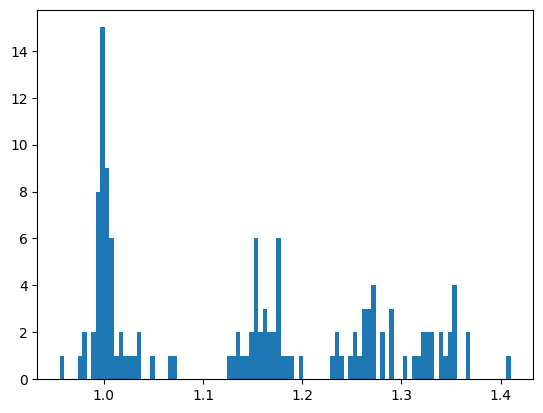

In [15]:
plt.hist(pd.concat(CV_peaks_list)['fundfreqCV'], bins = 100)